# Ciclo Técnico-Executivo - Antecipação de Alertas Críticos

Este notebook consolida a história completa do projeto: **setup dos artefatos -> contexto de negócio -> extração/qualidade -> rotulação -> EDA -> features -> treinamento/seleção -> diagnóstico -> resultado operacional -> decisão executiva**.

A leitura é técnico-executiva. Cada seção conecta a evidência produzida pela pipeline ao impacto esperado na operação de manutenção, mantendo o código apenas como apoio à narrativa.

| Seção | Pergunta respondida |
|---|---|
| 0. Setup e artefatos | Quais bases, relatórios e modelos oficiais serão usados? |
| 1. Contexto e pergunta | Qual decisão operacional o projeto precisa apoiar? |
| 2. Linha do tempo da solução | Como os dados viram uma decisão operacional? |
| 3. Dados e qualidade | A base é íntegra e suficiente para modelagem? |
| 4. Rotulação | O que significa antecipar um alerta crítico em 4 horas? |
| 5. EDA orientada à decisão | Há sinal temporal e operacional para priorizar risco? |
| 6. Feature engineering | Quais sinais o modelo usa sem vazamento de futuro? |
| 7. Treinamento e seleção | Qual candidato maximiza desempenho operacional? |
| 8. Diagnóstico técnico | Como o score se comporta ciclo-a-ciclo e onde erra? |
| 9. Resultado operacional e segmentos | Top15 Tag-dia entrega ganho real e onde exige atenção? |
| 10. Decisão executiva | O projeto está pronto para piloto assistido? |

**Fonte de verdade:** artefatos versionados em `data/processed/`, `reports/`, `docs/` e `models/model_selected.joblib`.


## Setup e Carregamento dos Artefatos

Esta célula concentra imports, caminhos, tema visual, helpers e carregamento dos artefatos oficiais. As demais seções partem desses objetos para evitar repetição de leitura e lógica de preparação.


In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.patches import Patch
from sklearn.metrics import auc, precision_recall_curve, roc_curve

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "reports").exists() and (ROOT.parent / "reports").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.evaluation.operational_scorecard import decode_one_hot_prefix  # noqa: E402
from src.utils.plot_theme import PALETTE, add_source_note, apply_manager_theme  # noqa: E402

apply_manager_theme()
PALETTE.update(
    {
        "teal_dark": "#0F6E56",
        "teal_light": "#9FE1CB",
        "blue_dark": "#0C447C",
        "blue_light": "#B5D4F4",
        "amber": "#BA7517",
        "amber_dark": "#633806",
        "amber_light": "#FAC775",
        "gray": "#5F5E5A",
        "gray_light": "#D3D1C7",
        "bg": "#F1EFE8",
    }
)

BAR_COLORS = [PALETTE["teal"], PALETTE["blue"], PALETTE["amber"]]
TABLE_STYLE_RULES = [
    {
        "selector": "caption",
        "props": "font-size:13px;font-weight:bold;text-align:left;padding-bottom:6px;",
    },
    {
        "selector": "th",
        "props": "background:#f0f4f8;font-weight:600;padding:8px 12px;",
    },
    {"selector": "td", "props": "padding:7px 12px;"},
]
table_style_rules = TABLE_STYLE_RULES

plt.rcParams.update(
    {
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "axes.labelcolor": PALETTE["gray"],
        "xtick.color": PALETTE["gray"],
        "ytick.color": PALETTE["gray"],
        "figure.dpi": 120,
    }
)


def table_style(accent="teal"):
    """Estilo padrão para tabelas executivas no notebook."""
    return [
        {
            "selector": "caption",
            "props": [
                ("font-size", "12px"),
                ("color", PALETTE["gray"]),
                ("text-align", "left"),
                ("padding-bottom", "6px"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("background-color", PALETTE["bg"]),
                ("color", PALETTE["navy"]),
                ("font-size", "11px"),
                ("border-bottom", f"2px solid {PALETTE[accent]}"),
                ("padding", "6px 10px"),
            ],
        },
        {"selector": "td", "props": [("padding", "5px 10px"), ("font-size", "11px")]},
        {"selector": "tr:hover td", "props": [("background-color", PALETTE["bg"])]},
    ]


REPORTS = ROOT / "reports"
REPORTS_BASELINE = REPORTS / "baseline"
REPORTS_MODEL_SELECTION = REPORTS / "model_selection"
REPORTS_MODELING_LEGACY = REPORTS / "modeling_legacy"
REPORTS_OPERATIONAL = REPORTS / "operational"
REPORTS_SEGMENTS = REPORTS / "segments"
DATA = ROOT / "data" / "processed"
RAW = ROOT / "data" / "raw" / "datasets" / "datasets"
DOCS = ROOT / "docs"
MODELS = ROOT / "models"


def read_json(path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def first_existing(*paths):
    for candidate in paths:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Nenhum artefato encontrado entre: {[str(p) for p in paths]}")


def pct(value, digits=1):
    return f"{value:.{digits}%}"


def fmt_int(value):
    return f"{int(value):,}".replace(",", ".")


def short_path(path):
    path = Path(path)
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)


# Dados processados e splits oficiais.
features_df = pd.read_parquet(DATA / "features" / "features_dataset.parquet")
split_train_df = pd.read_parquet(DATA / "features" / "splits" / "features_train.parquet")
split_val_df = pd.read_parquet(DATA / "features" / "splits" / "features_val.parquet")
split_test_df = pd.read_parquet(DATA / "features" / "splits" / "features_test.parquet")

for df in [features_df, split_train_df, split_val_df, split_test_df]:
    for col in ["Inicio", "Fim"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

# Relatórios oficiais.
quality_json = read_json(DATA / "labeled" / "quality_report_ingestao.json")
labeling_json = read_json(DATA / "labeled" / "labeling_report.json")
feature_json = read_json(DATA / "features" / "feature_report.json")
split_json = read_json(DATA / "features" / "splits" / "split_metadata.json")
oper_json = read_json(REPORTS_OPERATIONAL / "operational_metrics_report.json")
segment_json = read_json(REPORTS_SEGMENTS / "segment_operational_report.json")
selection_report_path = first_existing(
    REPORTS_MODEL_SELECTION / "model_selection_report.json",
    REPORTS_MODELING_LEGACY / "model_benchmark_report.json",
)
selection_json = read_json(selection_report_path)

selection_df = pd.read_csv(
    first_existing(
        REPORTS_MODEL_SELECTION / "model_selection_report.csv",
        REPORTS_MODELING_LEGACY / "model_benchmark_report.csv",
    )
)
oper_budget_df = pd.read_csv(REPORTS_OPERATIONAL / "operational_budget_metrics.csv")
oper_topk_df = pd.read_csv(REPORTS_OPERATIONAL / "operational_daily_topk_metrics.csv")
segment_threshold_df = pd.read_csv(REPORTS_SEGMENTS / "segment_threshold_metrics.csv")
segment_topk_df = pd.read_csv(REPORTS_SEGMENTS / "segment_topk_tag_day_metrics.csv")
segment_hotspots_df = pd.read_csv(REPORTS_SEGMENTS / "segment_tag_hotspots.csv")
threshold_curve_df = pd.read_csv(
    first_existing(
        REPORTS_MODEL_SELECTION / "model_selected_threshold_curve.csv",
        REPORTS_MODELING_LEGACY / "hist_gbdt_threshold_curve.csv",
    )
)
feature_importance_df = pd.read_csv(
    first_existing(
        REPORTS_MODEL_SELECTION / "model_selected_feature_importance.csv",
        REPORTS_MODELING_LEGACY / "model_feature_importance.csv",
    )
)
backtest_df = pd.read_csv(
    first_existing(
        REPORTS_MODEL_SELECTION / "model_selection_backtest_report.csv",
        REPORTS_MODELING_LEGACY / "hist_gbdt_backtest_report.csv",
    )
)

selected_model = selection_json.get("selected_model") or selection_json.get("winner")
model_name = selected_model["model_name"]
threshold_test = next(item for item in oper_json["threshold_metrics"] if item["split"] == "test")
threshold = float(threshold_test["threshold"])
topk15 = oper_topk_df.query("split == 'test' and top_k_tags_per_day == 15").iloc[0]

# Enriquecimentos para gráficos.
features_df["dia"] = features_df["Fim"].dt.floor("D")
features_df["frota_decoded"] = decode_one_hot_prefix(features_df, "Frota")
features_df["tipo_decoded"] = decode_one_hot_prefix(features_df, "Tipo")
if "turno" in features_df.columns:
    features_df["turno"] = features_df["turno"].astype(str)

assert "target_4h" in features_df.columns, "Coluna target_4h ausente"
assert (
    model_name in selection_df["model_name"].values
), "Modelo selecionado não encontrado no relatório de seleção"
assert (
    abs(
        threshold
        - float(selected_model.get("test_threshold", selected_model.get("threshold", threshold)))
    )
    < 1e-9
), "Threshold dessincronizado entre relatórios"

summary_status = pd.DataFrame(
    {
        "Item": [
            "Registros de features",
            "Período coberto",
            "Modelo selecionado",
            "Threshold oficial",
            "Precision@Top15",
            "Recall@Top15",
            "Lift@Top15",
            "Artefato operacional",
        ],
        "Valor": [
            fmt_int(len(features_df)),
            f"{features_df['Fim'].min().date()} a {features_df['Fim'].max().date()}",
            model_name,
            f"{threshold:.6f}",
            f"{topk15['precision_at_k']:.4f}",
            f"{topk15['recall_at_k']:.4f}",
            f"{topk15['lift_vs_random']:.4f}x",
            oper_json.get("model_path", "models/model_selected.joblib"),
        ],
    }
)

display(
    summary_status.style.set_caption(
        "Resumo executivo sincronizado com os artefatos oficiais"
    ).hide(axis="index")
)
display(
    Markdown(
        f"**Leitura executiva:** notebook carregado com `{fmt_int(len(features_df))}` ciclos, "
        f"modelo `{model_name}` e scorecard operacional Top15 vindo de `reports/`."
    )
)

Item,Valor
Registros de features,377.907
Período coberto,2025-01-01 a 2025-07-01
Modelo selecionado,lightgbm_optuna
Threshold oficial,0.139074
Precision@Top15,0.6756
Recall@Top15,0.7361
Lift@Top15,2.0774x
Artefato operacional,models/model_selected.joblib


**Leitura executiva:** notebook carregado com `377.907` ciclos, modelo `lightgbm_optuna` e scorecard operacional Top15 vindo de `reports/`.

## 1. Contexto de Negócio e Pergunta Analítica

**Operação de mina.** Cada apontamento representa um ciclo de atividade de um equipamento, com `Inicio`, `Fim`, `Tag`, `Frota`, `Tipo` e `Classe`. A decisão operacional não acontece no nível de uma linha isolada: ela busca priorizar equipamentos para inspeção antes que uma condição crítica se materialize.

**Alertas "Don't Go".** Um alerta desse tipo indica que o equipamento não deve operar, por risco operacional, impacto em segurança, disponibilidade de frota e produção. No projeto, o catálogo de regras usado como fonte de verdade é `data/external/regras_negocio/Alarmes - Regra de Negocio.xlsx`, equivalente ao arquivo de alarmes citado no estudo guiado. A aba `CMA` define combinações de `TIPO + EVENTO + SITUACAO + NIVEL` e parâmetros auxiliares (`QTD`, `TEMPO`) que caracterizam criticidade.

**Pergunta analítica escolhida.** Quais equipamentos têm maior risco de gerar um alerta crítico nas próximas 4 horas, considerando o histórico recente de operação e telemetria?

**Métrica de sucesso do negócio.** Resolver o problema significa entregar uma fila diária curta e acionável. Por isso, a métrica principal é `Recall@Top15 Tag-dia`, acompanhada de `Precision@Top15` e `Lift@Top15` contra seleção aleatória. O cenário recomendado é um piloto assistido: o dispatcher/manutenção recebe diariamente as 15 `Tags` de maior risco, valida em campo e registra resultado para monitoramento e retreino.


In [2]:
RULES_PATH = ROOT / "data" / "external" / "regras_negocio" / "Alarmes - Regra de Negocio.xlsx"
DICTIONARY_PATH = ROOT / "data" / "external" / "dicionario" / "Dicionario_Dados.xlsx"

rules_df = pd.read_excel(RULES_PATH, sheet_name="CMA")
rules_df.columns = [str(col).strip() for col in rules_df.columns]
rules_df["NIVEL_norm"] = rules_df["NIVEL"].astype(str).str.strip().str.lower()
muito_alto_rules = rules_df.query("NIVEL_norm == 'muito alto'").copy()

context_table = pd.DataFrame(
    [
        {
            "Item": "Ciclo de apontamento",
            "Evidencia no dado": "Id, Inicio, Fim, Tag, Frota, Tipo, Classe",
            "Papel analitico": "unidade de decisao e criacao do score",
        },
        {
            "Item": "Telemetria",
            "Evidencia no dado": "Data_Evento, TAG, Tipo, Alarme, Criticidade, Is_Dont_Go",
            "Papel analitico": "eventos precursores e confirmacao de alertas",
        },
        {
            "Item": "Catalogo de regras",
            "Evidencia no dado": short_path(RULES_PATH),
            "Papel analitico": "define condicoes criticas de negocio",
        },
        {
            "Item": "Alvo supervisionado",
            "Evidencia no dado": "target_4h",
            "Papel analitico": "1 quando ha alerta critico ate 4h apos o ciclo",
        },
        {
            "Item": "Acao recomendada",
            "Evidencia no dado": "Top15 Tag-dia",
            "Papel analitico": "fila curta de inspecao preventiva",
        },
    ]
)

display(context_table.style.hide(axis="index").set_caption("Traducao do negocio para analise"))

rules_summary = pd.DataFrame(
    [
        {"Indicador": "Total de regras CMA", "Valor": fmt_int(len(rules_df))},
        {"Indicador": "Regras NIVEL Muito Alto", "Valor": fmt_int(len(muito_alto_rules))},
        {
            "Indicador": "Tipos de regra",
            "Valor": ", ".join(sorted(rules_df["TIPO"].dropna().astype(str).unique())[:6]),
        },
        {
            "Indicador": "Eventos unicos Muito Alto",
            "Valor": fmt_int(muito_alto_rules["EVENTO"].nunique()),
        },
    ]
)
display(rules_summary.style.hide(axis="index").set_caption("Cobertura do catalogo de alarmes"))

examples = (
    muito_alto_rules[["TIPO", "EVENTO", "SITUACAO", "QTD", "TEMPO", "NIVEL"]]
    .drop_duplicates()
    .head(10)
)
display(
    examples.style.hide(axis="index").set_caption(
        "Exemplos de regras de criticidade maxima (NIVEL = Muito Alto)"
    )
)

business_success = pd.DataFrame(
    [
        {
            "Dimensao": "Pergunta",
            "Definicao": "Priorizar Tags com maior risco de alerta critico nas proximas 4 horas",
        },
        {
            "Dimensao": "Sucesso tecnico",
            "Definicao": "Recall@Top15 alto sem derrubar Precision@Top15 abaixo da meta",
        },
        {
            "Dimensao": "Sucesso operacional",
            "Definicao": "Lista diaria auditavel que caiba na capacidade de inspecao da manutencao",
        },
        {
            "Dimensao": "Uso em campo",
            "Definicao": "Piloto assistido por 30 dias, decisao humana e registro de feedback",
        },
    ]
)
display(
    business_success.style.hide(axis="index").set_caption("Problema analitico e metrica de sucesso")
)

Item,Evidencia no dado,Papel analitico
Ciclo de apontamento,"Id, Inicio, Fim, Tag, Frota, Tipo, Classe",unidade de decisao e criacao do score
Telemetria,"Data_Evento, TAG, Tipo, Alarme, Criticidade, Is_Dont_Go",eventos precursores e confirmacao de alertas
Catalogo de regras,data/external/regras_negocio/Alarmes - Regra de Negocio.xlsx,define condicoes criticas de negocio
Alvo supervisionado,target_4h,1 quando ha alerta critico ate 4h apos o ciclo
Acao recomendada,Top15 Tag-dia,fila curta de inspecao preventiva


Indicador,Valor
Total de regras CMA,151
Regras NIVEL Muito Alto,82
Tipos de regra,"ALARME OEM, SISTEMA, TENDÊNCIA"
Eventos unicos Muito Alto,77


TIPO,EVENTO,SITUACAO,QTD,TEMPO,NIVEL
ALARME OEM,Low Transmission Oil Level,Mediante alarme nível 3,2,360,Muito Alto
ALARME OEM,Low Transmission Oil Level,Mediante cinco alarmes nivel 2 consecutivos.,5,360,Muito alto
ALARME OEM,Transmission Oil Level - Active,Mediante alarme nível 3,2,360,Muito Alto
ALARME OEM,Engine Coolant Level - Active,Mediante alarme nível 3,1,0,Muito Alto
ALARME OEM,Low Engine Coolant Level,Mediante alarme nível 3,1,0,Muito Alto
ALARME OEM,Engine Coolant Level Low,Mediante alarme nível 3,1,0,Muito Alto
ALARME OEM,Coolant Level - Data Erratic - Ce (Active),Em qualquer situação,1,0,Muito alto
ALARME OEM,Coolant Level - Valid But Low - Most Severe - P (Active),Em qualquer situação,1,0,Muito alto
ALARME OEM,Coolant Level - Valid But Low - Most Severe - Ce (Active),Em qualquer situação,1,0,Muito Alto
ALARME OEM,Very Low Hydraulic Oil Level,Em qualquer situação,1,0,Muito Alto


Dimensao,Definicao
Pergunta,Priorizar Tags com maior risco de alerta critico nas proximas 4 horas
Sucesso tecnico,Recall@Top15 alto sem derrubar Precision@Top15 abaixo da meta
Sucesso operacional,Lista diaria auditavel que caiba na capacidade de inspecao da manutencao
Uso em campo,"Piloto assistido por 30 dias, decisao humana e registro de feedback"


## 2. Linha do Tempo da Solução

A solução foi desenhada para transformar registros históricos em uma lista diária de prioridade por `Tag`. A linha abaixo mostra o encadeamento entre dados, modelagem e decisão operacional.


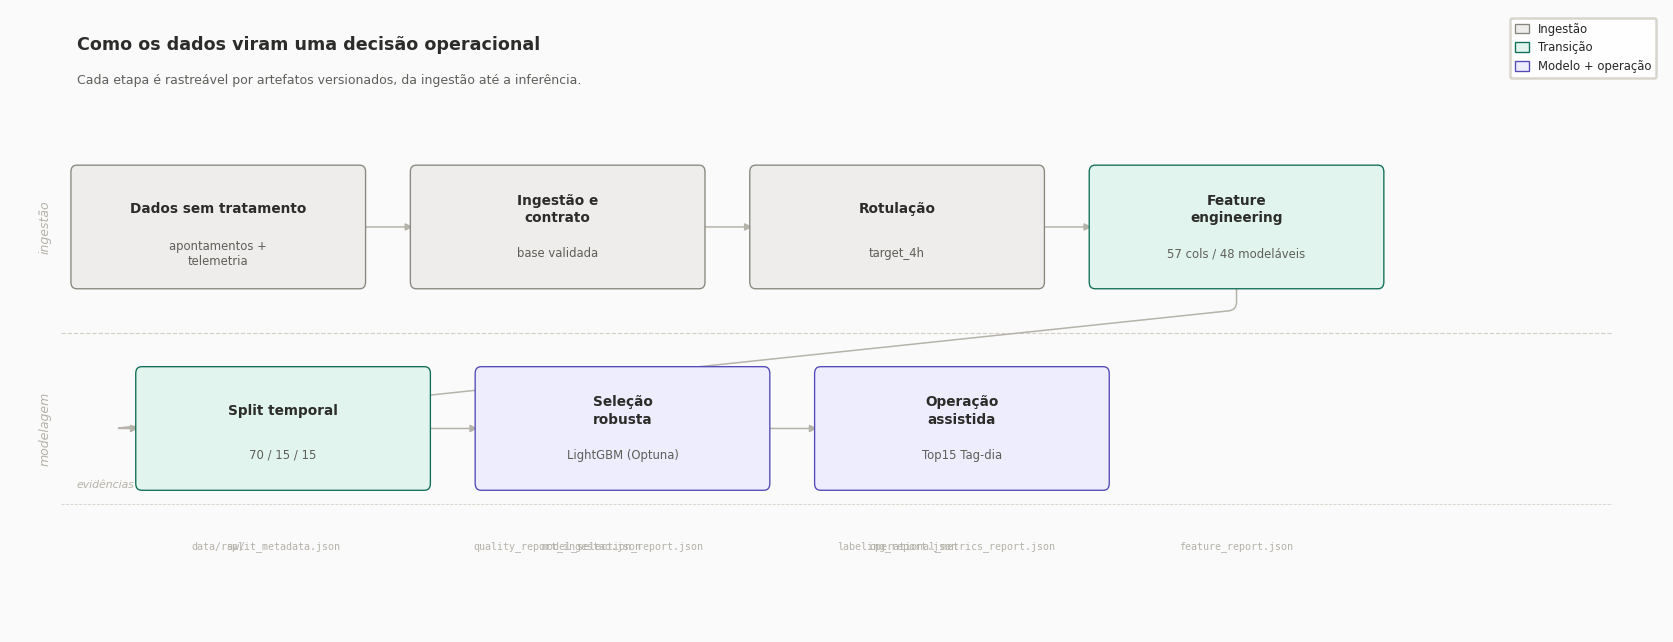

In [3]:
model_display_name = {
    "lightgbm_optuna": "LightGBM (Optuna)",
    "xgboost_optuna": "XGBoost (Optuna)",
    "hist_gbdt_optuna": "HistGradientBoosting (Optuna)",
}.get(model_name, model_name)

pipeline_steps = pd.DataFrame(
    [
        {
            "Etapa": "Dados sem tratamento",
            "Saída": "apontamentos +\ntelemetria",
            "Evidência": "data/raw/",
            "linha": 0,
            "col": 0,
        },
        {
            "Etapa": "Ingestão e\ncontrato",
            "Saída": "base validada",
            "Evidência": "quality_report_ingestao.json",
            "linha": 0,
            "col": 1,
        },
        {
            "Etapa": "Rotulação",
            "Saída": "target_4h",
            "Evidência": "labeling_report.json",
            "linha": 0,
            "col": 2,
        },
        {
            "Etapa": "Feature\nengineering",
            "Saída": "57 cols / 48 modeláveis",
            "Evidência": "feature_report.json",
            "linha": 0,
            "col": 3,
        },
        {
            "Etapa": "Split temporal",
            "Saída": "70 / 15 / 15",
            "Evidência": "split_metadata.json",
            "linha": 1,
            "col": 0,
        },
        {
            "Etapa": "Seleção\nrobusta",
            "Saída": model_display_name,
            "Evidência": "model_selection_report.json",
            "linha": 1,
            "col": 1,
        },
        {
            "Etapa": "Operação\nassistida",
            "Saída": "Top15 Tag-dia",
            "Evidência": "operational_metrics_report.json",
            "linha": 1,
            "col": 2,
        },
    ]
)

# ── Paleta ─────────────────────────────────────────────────────────────────────
BG = "#FAFAFA"
GRAY_F = "#EEEDEB"
GRAY_E = "#888780"
TEAL_F = "#E1F5EE"
TEAL_E = "#0F6E56"
PURP_F = "#EEEDFE"
PURP_E = "#534AB7"
TXT_PRI = "#2C2C2A"
TXT_SEC = "#5F5E5A"
TXT_HINT = "#B4B2A9"
ARROW_C = "#B4B2A9"
DIV_C = "#D3D1C7"

# fase: (facecolor, edgecolor)
COL_MAP = {
    (0, 0): (GRAY_F, GRAY_E),
    (0, 1): (GRAY_F, GRAY_E),
    (0, 2): (GRAY_F, GRAY_E),
    (0, 3): (TEAL_F, TEAL_E),
    (1, 0): (TEAL_F, TEAL_E),
    (1, 1): (PURP_F, PURP_E),
    (1, 2): (PURP_F, PURP_E),
}

# ── Geometria ──────────────────────────────────────────────────────────────────
FIG_W, FIG_H = 14, 5.4
BOX_W, BOX_H = 2.4, 0.82
GAP_X = 0.48
ROW_Y = [3.6, 2.1]
ROW_X_START = [0.55, 1.1]


def cx(r, c):
    return ROW_X_START[r] + c * (BOX_W + GAP_X) + BOX_W / 2


def cy(r):
    return ROW_Y[r]


fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_xlim(0, FIG_W)
ax.set_ylim(0.6, FIG_H - 0.2)
ax.axis("off")

arrow_kw = dict(arrowstyle="-|>", color=ARROW_C, lw=0.9, mutation_scale=9)

# ── Linha divisória entre fases ────────────────────────────────────────────────
MID_Y = (ROW_Y[0] - BOX_H / 2 + ROW_Y[1] + BOX_H / 2) / 2 - 0.04
ax.axhline(MID_Y, xmin=0.03, xmax=0.97, color=DIV_C, lw=0.7, linestyle="--", zorder=1)

# ── Rótulos de fase ────────────────────────────────────────────────────────────
ax.text(
    0.28,
    ROW_Y[0],
    "ingestão",
    ha="center",
    va="center",
    fontsize=7.5,
    color=TXT_HINT,
    rotation=90,
    style="italic",
)
ax.text(
    0.28,
    ROW_Y[1],
    "modelagem",
    ha="center",
    va="center",
    fontsize=7.5,
    color=TXT_HINT,
    rotation=90,
    style="italic",
)

# ── Setas linha 0 ──────────────────────────────────────────────────────────────
for c in range(3):
    x0 = cx(0, c) + BOX_W / 2
    x1 = cx(0, c + 1) - BOX_W / 2
    y = cy(0)
    ax.annotate("", xy=(x1, y), xytext=(x0, y), arrowprops=arrow_kw)

# ── Seta de descida (col3 row0 → col0 row1): L-shaped ─────────────────────────
xs, ys = cx(0, 3), cy(0) - BOX_H / 2  # bottom do último box row0
xe, ye = cx(1, 0) - BOX_W / 2, cy(1)  # left do primeiro box row1
mid_y = (ys + ye) / 2

verts = [(xs, ys), (xs, mid_y), (xe, mid_y), (xe, ye)]
codes = [1, 2, 2, 2]  # MOVETO, LINETO...

pth = mpatches.FancyArrow(0, 0, 0, 0)  # dummy
ax.annotate(
    "",
    xy=(xe, ye),
    xytext=(xs, ys),
    arrowprops=dict(
        arrowstyle="-|>",
        color=ARROW_C,
        lw=0.9,
        mutation_scale=9,
        connectionstyle="arc,angleA=-90,angleB=180,armA=28,armB=28,rad=8",
    ),
)

# ── Setas linha 1 ──────────────────────────────────────────────────────────────
for c in range(2):
    x0 = cx(1, c) + BOX_W / 2
    x1 = cx(1, c + 1) - BOX_W / 2
    y = cy(1)
    ax.annotate("", xy=(x1, y), xytext=(x0, y), arrowprops=arrow_kw)

# ── Caixas + texto ─────────────────────────────────────────────────────────────
for _, row in pipeline_steps.iterrows():
    r, c = int(row["linha"]), int(row["col"])
    x = cx(r, c) - BOX_W / 2
    y = cy(r) - BOX_H / 2
    fc, ec = COL_MAP[(r, c)]

    ax.add_patch(
        mpatches.FancyBboxPatch(
            (x, y),
            BOX_W,
            BOX_H,
            boxstyle="round,pad=0.05",
            linewidth=0.8,
            edgecolor=ec,
            facecolor=fc,
            zorder=3,
        )
    )
    ax.text(
        cx(r, c),
        cy(r) + 0.13,
        row["Etapa"],
        ha="center",
        va="center",
        fontsize=8.2,
        fontweight="bold",
        color=TXT_PRI,
        zorder=4,
        linespacing=1.3,
    )
    ax.text(
        cx(r, c),
        cy(r) - 0.2,
        row["Saída"],
        ha="center",
        va="center",
        fontsize=7,
        color=TXT_SEC,
        zorder=4,
        linespacing=1.25,
    )

# ── Faixa de evidências ────────────────────────────────────────────────────────
EV_Y = 1.22
ax.axhline(EV_Y + 0.32, xmin=0.03, xmax=0.97, color=DIV_C, lw=0.5, linestyle="--")
ax.text(0.55, EV_Y + 0.46, "evidências", fontsize=6.5, color=TXT_HINT, va="center", style="italic")

for _, row in pipeline_steps.iterrows():
    r, c = int(row["linha"]), int(row["col"])
    ax.text(
        cx(r, c),
        EV_Y,
        row["Evidência"],
        ha="center",
        va="center",
        fontsize=6,
        color=TXT_HINT,
        fontfamily="monospace",
    )

# ── Legenda ────────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(facecolor=GRAY_F, edgecolor=GRAY_E, linewidth=0.8, label="Ingestão"),
    mpatches.Patch(facecolor=TEAL_F, edgecolor=TEAL_E, linewidth=0.8, label="Transição"),
    mpatches.Patch(facecolor=PURP_F, edgecolor=PURP_E, linewidth=0.8, label="Modelo + operação"),
]
ax.legend(
    handles=legend_items,
    loc="upper right",
    fontsize=7,
    frameon=True,
    framealpha=0.9,
    edgecolor=DIV_C,
    handlelength=1.2,
    handleheight=0.9,
)

# ── Título ─────────────────────────────────────────────────────────────────────
ax.text(
    0.55,
    FIG_H - 0.38,
    "Como os dados viram uma decisão operacional",
    fontsize=10.5,
    fontweight="bold",
    color=TXT_PRI,
    va="top",
)
ax.text(
    0.55,
    FIG_H - 0.66,
    "Cada etapa é rastreável por artefatos versionados, da ingestão até a inferência.",
    fontsize=7.5,
    color=TXT_SEC,
    va="top",
)

plt.tight_layout(pad=0.5)
plt.show()

## 3. Dados, Ingestão e Contrato

Antes da modelagem, o projeto valida se os dados têm volume, datas e campos mínimos para sustentar uma análise temporal. Esta seção resume os contratos oficiais de ingestão, rotulação, features e split.


Indicador,Valor,Fonte
Registros de apontamentos,377.907,quality_report_ingestao.json
Duplicatas completas,0,quality_report_ingestao.json
Duplicatas Tag-Inicio-Fim,101 (0.0267%),quality_report_ingestao.json
Datas inválidas,0,quality_report_ingestao.json
Arquivos de telemetria processados,6,labeling_report.json
Linhas de eventos de telemetria,37.164.054,labeling_report.json
Linhas de features,377.907,feature_report.json
Features modeláveis,48,model_selection_report.json


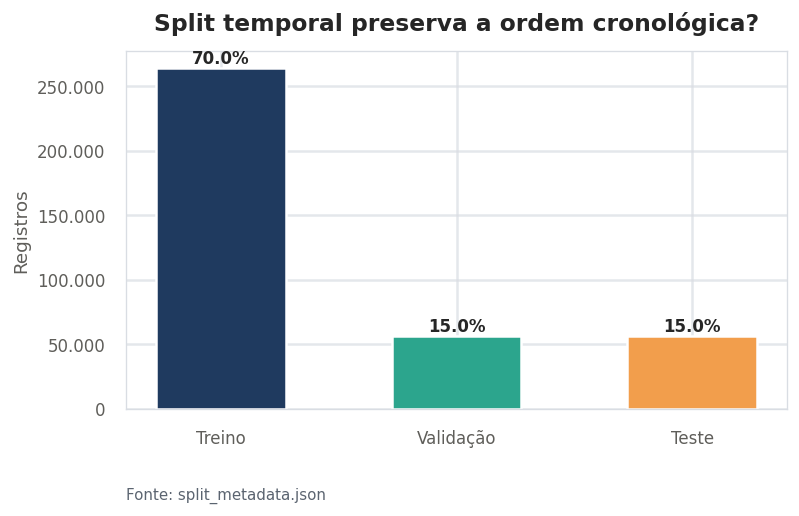

Split,Registros,Início,Fim,% do total
Treino,264.534,2025-01-01 03:03:43+00:00,2025-05-06 06:00:00+00:00,70.0%
Validação,56.686,2025-05-06 06:00:00+00:00,2025-06-02 15:00:00+00:00,15.0%
Teste,56.687,2025-06-02 15:00:00+00:00,2025-07-01 03:00:00+00:00,15.0%


**Insight operacional:** a base é íntegra para o fluxo atual: não há duplicatas completas, datas inválidas ou duração negativa, e o split temporal isola o teste para reporte final.

In [4]:
telemetry_files = sorted((RAW / "telemetria").glob("*.parquet"))
apontamentos_file = RAW / "apontamentos" / "desenvolver_apontamentos.parquet"

contract_cards = pd.DataFrame(
    [
        {
            "Indicador": "Registros de apontamentos",
            "Valor": fmt_int(quality_json["total_records"]),
            "Fonte": "quality_report_ingestao.json",
        },
        {
            "Indicador": "Duplicatas completas",
            "Valor": fmt_int(quality_json["duplicate_full_rows"]),
            "Fonte": "quality_report_ingestao.json",
        },
        {
            "Indicador": "Duplicatas Tag-Inicio-Fim",
            "Valor": (
                f"{fmt_int(quality_json['duplicate_tag_inicio_fim'])} "
                f"({quality_json['duplicate_tag_inicio_fim_pct']:.4f}%)"
            ),
            "Fonte": "quality_report_ingestao.json",
        },
        {
            "Indicador": "Datas inválidas",
            "Valor": fmt_int(quality_json["invalid_inicio"] + quality_json["invalid_fim"]),
            "Fonte": "quality_report_ingestao.json",
        },
        {
            "Indicador": "Arquivos de telemetria processados",
            "Valor": fmt_int(labeling_json["files_processed"]),
            "Fonte": "labeling_report.json",
        },
        {
            "Indicador": "Linhas de eventos de telemetria",
            "Valor": fmt_int(labeling_json["rows_total_events"]),
            "Fonte": "labeling_report.json",
        },
        {
            "Indicador": "Linhas de features",
            "Valor": fmt_int(feature_json["rows"]),
            "Fonte": "feature_report.json",
        },
        {
            "Indicador": "Features modeláveis",
            "Valor": fmt_int(selection_json["feature_count"]),
            "Fonte": "model_selection_report.json",
        },
    ]
)
display(contract_cards.style.hide(axis="index").set_caption("Contrato e cobertura dos dados"))

split_table = pd.DataFrame(
    [
        {
            "Split": "Treino",
            "Registros": split_json["rows_train"],
            "Início": split_json["train_start"],
            "Fim": split_json["train_end"],
        },
        {
            "Split": "Validação",
            "Registros": split_json["rows_val"],
            "Início": split_json["val_start"],
            "Fim": split_json["val_end"],
        },
        {
            "Split": "Teste",
            "Registros": split_json["rows_test"],
            "Início": split_json["test_start"],
            "Fim": split_json["test_end"],
        },
    ]
)
split_table["% do total"] = split_table["Registros"] / split_json["rows_total"]

fig, ax = plt.subplots(figsize=(7, 4.8))
colors = [PALETTE["navy"], PALETTE["teal"], PALETTE["orange"]]
bars = ax.bar(split_table["Split"], split_table["Registros"], color=colors, width=0.55)
for bar, share in zip(bars, split_table["% do total"], strict=False):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{share:.1%}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
ax.set_title("Split temporal preserva a ordem cronológica?")
ax.set_ylabel("Registros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt_int(x)))
add_source_note(ax, "Fonte: split_metadata.json")
plt.tight_layout()
plt.show()

display(
    split_table.assign(
        Registros=split_table["Registros"].map(fmt_int),
        **{"% do total": split_table["% do total"].map(lambda v: f"{v:.1%}")},
    ).style.hide(axis="index")
)
display(
    Markdown(
        "**Insight operacional:** a base é íntegra para o fluxo atual: "
        "não há duplicatas completas, "
        "datas inválidas ou duração negativa, e o split temporal isola o teste para reporte final."
    )
)

### 3.1 Inspeção Inicial dos Dados

Esta célula explicita os itens mínimos de carregamento: inventário dos datasets, `shape`, `dtypes`, valores nulos, duplicatas, janela temporal, frequência de registros e estatísticas descritivas. Para telemetria, a contagem é feita arquivo a arquivo para evitar carregar todos os 37 milhões de eventos simultaneamente.


In [5]:
raw_apontamentos = pd.read_parquet(apontamentos_file)
raw_apontamentos["Inicio"] = pd.to_datetime(raw_apontamentos["Inicio"], errors="coerce", utc=True)
raw_apontamentos["Fim"] = pd.to_datetime(raw_apontamentos["Fim"], errors="coerce", utc=True)
raw_apontamentos["duracao_ciclo_min"] = (
    raw_apontamentos["Fim"] - raw_apontamentos["Inicio"]
).dt.total_seconds() / 60

telemetry_inventory = []
for path in telemetry_files:
    rows = len(pd.read_parquet(path, columns=[]))
    telemetry_inventory.append(
        {
            "Dataset": path.name,
            "Linhas": rows,
            "Colunas": "ver dicionario",
            "Fonte": short_path(path),
        }
    )

inventory = pd.DataFrame(
    [
        {
            "Dataset": "desenvolver_apontamentos.parquet",
            "Linhas": len(raw_apontamentos),
            "Colunas": raw_apontamentos.shape[1] - 1,
            "Fonte": short_path(apontamentos_file),
        },
        *telemetry_inventory,
    ]
)
inventory["Linhas"] = inventory["Linhas"].map(fmt_int)
display(inventory.style.hide(axis="index").set_caption("Inventario de datasets carregados"))

schema_quality = pd.DataFrame(
    {
        "coluna": raw_apontamentos.columns,
        "dtype": raw_apontamentos.dtypes.astype(str).values,
        "nulos": raw_apontamentos.isna().sum().values,
        "% nulos": raw_apontamentos.isna().mean().values,
        "valores_unicos": raw_apontamentos.nunique(dropna=True).values,
    }
)
display(
    schema_quality.style.hide(axis="index")
    .format({"% nulos": "{:.2%}"})
    .set_caption("Schema, nulos e cardinalidade - apontamentos")
)

numeric_desc = (
    raw_apontamentos.select_dtypes(include="number")
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T.rename(
        columns={
            "count": "contagem",
            "mean": "media",
            "std": "desvio_padrao",
            "min": "min",
            "50%": "mediana",
            "max": "max",
        }
    )[["contagem", "min", "max", "media", "mediana", "desvio_padrao"]]
)
display(
    numeric_desc.style.format("{:.2f}").set_caption(
        "Estatisticas descritivas das variaveis numericas"
    )
)

temporal_profile = pd.DataFrame(
    [
        {"Indicador": "Inicio minimo", "Valor": str(raw_apontamentos["Inicio"].min())},
        {"Indicador": "Fim maximo", "Valor": str(raw_apontamentos["Fim"].max())},
        {
            "Indicador": "Media de registros por dia",
            "Valor": (
                f"{raw_apontamentos.groupby(raw_apontamentos['Inicio'].dt.date).size().mean():.1f}"
            ),
        },
        {
            "Indicador": "Media de registros por hora",
            "Valor": (
                f"{raw_apontamentos.groupby(raw_apontamentos['Inicio'].dt.floor('h')).size().mean():.1f}"
            ),
        },
        {
            "Indicador": "Media de ciclos por equipamento",
            "Valor": f"{raw_apontamentos.groupby('Tag').size().mean():.1f}",
        },
        {
            "Indicador": "Duplicatas completas",
            "Valor": fmt_int(raw_apontamentos.duplicated().sum()),
        },
        {
            "Indicador": "Duplicatas Tag-Inicio-Fim",
            "Valor": fmt_int(raw_apontamentos.duplicated(["Tag", "Inicio", "Fim"]).sum()),
        },
    ]
)
display(
    temporal_profile.style.hide(axis="index").set_caption("Distribuicao temporal e duplicidade")
)

Dataset,Linhas,Colunas,Fonte
desenvolver_apontamentos.parquet,377.907,7,data/raw/datasets/datasets/apontamentos/desenvolver_apontamentos.parquet
telemetry_abr.parquet,6.475.045,ver dicionario,data/raw/datasets/datasets/telemetria/telemetry_abr.parquet
telemetry_feb.parquet,5.709.935,ver dicionario,data/raw/datasets/datasets/telemetria/telemetry_feb.parquet
telemetry_jan.parquet,5.400.002,ver dicionario,data/raw/datasets/datasets/telemetria/telemetry_jan.parquet
telemetry_jun.parquet,7.854.243,ver dicionario,data/raw/datasets/datasets/telemetria/telemetry_jun.parquet
telemetry_mar.parquet,5.688.538,ver dicionario,data/raw/datasets/datasets/telemetria/telemetry_mar.parquet
telemetry_may.parquet,6.036.291,ver dicionario,data/raw/datasets/datasets/telemetria/telemetry_may.parquet


coluna,dtype,nulos,% nulos,valores_unicos
Id,int64,0,0.00%,377907
Inicio,"datetime64[ns, UTC]",0,0.00%,190200
Fim,"datetime64[ns, UTC]",0,0.00%,190199
Tag,object,0,0.00%,47
Frota,object,0,0.00%,5
Tipo,object,0,0.00%,2
Classe,object,0,0.00%,4
duracao_ciclo_min,float64,0,0.00%,3600


,contagem,min,max,media,mediana,desvio_padrao
Id,377907.00,23130822.00,197125485.00,89345481.29,113865910.00,42357751.23
duracao_ciclo_min,377907.00,0.02,60.00,29.69,22.90,24.04


Indicador,Valor
Inicio minimo,2025-01-01 00:00:00+00:00
Fim maximo,2025-07-01 00:00:00+00:00
Media de registros por dia,2087.9
Media de registros por hora,87.0
Media de ciclos por equipamento,8040.6
Duplicatas completas,0
Duplicatas Tag-Inicio-Fim,101


### 3.2 Limpeza, Tratamentos e Controle de Alterações

O estudo guiado pede que exclusões, alterações e decisões metodológicas relevantes tenham registro de antes/depois. A tabela abaixo resume a decisão tomada para nulos, inconsistências temporais, duplicatas e outliers. O detalhe operacional fica versionado em `data/processed/labeled/quality_report_ingestao.*` e `docs/controle_alteracoes.md`.


In [6]:
q1 = raw_apontamentos["duracao_ciclo_min"].quantile(0.25)
q3 = raw_apontamentos["duracao_ciclo_min"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_mask = ~raw_apontamentos["duracao_ciclo_min"].between(lower, upper)


def treatment_row(campo, problema, qtd, tratamento, justificativa, antes=None, depois=None):
    return {
        "Campo": campo,
        "Problema identificado": problema,
        "Qtd. registros": int(qtd),
        "Antes": antes if antes is not None else "base sem tratamento",
        "Depois": depois if depois is not None else "base processada",
        "Tratamento aplicado": tratamento,
        "Justificativa": justificativa,
    }


cleaning_audit = pd.DataFrame(
    [
        treatment_row(
            "todas",
            "linhas totalmente duplicadas",
            quality_json["duplicate_full_rows"],
            "manter/remover conforme contrato; valor atual zero",
            "evitar contagem dupla de ciclos",
        ),
        treatment_row(
            "Tag+Inicio+Fim",
            "duplicatas de chave operacional",
            quality_json["duplicate_tag_inicio_fim"],
            "registrar e preservar trilha de auditoria",
            "baixo volume; decisao rastreada no relatorio de qualidade",
        ),
        treatment_row(
            "Inicio/Fim",
            "datas invalidas",
            quality_json["invalid_inicio"] + quality_json["invalid_fim"],
            "coagir datas e reportar invalidas",
            "datas sao eixo de validacao temporal",
        ),
        treatment_row(
            "Inicio/Fim",
            "Inicio > Fim ou duracao negativa",
            quality_json["duration_negative_count"],
            "bloquear promocao se houver",
            "ciclos negativos contaminam features temporais",
        ),
        treatment_row(
            "duracao_ciclo_min",
            f"outliers por IQR fora de [{lower:.1f}, {upper:.1f}] min",
            outlier_mask.sum(),
            "manter com variaveis robustas/rolling; nao truncar",
            "outlier de duracao pode ser sinal operacional real",
        ),
        treatment_row(
            "nulos",
            "valores ausentes em features rolling/recencia",
            features_df.isna().sum().sum(),
            "modelos de arvore aceitam NaN; encodings recebem valor neutro quando aplicavel",
            "evitar imputacao que invente historico inexistente",
        ),
    ]
)

display(
    cleaning_audit.style.hide(axis="index")
    .format({"Qtd. registros": lambda v: fmt_int(v)})
    .set_caption("Controle de alteracoes - antes/depois e justificativa")
)

missing_strategy = pd.DataFrame(
    [
        {
            "Tipo de campo": "datas e chaves",
            "Estrategia": "validar contrato e bloquear se invalido",
            "Motivo": "sustentam ordenacao temporal e joins",
        },
        {
            "Tipo de campo": "categoricas",
            "Estrategia": "frequency/target encoding ou one-hot conforme cardinalidade",
            "Motivo": "preservar informacao sem alta dimensionalidade desnecessaria",
        },
        {
            "Tipo de campo": "rolling windows",
            "Estrategia": "manter NaN quando nao existe historico anterior",
            "Motivo": "NaN indica inicio de historico e evita vazamento",
        },
        {
            "Tipo de campo": "outliers",
            "Estrategia": "monitorar e manter no treino",
            "Motivo": "eventos extremos podem antecipar falhas",
        },
    ]
)
display(
    missing_strategy.style.hide(axis="index").set_caption("Estrategia de missing values e outliers")
)

Campo,Problema identificado,Qtd. registros,Antes,Depois,Tratamento aplicado,Justificativa
todas,linhas totalmente duplicadas,0,base sem tratamento,base processada,manter/remover conforme contrato; valor atual zero,evitar contagem dupla de ciclos
Tag+Inicio+Fim,duplicatas de chave operacional,101,base sem tratamento,base processada,registrar e preservar trilha de auditoria,baixo volume; decisao rastreada no relatorio de qualidade
Inicio/Fim,datas invalidas,0,base sem tratamento,base processada,coagir datas e reportar invalidas,datas sao eixo de validacao temporal
Inicio/Fim,Inicio > Fim ou duracao negativa,0,base sem tratamento,base processada,bloquear promocao se houver,ciclos negativos contaminam features temporais
duracao_ciclo_min,"outliers por IQR fora de [-74.5, 140.7] min",0,base sem tratamento,base processada,manter com variaveis robustas/rolling; nao truncar,outlier de duracao pode ser sinal operacional real
nulos,valores ausentes em features rolling/recencia,185.762,base sem tratamento,base processada,modelos de arvore aceitam NaN; encodings recebem valor neutro quando aplicavel,evitar imputacao que invente historico inexistente


Tipo de campo,Estrategia,Motivo
datas e chaves,validar contrato e bloquear se invalido,sustentam ordenacao temporal e joins
categoricas,frequency/target encoding ou one-hot conforme cardinalidade,preservar informacao sem alta dimensionalidade desnecessaria
rolling windows,manter NaN quando nao existe historico anterior,NaN indica inicio de historico e evita vazamento
outliers,monitorar e manter no treino,eventos extremos podem antecipar falhas


## 4. Rotulação e Variável Alvo

O alvo `target_4h` vale `1` quando um ciclo antecede um evento crítico em até 4 horas. Essa janela é curta o suficiente para acionar inspeção preventiva e longa o bastante para permitir antecipação operacional.

Colunas que enxergam o futuro são usadas apenas para criar o alvo e depois são removidas da modelagem.


Indicador,Valor
Eventos críticos finais,107.002
Tags com sobreposição,34
Ciclos positivos target_4h,70.811 (18.74%)
Janela de antecipação,4 horas
Cobertura de eventos críticos,2025-01-01 03:37:35.267000+00:00 a 2025-07-01 02:59:08.113000+00:00


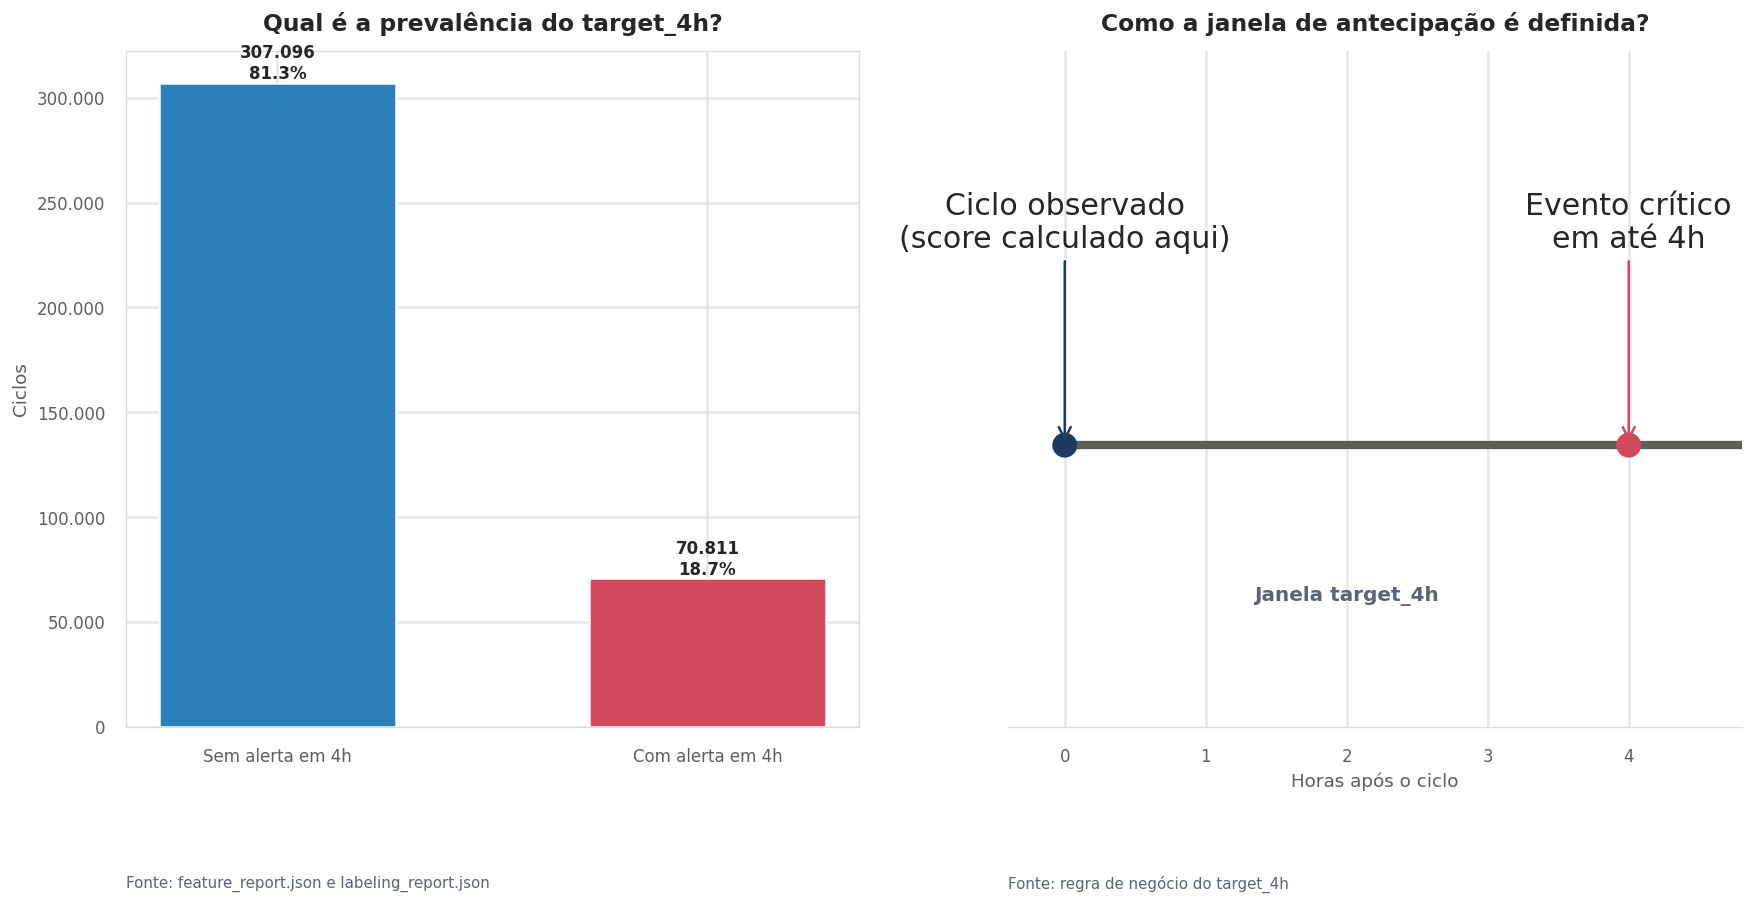

**Insight operacional:** a taxa positiva de `18.74%` indica desbalanceamento moderado; por isso a avaliação principal usa ranking TopK, não apenas acurácia ciclo-a-ciclo.

In [7]:
target_counts = features_df["target_4h"].value_counts().reindex([0, 1], fill_value=0)
target_rate = target_counts.loc[1] / target_counts.sum()

label_cards = pd.DataFrame(
    [
        {
            "Indicador": "Eventos críticos finais",
            "Valor": fmt_int(labeling_json["rows_critical_events_final"]),
        },
        {
            "Indicador": "Tags com sobreposição",
            "Valor": fmt_int(labeling_json["tag_overlap_count"]),
        },
        {
            "Indicador": "Ciclos positivos target_4h",
            "Valor": (
                f"{fmt_int(labeling_json['target_4h_positives'])} "
                f"({labeling_json['target_4h_positive_rate_pct']:.2f}%)"
            ),
        },
        {"Indicador": "Janela de antecipação", "Valor": "4 horas"},
        {
            "Indicador": "Cobertura de eventos críticos",
            "Valor": (
                f"{labeling_json['critical_events_time_min']} "
                f"a {labeling_json['critical_events_time_max']}"
            ),
        },
    ]
)
display(
    label_cards.style.hide(axis="index").set_caption("Resumo da rotulação supervisionada temporal")
)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

ax = axes[0]
bars = ax.bar(
    ["Sem alerta em 4h", "Com alerta em 4h"],
    target_counts.values,
    color=[PALETTE["blue"], PALETTE["red"]],
    width=0.55,
)
for bar, value in zip(bars, target_counts.values, strict=False):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{fmt_int(value)}\n{value/target_counts.sum():.1%}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
ax.set_title("Qual é a prevalência do target_4h?")
ax.set_ylabel("Ciclos")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt_int(x)))
add_source_note(ax, "Fonte: feature_report.json e labeling_report.json")

ax = axes[1]
ax.hlines(0, 0, 5, color=PALETTE["gray"], linewidth=5)
ax.scatter([0, 4], [0, 0], s=[180, 180], color=[PALETTE["navy"], PALETTE["red"]], zorder=3)
ax.annotate(
    "Ciclo observado\n(score calculado aqui)",
    xy=(0, 0),
    xytext=(0, 0.35),
    ha="center",
    arrowprops=dict(arrowstyle="->", color=PALETTE["navy"]),
)
ax.annotate(
    "Evento crítico\nem até 4h",
    xy=(4, 0),
    xytext=(4, 0.35),
    ha="center",
    arrowprops=dict(arrowstyle="->", color=PALETTE["red"]),
)
ax.text(
    2,
    -0.25,
    "Janela target_4h",
    ha="center",
    va="top",
    fontsize=12,
    fontweight="bold",
    color=PALETTE["slate"],
)
ax.set_xlim(-0.4, 4.8)
ax.set_ylim(-0.5, 0.7)
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xlabel("Horas após o ciclo")
ax.set_yticks([])
ax.set_title("Como a janela de antecipação é definida?")
ax.spines[["left", "right", "top"]].set_visible(False)
add_source_note(ax, "Fonte: regra de negócio do target_4h")

plt.tight_layout()
plt.show()

display(
    Markdown(
        f"**Insight operacional:** a taxa positiva de `{target_rate:.2%}` "
        "indica desbalanceamento moderado; por isso a avaliação principal "
        "usa ranking TopK, não apenas acurácia ciclo-a-ciclo."
    )
)

### 4.1 Distribuição da Variável Alvo e dos Alertas

A rotulação final combina a telemetria marcada como `Is_Dont_Go` com a janela de antecipação de 4 horas. A distribuição abaixo cobre três visões: catálogo de regras por criticidade, eventos observados de telemetria por tipo/criticidade e concentração dos eventos críticos por `Tag`.


Indicador,Valor
Eventos Is_Dont_Go observados,19.962
Eventos críticos finais após regra de rotulação,107.002
Tags com evento crítico,33
Período dos alertas,2025-01-01 a 2025-06-30


TIPO,NIVEL,regras
ALARME OEM,Muito Alto,72
ALARME OEM,Alto,64
ALARME OEM,Muito alto,6
TENDÊNCIA,Alto,4
TENDÊNCIA,Muito Alto,3
SISTEMA,Alto,1
SISTEMA,Muito Alto,1


Tipo,Criticidade,eventos_observados
Caminhao,Critico,10267
Caminhao,Não Crítico,9528
Escavadeira,Não Crítico,148
Escavadeira,Critico,19


Tag,eventos_Is_Dont_Go
CA65926,4923
CA65931,1710
CA65930,1622
CA65792,1589
CA65927,1313
CA65925,915
CA65937,740
CA65934,705
CA65908,703
CA65928,674


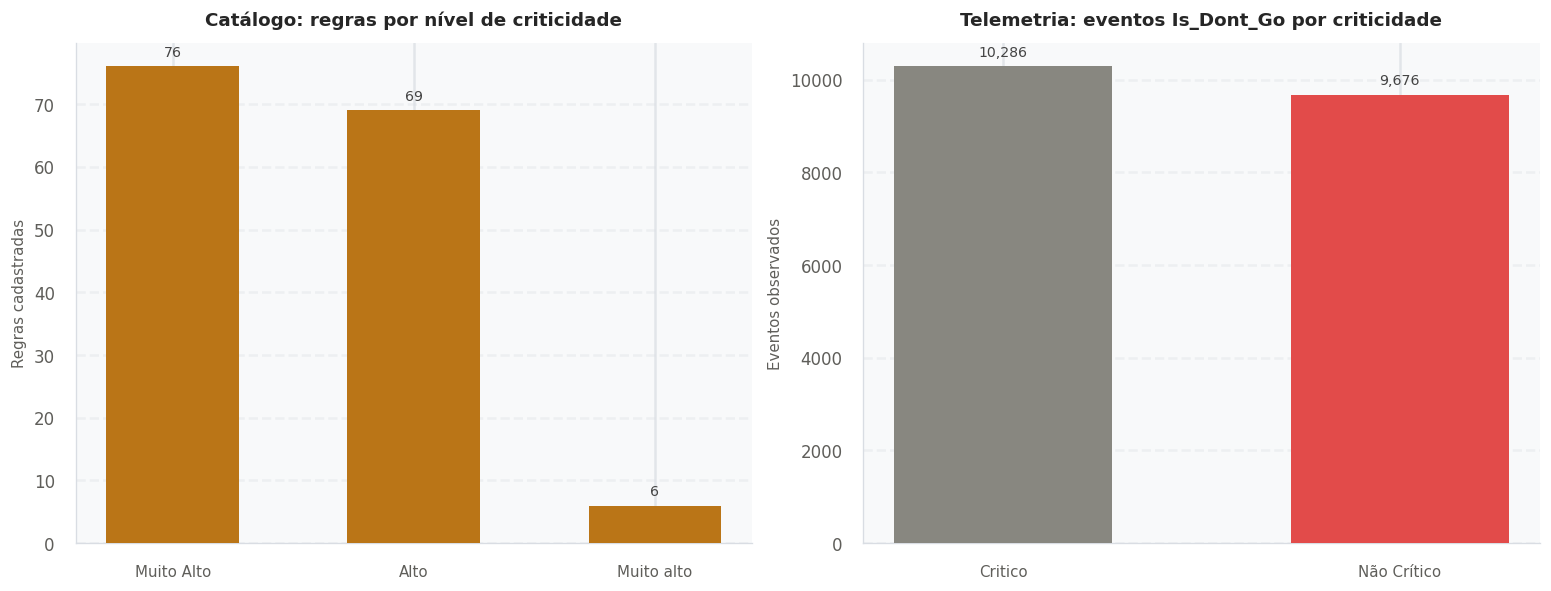

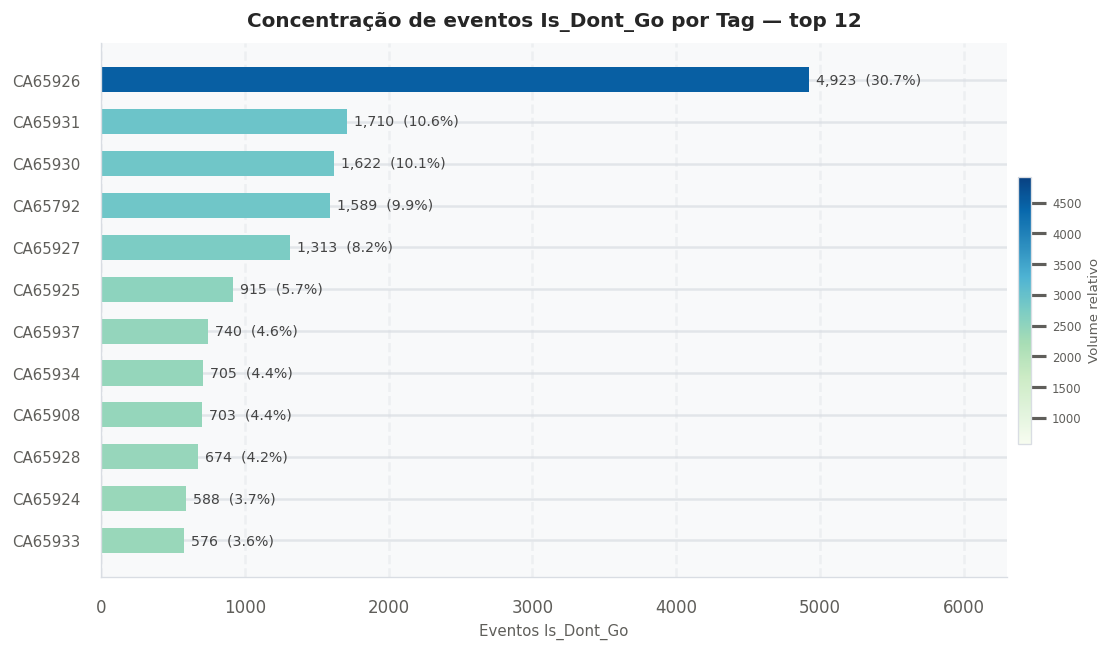

In [8]:
# ─── Carrega e consolida alertas ─────────────────────────────────────
ALERT_COLS = ["Data_Evento", "TAG", "Tipo", "Criticidade", "Alarme", "Is_Dont_Go"]

telemetry_alert_parts = []
for path in telemetry_files:
    tel = pd.read_parquet(path, columns=ALERT_COLS)
    tel_alerts = tel[tel["Is_Dont_Go"].astype(int).eq(1)].copy()
    telemetry_alert_parts.append(tel_alerts)

telemetry_alerts = (
    pd.concat(telemetry_alert_parts, ignore_index=True)
    if telemetry_alert_parts
    else pd.DataFrame(columns=ALERT_COLS)
)
telemetry_alerts["Data_Evento"] = pd.to_datetime(
    telemetry_alerts["Data_Evento"], errors="coerce", utc=True
)
telemetry_alerts["Criticidade"] = telemetry_alerts["Criticidade"].fillna("Sem criticidade")

# ─── Tabelas resumo ───────────────────────────────────────────────────
alert_summary = pd.DataFrame(
    [
        {"Indicador": "Eventos Is_Dont_Go observados", "Valor": fmt_int(len(telemetry_alerts))},
        {
            "Indicador": "Eventos críticos finais após regra de rotulação",
            "Valor": fmt_int(labeling_json["rows_critical_events_final"]),
        },
        {
            "Indicador": "Tags com evento crítico",
            "Valor": fmt_int(telemetry_alerts["TAG"].nunique()),
        },
        {
            "Indicador": "Período dos alertas",
            "Valor": (
                f"{telemetry_alerts['Data_Evento'].min().date()} "
                f"a {telemetry_alerts['Data_Evento'].max().date()}"
            ),
        },
    ]
)
display(
    alert_summary.style.hide(axis="index")
    .set_caption("Resumo de alertas observados")
    .set_table_styles(table_style_rules)
)

rules_by_level = rules_df.groupby(["TIPO", "NIVEL"], dropna=False).size().reset_index(name="regras")
observed_by_type_level = (
    telemetry_alerts.groupby(["Tipo", "Criticidade"], dropna=False)
    .size()
    .reset_index(name="eventos_observados")
)
top_tags_alerts = (
    telemetry_alerts["TAG"]
    .value_counts()
    .head(12)
    .rename_axis("Tag")
    .reset_index(name="eventos_Is_Dont_Go")
)

for df, caption in [
    (
        rules_by_level.sort_values("regras", ascending=False).head(12),
        "Catálogo de regras por TIPO e NÍVEL",
    ),
    (
        observed_by_type_level.sort_values("eventos_observados", ascending=False),
        "Eventos observados por Tipo e Criticidade",
    ),
    (top_tags_alerts, "Tags com mais eventos Is_Dont_Go observados"),
]:
    display(
        df.style.hide(axis="index")
        .bar(subset=[c for c in df.select_dtypes("number").columns], color="#3266ad44", vmin=0)
        .set_caption(caption)
        .set_table_styles(table_style_rules)
    )


# ─── Paleta semântica por nível ───────────────────────────────────────
ALERT_BG = "#f8f9fa"

LEVEL_COLORS = {
    "Crítico": "#E24B4A",
    "Critical": "#E24B4A",
    "Alto": "#BA7517",
    "High": "#BA7517",
    "Médio": "#3266ad",
    "Medium": "#3266ad",
    "Baixo": "#1D9E75",
    "Low": "#1D9E75",
}


def level_color(val, fallback="#888780"):
    for k, v in LEVEL_COLORS.items():
        if k.lower() in str(val).lower():
            return v
    return fallback


plt.rcParams.update(
    {
        "font.size": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


# ─── Figura 1: regras por nível e eventos por criticidade ─────────────
nivel_counts = rules_df["NIVEL"].fillna("Sem nível").value_counts().sort_values(ascending=False)
crit_counts = telemetry_alerts["Criticidade"].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, counts, title, ylabel in [
    (axes[0], nivel_counts, "Catálogo: regras por nível de criticidade", "Regras cadastradas"),
    (axes[1], crit_counts, "Telemetria: eventos Is_Dont_Go por criticidade", "Eventos observados"),
]:
    colors = [level_color(v) for v in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, width=0.55, edgecolor="none", zorder=3)
    for bar, v in zip(bars, counts.values, strict=False):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + counts.max() * 0.015,
            f"{v:,.0f}",
            ha="center",
            va="bottom",
            fontsize=8.5,
            color="#444",
        )
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_facecolor(ALERT_BG)
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax.tick_params(axis="x", labelsize=9)

plt.tight_layout()
plt.show()


# ─── Figura 2: concentração por Tag (barras horizontais) ─────────────
top_sorted = top_tags_alerts.sort_values("eventos_Is_Dont_Go")
total = top_sorted["eventos_Is_Dont_Go"].sum()
max_v = top_sorted["eventos_Is_Dont_Go"].max()

# Gradiente teal → azul conforme volume
norm = top_sorted["eventos_Is_Dont_Go"].values / max_v
bar_colors = [plt.cm.colors.to_hex(plt.cm.GnBu(0.35 + 0.55 * n)) for n in norm]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(
    top_sorted["Tag"],
    top_sorted["eventos_Is_Dont_Go"],
    color=bar_colors,
    height=0.6,
    edgecolor="none",
)

for bar, v in zip(bars, top_sorted["eventos_Is_Dont_Go"], strict=False):
    share = v / total * 100
    ax.text(
        bar.get_width() + max_v * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{v:,.0f}  ({share:.1f}%)",
        va="center",
        ha="left",
        fontsize=8.5,
        color="#444",
    )

ax.set_title(
    "Concentração de eventos Is_Dont_Go por Tag — top 12", fontsize=12, fontweight="bold", pad=10
)
ax.set_xlabel("Eventos Is_Dont_Go", fontsize=9)
ax.set_xlim(0, max_v * 1.28)
ax.set_facecolor(ALERT_BG)
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.tick_params(axis="y", labelsize=9)

# Mini colorbar como legenda de volume
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.GnBu, norm=plt.Normalize(vmin=top_sorted["eventos_Is_Dont_Go"].min(), vmax=max_v)
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.01, aspect=20)
cbar.set_label("Volume relativo", fontsize=8)
cbar.ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

## 5. EDA Orientada à Decisão

A EDA precisa responder se existe sinal suficiente para priorizar equipamentos antes de alertas críticos. A análise combina dinâmica temporal, concentração operacional e sinais numéricos associados ao risco.


### 5.1 Dinâmica Temporal e Prevalência

A primeira leitura da EDA verifica volume diário, prevalência do alvo e cortes temporais de treino, validação e teste.


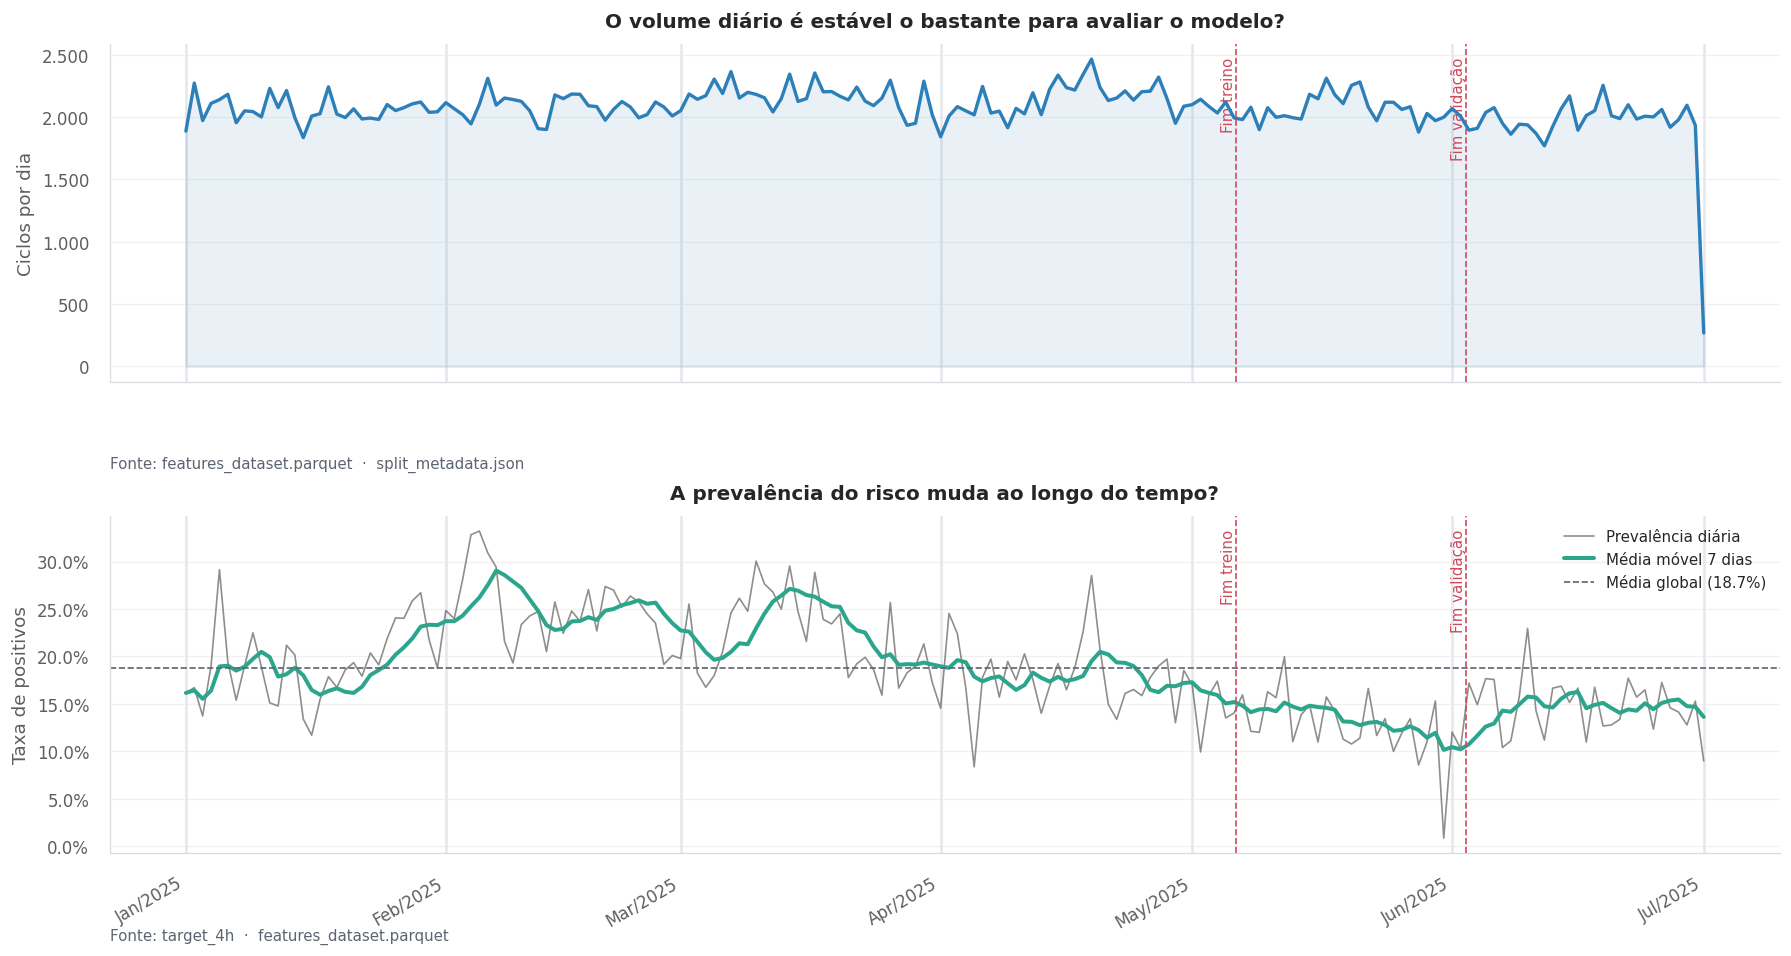

**Insight operacional:** há variação temporal relevante na prevalência; preservar a ordem cronológica no treino e na avaliação é obrigatório para evitar otimismo artificial.

In [9]:
# ── Agregação diária ───────────────────────────────────────────────────────────
daily = (
    features_df.groupby("dia")
    .agg(
        ciclos=("Id", "count"),
        prevalencia=("target_4h", "mean"),
    )
    .reset_index()
    .sort_values("dia")
)
daily["dia"] = pd.to_datetime(daily["dia"], utc=True).dt.tz_convert(None)
dias = daily["dia"].to_numpy()
ciclos_diarios = daily["ciclos"].to_numpy(dtype=float)
prevalencia_diaria = daily["prevalencia"].to_numpy(dtype=float)

# ── Datas de corte ─────────────────────────────────────────────────────────────
split_dates = {
    "Fim treino": pd.to_datetime(split_json["train_end"], utc=True).tz_convert(None),
    "Fim validação": pd.to_datetime(split_json["val_end"], utc=True).tz_convert(None),
}

prevalencia_global = features_df["target_4h"].mean()
roll_prev = daily["prevalencia"].rolling(7, min_periods=1).mean().to_numpy(dtype=float)


# ── Helpers de anotação ────────────────────────────────────────────────────────
def _add_split_lines(ax: plt.Axes, dates: dict, color: str) -> None:
    """Desenha linhas verticais de corte e anota o rótulo no topo do eixo."""
    ymax = ax.get_ylim()[1]
    for label, date in dates.items():
        ax.axvline(date, color=color, linestyle="--", linewidth=1, zorder=3)
        ax.text(
            date,
            ymax * 0.96,
            label,
            rotation=90,
            va="top",
            ha="right",
            fontsize=9,
            color=color,
        )


def _hide_spines(ax: plt.Axes) -> None:
    """Remove bordas superiores e direitas de forma compatível."""
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)


# ── Figura ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.subplots_adjust(hspace=0.08)

# ── Painel 1: Volume diário ────────────────────────────────────────────────────
ax0 = axes[0]
ax0.plot(
    dias,
    ciclos_diarios,
    color=PALETTE["blue"],
    linewidth=2,
    zorder=4,
)
ax0.fill_between(
    dias,
    ciclos_diarios,
    color=PALETTE["blue"],
    alpha=0.10,
)
ax0.set_title(
    "O volume diário é estável o bastante para avaliar o modelo?",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
ax0.set_ylabel("Ciclos por dia")
ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt_int(x)))
ax0.grid(axis="y", color="0.92", linewidth=0.7, zorder=0)
_hide_spines(ax0)

_add_split_lines(ax0, split_dates, color=PALETTE["red"])
add_source_note(ax0, "Fonte: features_dataset.parquet  ·  split_metadata.json")

# ── Painel 2: Prevalência do risco ─────────────────────────────────────────────
ax1 = axes[1]
ax1.plot(
    dias,
    prevalencia_diaria,
    color=PALETTE["gray"],
    linewidth=1,
    alpha=0.7,
    label="Prevalência diária",
)
ax1.plot(
    dias,
    roll_prev,
    color=PALETTE["teal"],
    linewidth=2.4,
    label="Média móvel 7 dias",
)
ax1.axhline(
    prevalencia_global,
    color=PALETTE["slate"],
    linestyle="--",
    linewidth=1,
    label=f"Média global ({prevalencia_global:.1%})",
)
ax1.set_title(
    "A prevalência do risco muda ao longo do tempo?",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
ax1.set_ylabel("Taxa de positivos")
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.grid(axis="y", color="0.92", linewidth=0.7, zorder=0)
_hide_spines(ax1)
ax1.legend(loc="upper right", framealpha=0.9, fontsize=9)

_add_split_lines(ax1, split_dates, color=PALETTE["red"])
add_source_note(ax1, "Fonte: target_4h  ·  features_dataset.parquet")

# ── Eixo X compartilhado ───────────────────────────────────────────────────────
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
fig.autofmt_xdate(rotation=30, ha="right")

plt.tight_layout()
plt.show()

# ── Insight ───────────────────────────────────────────────────────────────────
display(
    Markdown(
        "**Insight operacional:** há variação temporal relevante na prevalência; "
        "preservar a ordem cronológica no treino e na avaliação é obrigatório "
        "para evitar otimismo artificial."
    )
)

### 5.2 Concentração Operacional

A segunda leitura resume concentração por categorias operacionais, ajudando a separar padrões estruturais de ruído pontual.


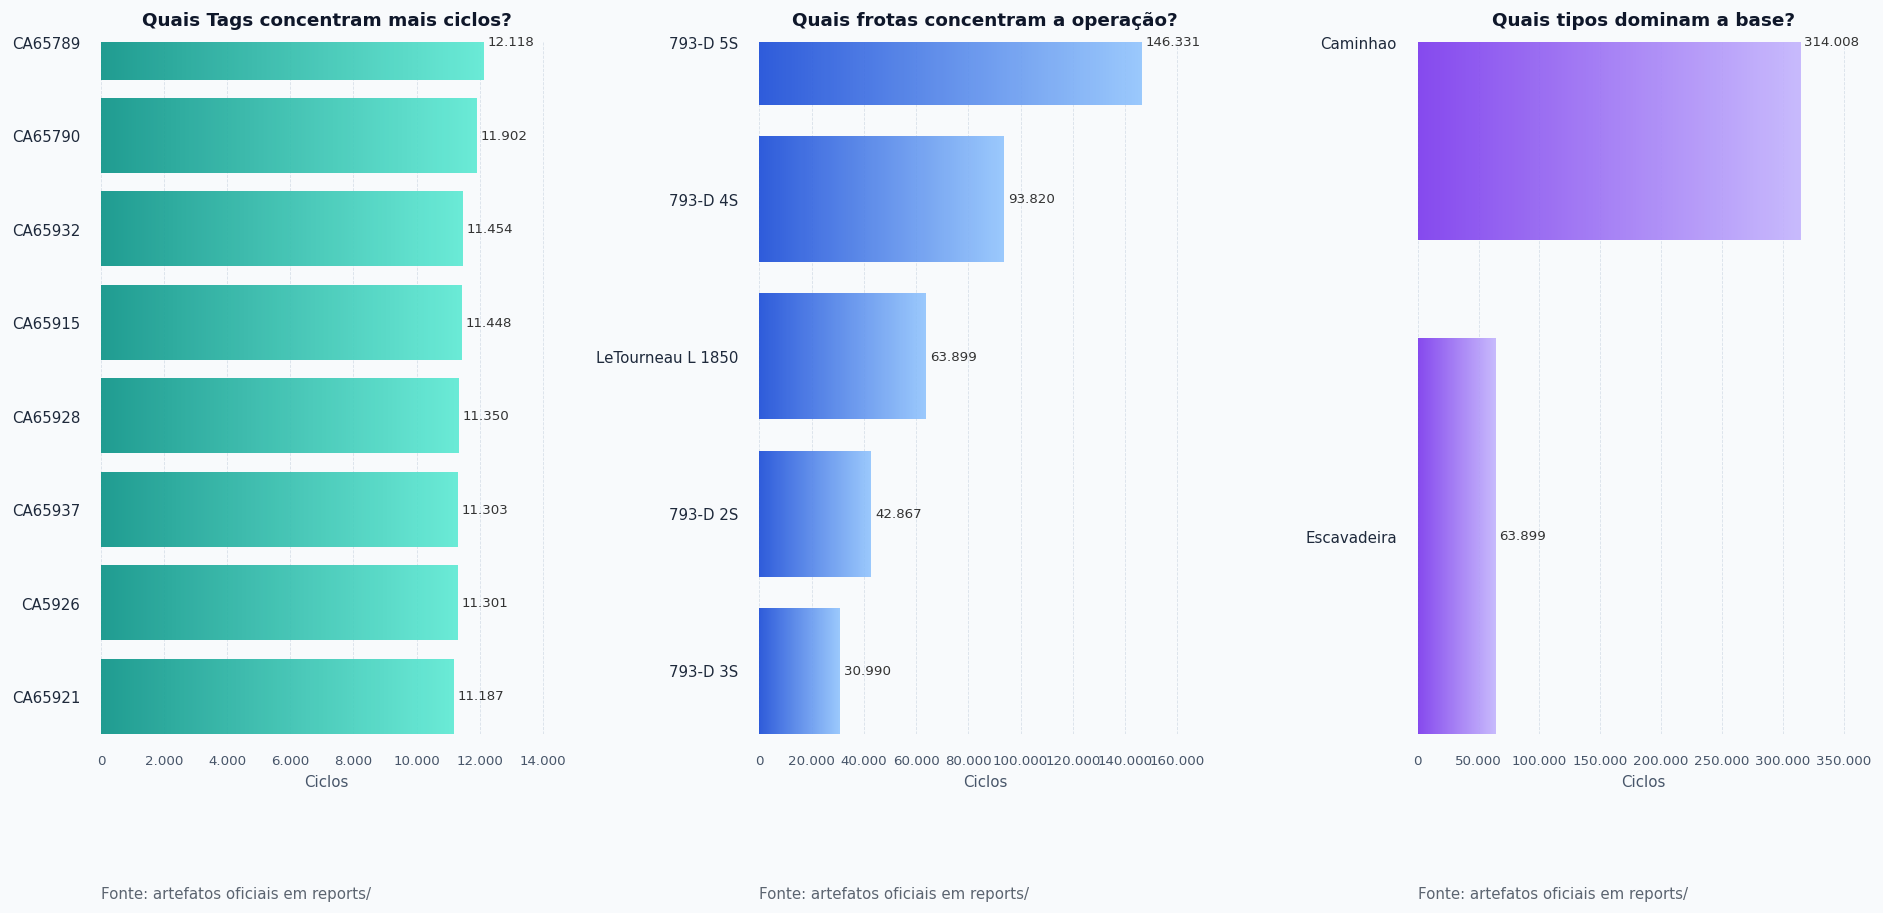

In [10]:
def pareto_table(series, top=10):
    counts = series.fillna("desconhecido").astype(str).value_counts().head(top)
    out = counts.rename_axis("categoria").reset_index(name="ciclos")
    out["participação"] = out["ciclos"] / len(series)
    out["participação_acumulada"] = out["participação"].cumsum()
    return out


def add_gradient_bars(ax, table, color_start, color_end, orientation="h"):
    """Substitui as barras sólidas por barras com degradê horizontal."""
    ax.cla()  # limpa barras antigas

    n = len(table)
    categorias = table["categoria"].tolist()
    valores = table["ciclos"].tolist()
    max_val = max(valores) if valores else 1

    for i, (_cat, val) in enumerate(zip(categorias, valores, strict=False)):
        # degradê da esquerda (color_start) para a direita (color_end)
        grad = np.linspace(0, 1, 256).reshape(1, -1)
        cmap = mcolors.LinearSegmentedColormap.from_list("grad", [color_start, color_end])

        extent = [0, val, i - 0.4, i + 0.4]
        ax.imshow(
            grad,
            aspect="auto",
            extent=extent,
            cmap=cmap,
            alpha=0.92,
            zorder=2,
        )
        # borda sutil
        rect = mpatches.FancyBboxPatch(
            (0, i - 0.4),
            val,
            0.8,
            boxstyle="round,pad=0.01",
            linewidth=0,
            facecolor="none",
            edgecolor="none",
            zorder=3,
        )
        ax.add_patch(rect)

    ax.set_yticks(range(n))
    ax.set_yticklabels(categorias)
    ax.set_xlim(0, max_val * 1.18)
    ax.invert_yaxis()

    # labels de valor
    for i, val in enumerate(valores):
        ax.text(
            val + max_val * 0.01,
            i,
            fmt_int(val),
            va="center",
            ha="left",
            fontsize=8,
            color="#333333",
            zorder=5,
        )


# ── Paleta de degradês ──────────────────────────────────────────────────────
GRADIENT_CONFIGS = [
    ("#0d9488", "#5eead4"),  # teal escuro → teal claro  (Tags)
    ("#1d4ed8", "#93c5fd"),  # azul escuro → azul claro  (Frotas)
    ("#7c3aed", "#c4b5fd"),  # roxo escuro → roxo claro  (Tipos)
]

fig, axes = plt.subplots(1, 3, figsize=(16, 8))
fig.patch.set_facecolor("#f8fafc")

paretos = [
    ("Tag" if "Tag" in features_df.columns else None, "Quais Tags concentram mais ciclos?"),
    ("frota_decoded", "Quais frotas concentram a operação?"),
    ("tipo_decoded", "Quais tipos dominam a base?"),
]

for ax, (column, title), (c_start, c_end) in zip(axes, paretos, GRADIENT_CONFIGS, strict=False):
    ax.set_facecolor("#f8fafc")

    if column is None:
        ax.axis("off")
        ax.text(
            0.5,
            0.5,
            "Tag não disponível\nna base de features",
            ha="center",
            va="center",
            fontsize=12,
            color="#64748b",
        )
        continue

    table = pareto_table(features_df[column], top=8)

    # barras com degradê
    add_gradient_bars(ax, table, c_start, c_end, orientation="h")

    # formatação dos eixos
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt_int(x)))
    ax.tick_params(axis="x", labelsize=8, colors="#475569")
    ax.tick_params(axis="y", labelsize=9, colors="#1e293b")

    # grid leve
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, color="#cbd5e1", linewidth=0.5, linestyle="--")
    ax.yaxis.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(title, fontsize=11, fontweight="bold", color="#0f172a", pad=10)
    ax.set_xlabel("Ciclos", fontsize=9, color="#475569")
    ax.set_ylabel("")

    add_source_note(ax)

plt.tight_layout(pad=2.0)
plt.show()

### 5.3 Risco por Categorias e Padrões Temporais

Este complemento explicita a taxa de alertas por `Frota`, `Tipo`, `Classe`, `Tag`, hora/dia e turno. As hipóteses ficam registradas mesmo quando a evidência é apenas associativa, não causal.


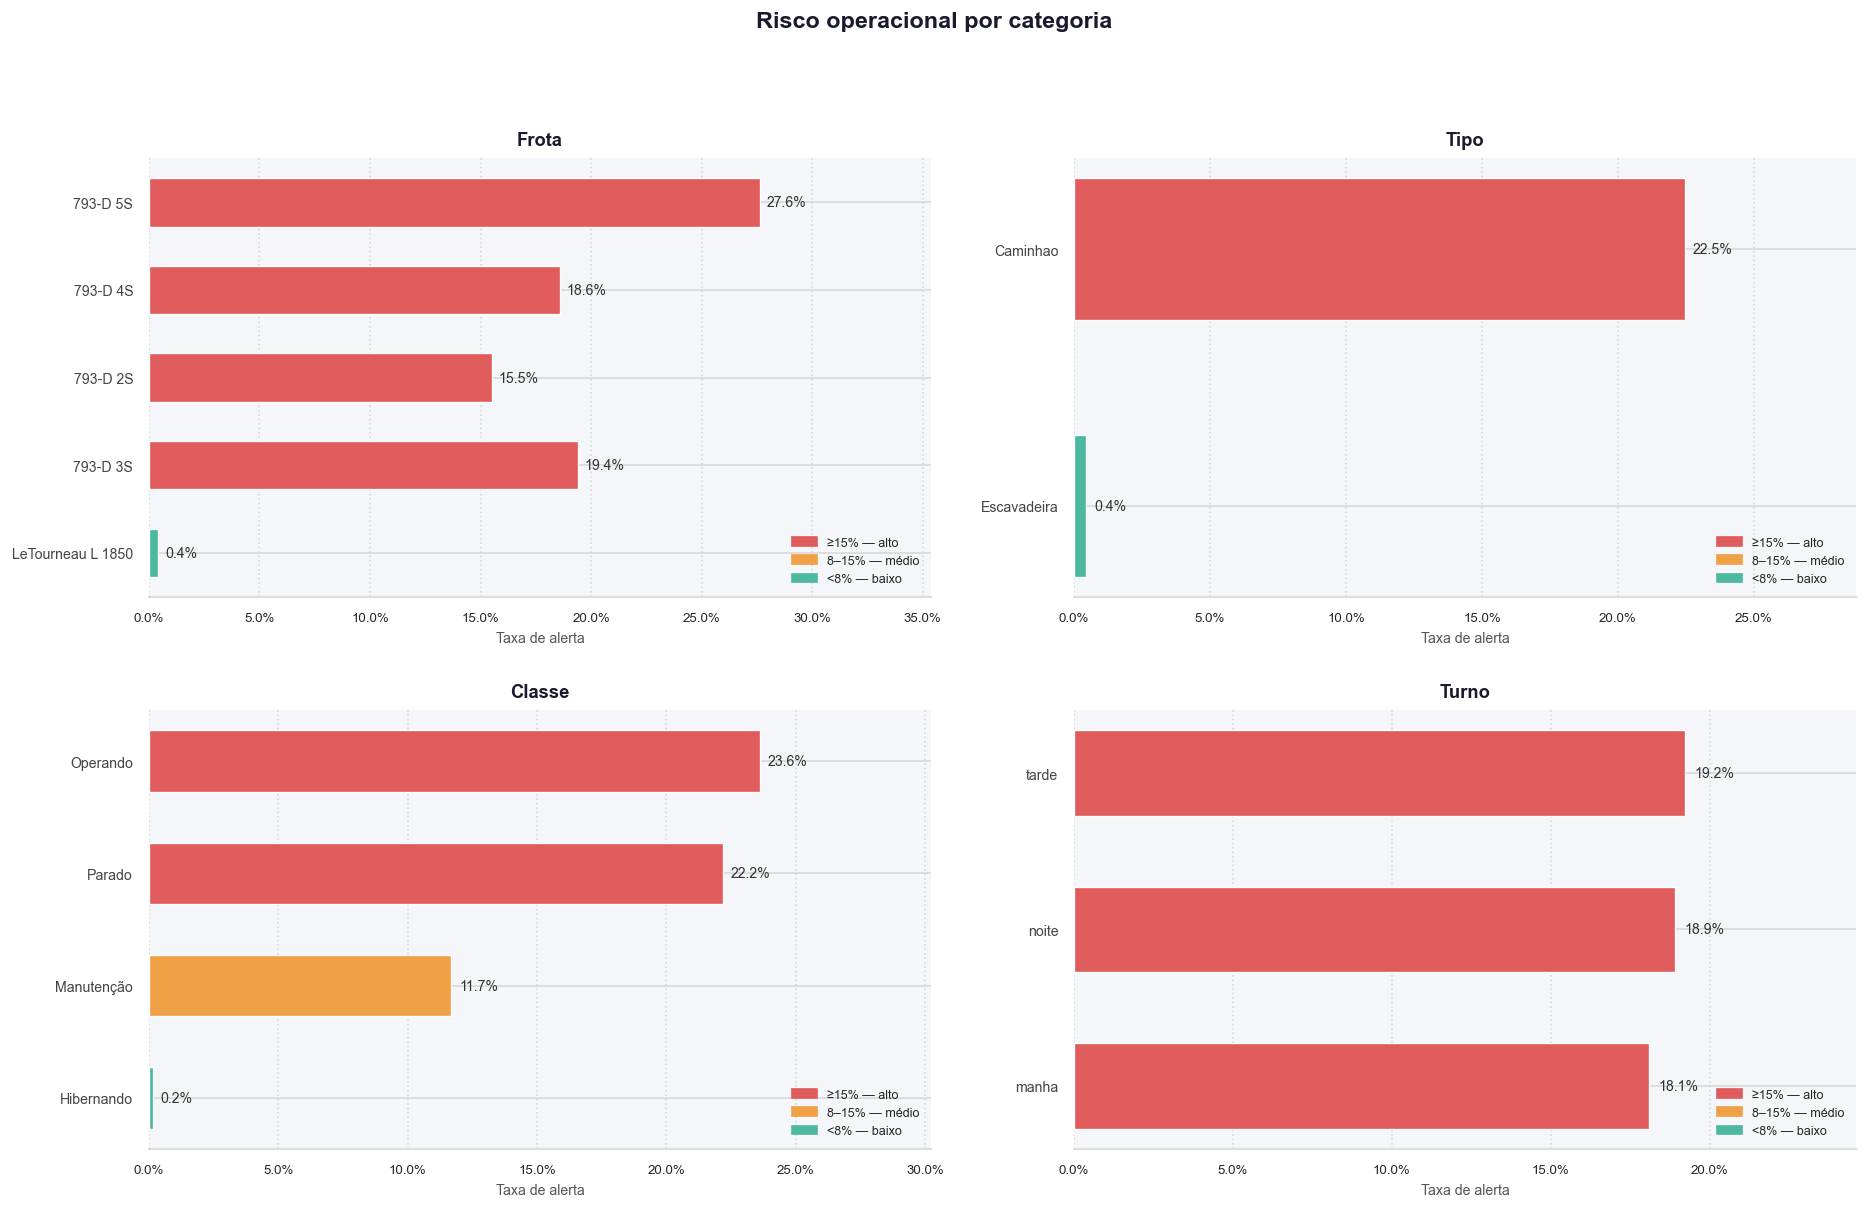

frota_decoded,ciclos,positivos,taxa_alerta
793-D 5S,146331,40439,27.64%
793-D 4S,93820,17433,18.58%
793-D 2S,42867,6649,15.51%
793-D 3S,30990,6016,19.41%
LeTourneau L 1850,63899,274,0.43%


tipo_decoded,ciclos,positivos,taxa_alerta
Caminhao,314008,70537,22.46%
Escavadeira,63899,274,0.43%


Classe,ciclos,positivos,taxa_alerta
Operando,182527,43100,23.61%
Parado,106531,23652,22.20%
Manutenção,33981,3973,11.69%
Hibernando,54868,86,0.16%


turno,ciclos,positivos,taxa_alerta
tarde,127029,24414,19.22%
noite,124348,23493,18.89%
manha,126530,22904,18.10%


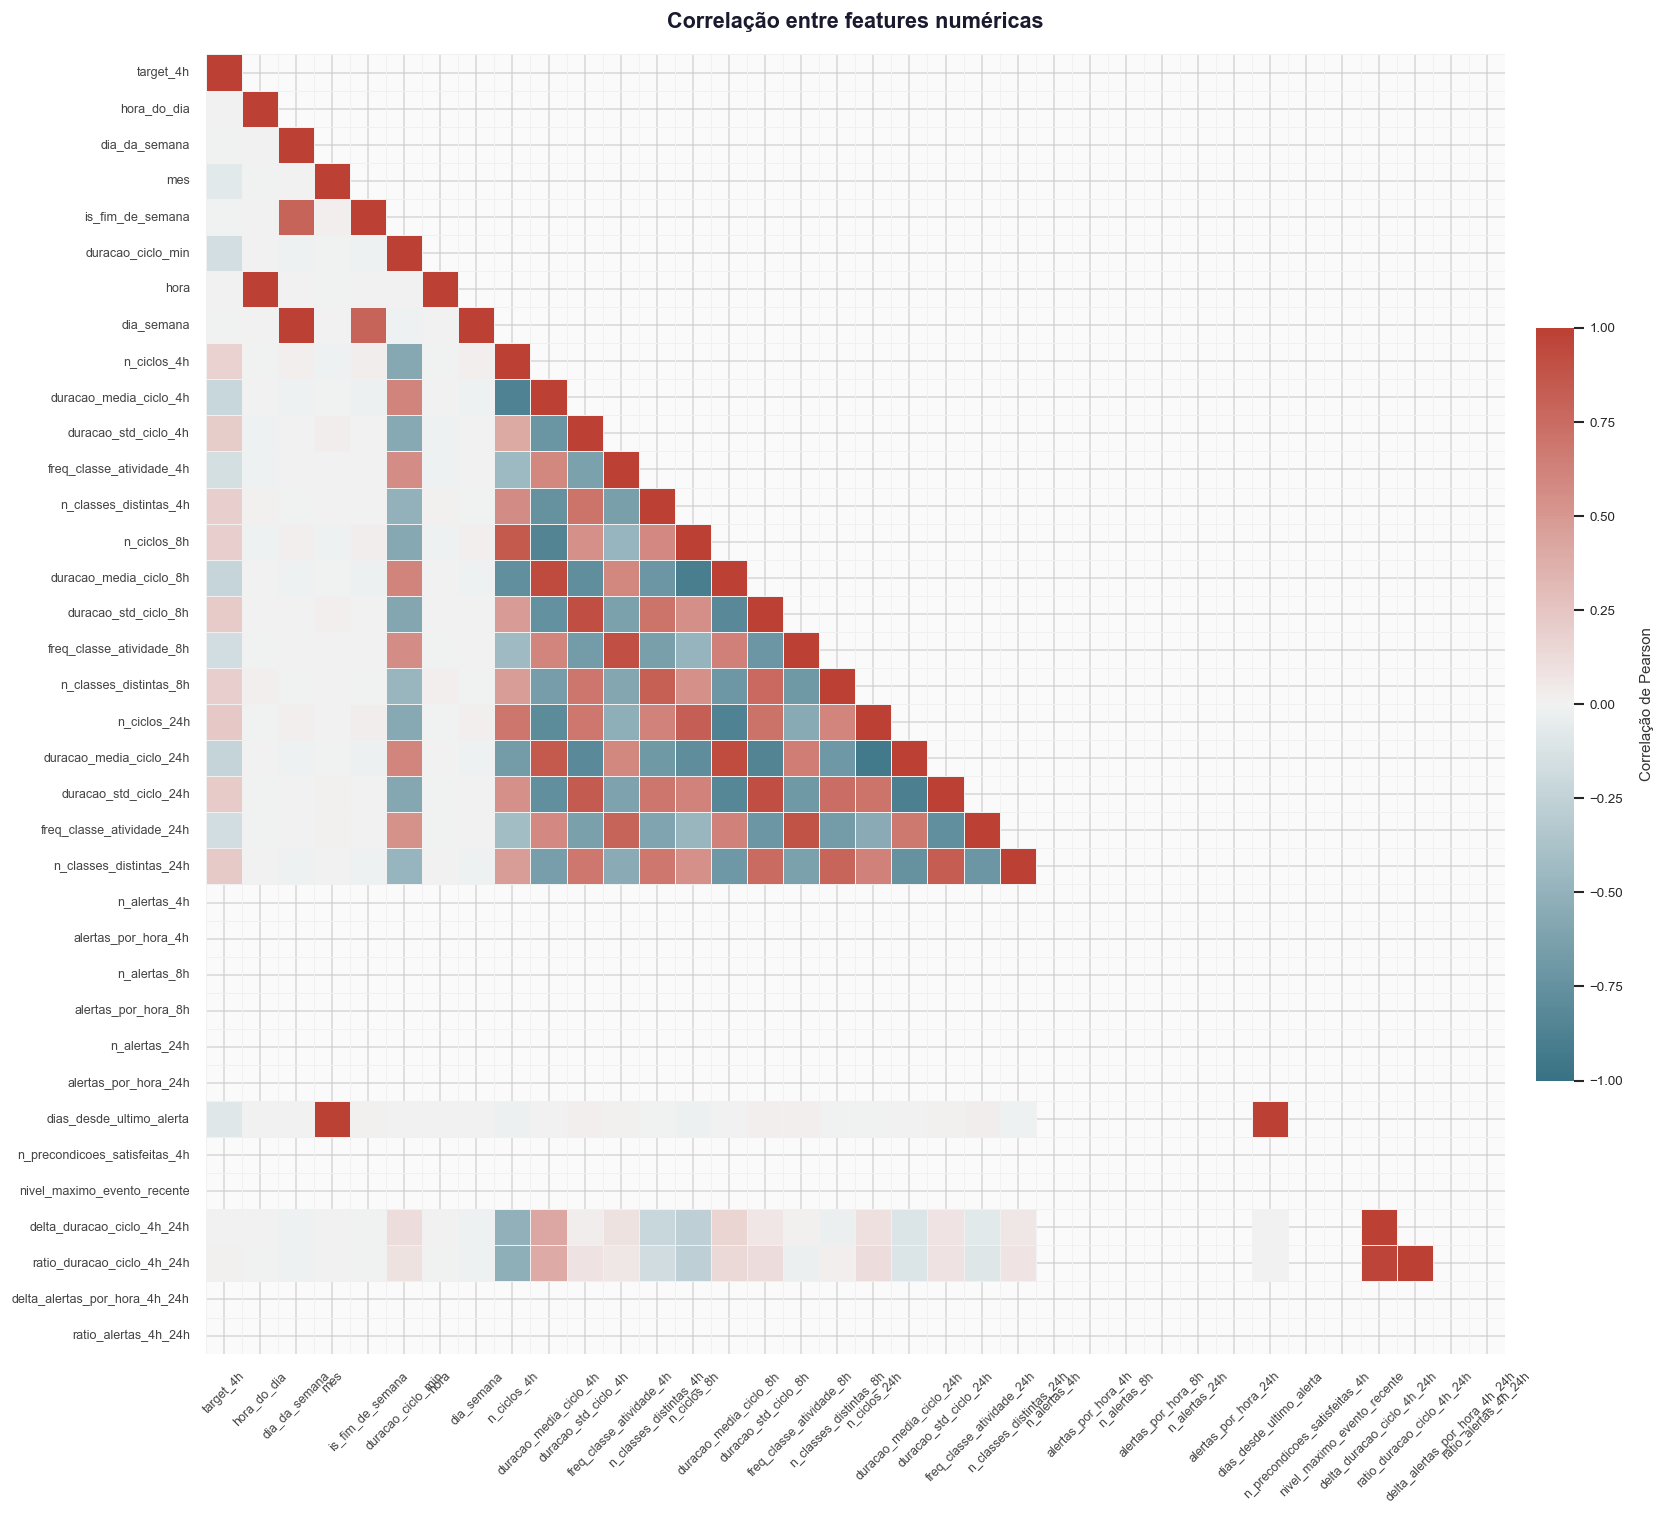

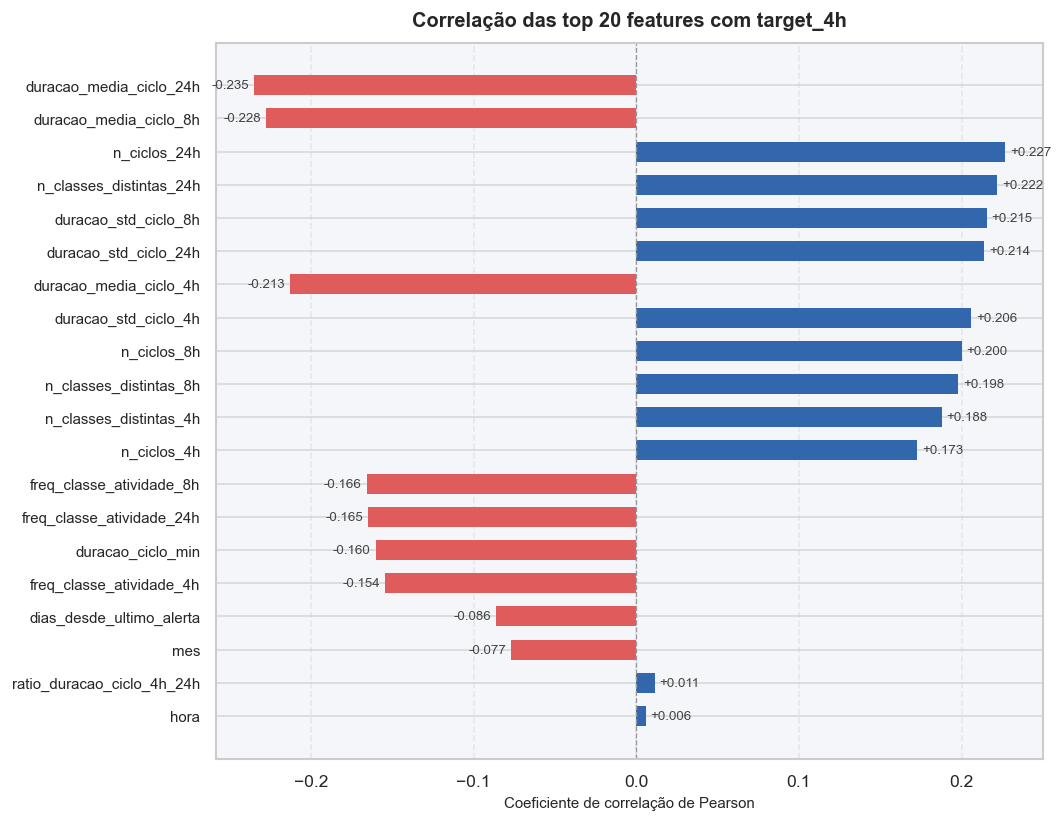

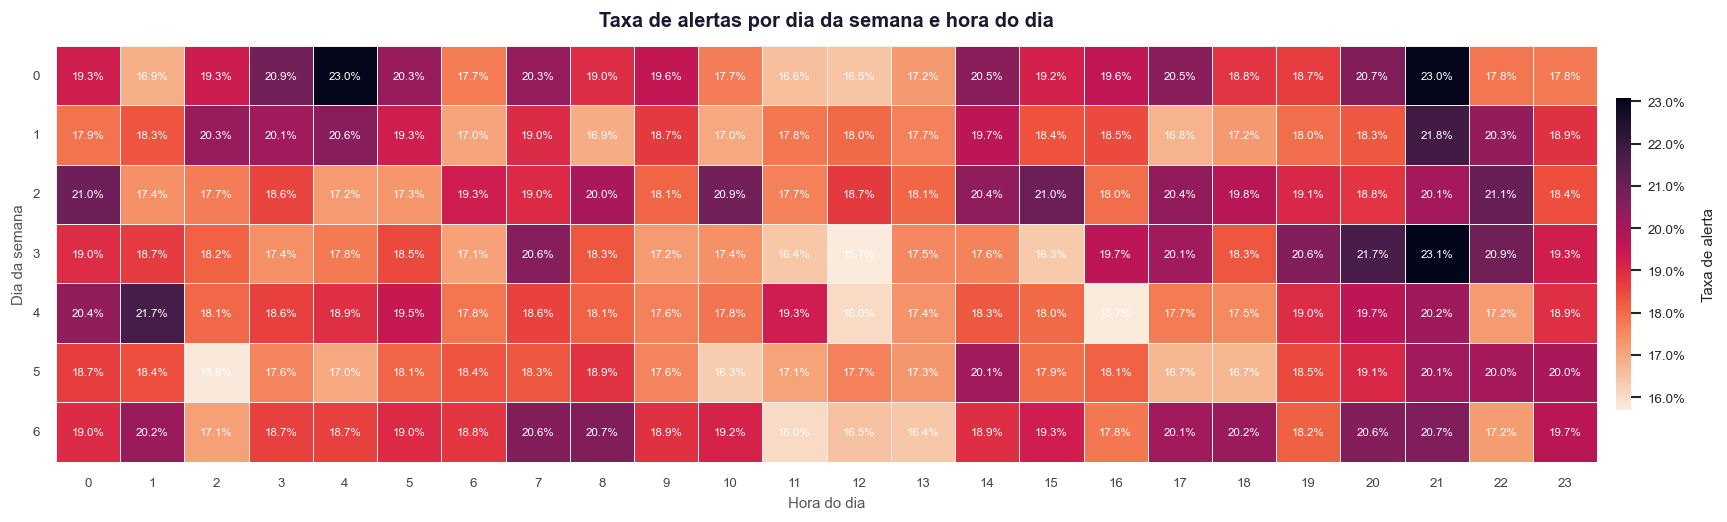

Hipótese EDA,Evidência,Uso no modelo
Risco varia no tempo,Prevalência diária e heatmap hora × dia,"Features de hora, dia, mês e turno"
Histórico recente importa,Features rolling e importância de recência,"Janelas 4h, 8h e 24h por Tag"
Categorias operacionais concentram risco,"Taxa por Frota, Tipo e Classe",One-hot / frequency / target encoding
Outliers podem carregar sinal,Durações extremas preservadas,Duração e deltas sem truncamento automático


In [11]:
# ─── Paleta e estilo ────────────────────────────────────────────────
PALETTE.update(
    {
        "high": "#e05c5c",  # coral suave
        "mid": "#f0a045",  # âmbar elegante
        "low": "#4db8a0",  # teal sofisticado
        "blue": "#3266ad",
        "bg": "#f4f6f9",  # fundo levemente azulado
    }
)
sns.set_theme(style="whitegrid", font_scale=0.95)


# ─── Função auxiliar ────────────────────────────────────────────────
def risk_by_category(df, column, top=12):
    return (
        df.groupby(column, dropna=False)
        .agg(
            ciclos=("Id", "count"),
            positivos=("target_4h", "sum"),
            taxa_alerta=("target_4h", "mean"),
        )
        .sort_values(["positivos", "taxa_alerta"], ascending=False)
        .head(top)
        .reset_index()
    )


category_views = {
    "Frota": risk_by_category(features_df, "frota_decoded"),
    "Tipo": risk_by_category(features_df, "tipo_decoded"),
    "Classe": risk_by_category(features_df, "Classe"),
    "Turno": risk_by_category(features_df, "turno"),
}


# ─── 1. Risco por categoria (4 gráficos separados) ──────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor("#ffffff")
axes = axes.flatten()

for ax, (label, table) in zip(axes, category_views.items(), strict=False):
    taxa = table["taxa_alerta"].values
    cats = table[table.columns[0]].astype(str).values
    colors = [
        PALETTE["high"] if t >= 0.15 else PALETTE["mid"] if t >= 0.08 else PALETTE["low"]
        for t in taxa
    ]
    bars = ax.barh(
        cats[::-1], taxa[::-1], color=colors[::-1], height=0.55, edgecolor="white", linewidth=0.8
    )

    for bar, t in zip(bars, taxa[::-1], strict=False):
        ax.text(
            bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f"{t:.1%}",
            va="center",
            ha="left",
            fontsize=8.5,
            color="#333",
            fontweight="500",
        )

    ax.set_title(f"{label}", fontsize=11, fontweight="bold", pad=8, color="#1a1a2e")
    ax.set_xlabel("Taxa de alerta", fontsize=8.5, color="#555")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_xlim(0, taxa.max() * 1.28)
    ax.tick_params(axis="y", labelsize=8.5, colors="#444")
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="x", linestyle=":", alpha=0.5, color="#bbb")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#ddd")
    ax.set_facecolor(PALETTE["bg"])

    ax.legend(
        handles=[
            Patch(color=PALETTE["high"], label="≥15% — alto"),
            Patch(color=PALETTE["mid"], label="8–15% — médio"),
            Patch(color=PALETTE["low"], label="<8% — baixo"),
        ],
        fontsize=7.5,
        loc="lower right",
        framealpha=0.95,
        edgecolor="#ddd",
        fancybox=False,
    )

plt.suptitle(
    "Risco operacional por categoria", fontsize=14, fontweight="bold", color="#1a1a2e", y=1.02
)
plt.tight_layout(pad=2.0)
plt.show()

# Exibe tabelas estilizadas abaixo
for label, table in category_views.items():
    display(
        table.style.hide(axis="index")
        .format({"taxa_alerta": "{:.2%}"})
        .bar(subset=["taxa_alerta"], color="#3266ad44", vmin=0)
        .set_caption(f"Taxa de target_4h por {label}")
    )


# ─── 2. Heatmap de correlação ────────────────────────────────────────
eda_feature_columns = selection_json["feature_columns"]
numeric_corr_cols = [
    c
    for c in eda_feature_columns
    if c in features_df.columns and pd.api.types.is_numeric_dtype(features_df[c])
]
selected_corr_cols = ["target_4h"] + numeric_corr_cols[:35]
corr_matrix = features_df[selected_corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(15, 13))
fig.patch.set_facecolor("#ffffff")

# Máscara do triângulo superior — mais limpo e legível
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

cmap = sns.diverging_palette(220, 15, s=75, l=45, as_cmap=True)  # azul ↔ vermelho refinado

sns.heatmap(
    corr_matrix,
    cmap=cmap,
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    mask=mask,
    linewidths=0.5,
    linecolor="#f0f0f0",
    square=True,
    cbar_kws={
        "shrink": 0.55,
        "label": "Correlação de Pearson",
        "orientation": "vertical",
        "pad": 0.02,
    },
    annot=len(selected_corr_cols) <= 15,
    fmt=".2f",
    annot_kws={"size": 7, "color": "#222"},
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Correlação de Pearson", fontsize=9, color="#333", labelpad=10)

ax.set_title(
    "Correlação entre features numéricas", fontsize=13, fontweight="bold", pad=16, color="#1a1a2e"
)
ax.tick_params(axis="x", rotation=45, labelsize=7.5, colors="#444")
ax.tick_params(axis="y", rotation=0, labelsize=7.5, colors="#444")
ax.set_facecolor("#fafafa")

plt.tight_layout()
plt.show()


# ─── 3. Barras de correlação com target_4h ──────────────────────────
target_corr = (
    corr_matrix["target_4h"].drop("target_4h").sort_values(key=abs, ascending=False).head(20)
)

fig, ax = plt.subplots(figsize=(9, 7))
colors = [PALETTE["high"] if v < 0 else PALETTE["blue"] for v in target_corr]
bars = ax.barh(
    target_corr.index[::-1],
    target_corr.values[::-1],
    color=colors[::-1],
    height=0.6,
    edgecolor="none",
)

for bar, v in zip(bars, target_corr.values[::-1], strict=False):
    xpos = bar.get_width() + (0.003 if v >= 0 else -0.003)
    ha = "left" if v >= 0 else "right"
    ax.text(
        xpos,
        bar.get_y() + bar.get_height() / 2,
        f"{v:+.3f}",
        va="center",
        ha=ha,
        fontsize=8,
        color="#444",
    )

ax.axvline(0, color="#999", linewidth=0.8, linestyle="--")
ax.set_title("Correlação das top 20 features com target_4h", fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Coeficiente de correlação de Pearson", fontsize=9)
ax.tick_params(axis="y", labelsize=9)
ax.set_facecolor(PALETTE["bg"])
ax.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()


# ─── 4. Heatmap hora × dia ──────────────────────────────────────────
hour_week = features_df.pivot_table(
    index="dia_da_semana",
    columns="hora_do_dia",
    values="target_4h",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(16, 4.5))
fig.patch.set_facecolor("#ffffff")

cmap_time = sns.color_palette("rocket_r", as_cmap=True)  # substitui YlOrRd genérico

sns.heatmap(
    hour_week,
    cmap=cmap_time,
    ax=ax,
    linewidths=0.4,
    linecolor="#f0f0f0",
    cbar_kws={
        "format": mticker.PercentFormatter(1.0),
        "shrink": 0.75,
        "label": "Taxa de alerta",
        "pad": 0.01,
    },
    annot=True,
    fmt=".1%",
    annot_kws={"size": 7, "color": "white", "fontweight": "500"},
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Taxa de alerta", fontsize=9, labelpad=10)

ax.set_title(
    "Taxa de alertas por dia da semana e hora do dia",
    fontsize=12,
    fontweight="bold",
    pad=12,
    color="#1a1a2e",
)
ax.set_xlabel("Hora do dia", fontsize=9, color="#555")
ax.set_ylabel("Dia da semana", fontsize=9, color="#555")
ax.tick_params(axis="x", rotation=0, labelsize=8, colors="#444")
ax.tick_params(axis="y", rotation=0, labelsize=8, colors="#444")

plt.tight_layout()
plt.show()


# ─── 5. Hipóteses da EDA ────────────────────────────────────────────
hypotheses = pd.DataFrame(
    [
        {
            "Hipótese EDA": "Risco varia no tempo",
            "Evidência": "Prevalência diária e heatmap hora × dia",
            "Uso no modelo": "Features de hora, dia, mês e turno",
        },
        {
            "Hipótese EDA": "Histórico recente importa",
            "Evidência": "Features rolling e importância de recência",
            "Uso no modelo": "Janelas 4h, 8h e 24h por Tag",
        },
        {
            "Hipótese EDA": "Categorias operacionais concentram risco",
            "Evidência": "Taxa por Frota, Tipo e Classe",
            "Uso no modelo": "One-hot / frequency / target encoding",
        },
        {
            "Hipótese EDA": "Outliers podem carregar sinal",
            "Evidência": "Durações extremas preservadas",
            "Uso no modelo": "Duração e deltas sem truncamento automático",
        },
    ]
)

display(
    hypotheses.style.hide(axis="index")
    .set_caption("Hipóteses registradas durante a EDA")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": "font-size:13px; font-weight:bold; text-align:left; padding-bottom:8px;",
            },
            {"selector": "th", "props": "background:#f0f4f8; font-weight:600; padding:8px 12px;"},
            {"selector": "td", "props": "padding:7px 12px;"},
        ]
    )
)

## 6. Feature Engineering e Prevenção de Vazamento

O modelo só pode usar informações disponíveis até o momento do ciclo. Variáveis que apontam diretamente para o futuro são mantidas para auditoria/rotulação, mas removidas da matriz modelável.


### 6.1 Famílias de Features e Controles Anti-Leakage

Esta seção documenta a passagem da base enriquecida para a matriz que o modelo realmente enxerga. A pergunta aqui não é apenas "quantas features existem", mas **quais sinais entram, quais colunas ficam fora e qual risco cada exclusão evita**.

A regra de corte foi conservadora: o modelo só pode usar informação disponível até o instante do ciclo. Por isso, saem da matriz final variáveis que revelam o futuro (`tte_horas`, `next_critical_event_time`), o próprio rótulo (`target_4h`), identificadores sem tratamento com risco de memorização (`Id`, `Tag`) e carimbos temporais sem tratamento (`Inicio`, `Fim`). Quando a informação é útil, ela reaparece de forma segura por meio de agregações históricas, recência, janelas móveis, frequência ou codificações calculadas sem olhar o período de teste.

O dashboard abaixo deve ser lido em quatro partes: primeiro o funil de colunas, depois a composição das famílias modeláveis, em seguida os motivos de retirada e, por fim, quais famílias aparecem com maior peso no artefato selecionado. Isso separa engenharia de features de governança anti-vazamento.


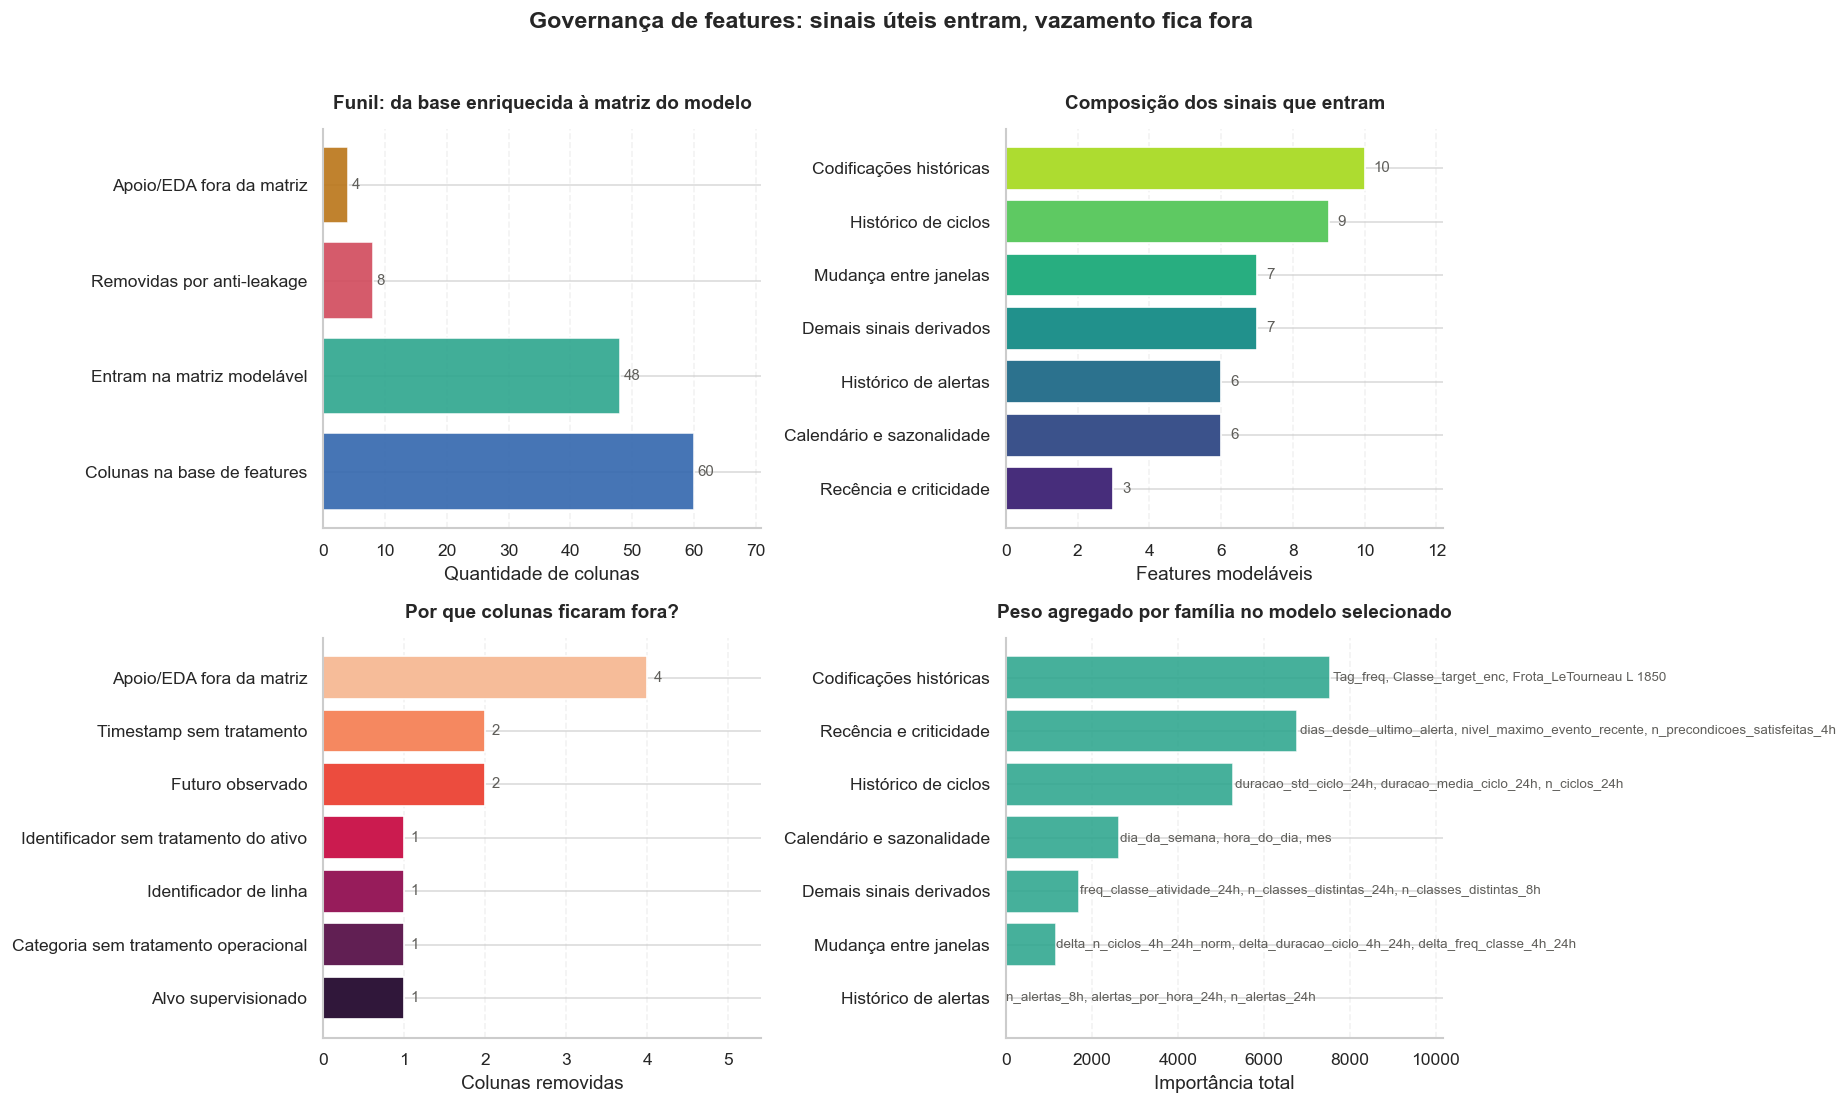

Família,Qtd. features,Exemplos,Uso seguro
Codificações históricas,10,"Tag_freq, Operador_freq, Classe_target_enc, Frota_793-D 2S",substitui categorias sem tratamento por estatísticas/one-hot estáveis
Histórico de ciclos,9,"n_ciclos_4h, duracao_media_ciclo_4h, duracao_std_ciclo_4h, n_ciclos_8h",resume volume e duração observados em janelas passadas
Demais sinais derivados,7,"duracao_ciclo_min, freq_classe_atividade_4h, n_classes_distintas_4h, freq_classe_atividade_8h",sinais auxiliares criados pelo pipeline de features
Mudança entre janelas,7,"delta_duracao_ciclo_4h_24h, ratio_duracao_ciclo_4h_24h, delta_alertas_por_hora_4h_24h, ratio_alertas_4h_24h",compara curto vs. longo prazo para detectar degradação
Calendário e sazonalidade,6,"hora_do_dia, dia_da_semana, mes, is_fim_de_semana","captura hora, dia e sazonalidade sem usar timestamp sem tratamento"
Histórico de alertas,6,"n_alertas_4h, alertas_por_hora_4h, n_alertas_8h, alertas_por_hora_8h",mede pressão recente de alertas antes do ciclo
Recência e criticidade,3,"dias_desde_ultimo_alerta, n_precondicoes_satisfeitas_4h, nivel_maximo_evento_recente",quantifica proximidade e severidade de eventos já observados


Coluna fora da matriz,Grupo de exclusão,Risco evitado,Uso seguro ou substituto
target_4h,Alvo supervisionado,é exatamente o que o modelo deve prever,usado apenas como y no treino e na avaliação
dia,Apoio/EDA fora da matriz,"útil para leitura, mas não promovido ao artefato final",mantido para análise ou segmentação
frota_decoded,Apoio/EDA fora da matriz,"útil para leitura, mas não promovido ao artefato final",mantido para análise ou segmentação
tipo_decoded,Apoio/EDA fora da matriz,"útil para leitura, mas não promovido ao artefato final",mantido para análise ou segmentação
turno,Apoio/EDA fora da matriz,"útil para leitura, mas não promovido ao artefato final",mantido para análise ou segmentação
Classe,Categoria sem tratamento operacional,entra de forma controlada para reduzir cardinalidade e vazamento,substituída por Classe_target_enc e frequências históricas
next_critical_event_time,Futuro observado,revela quando ocorrerá o próximo alerta crítico,"usado só para rotulação, auditoria e validação"
tte_horas,Futuro observado,revela quando ocorrerá o próximo alerta crítico,"usado só para rotulação, auditoria e validação"
Id,Identificador de linha,não carrega mecanismo operacional generalizável,removido; não há substituto modelável
Tag,Identificador sem tratamento do ativo,alta cardinalidade pode memorizar ativo específico,"substituído por Tag_freq, recência e histórico de alertas"


feature,Família,importance
dias_desde_ultimo_alerta,Recência e criticidade,6763
Tag_freq,Codificações históricas,5670
duracao_std_ciclo_24h,Histórico de ciclos,1496
dia_da_semana,Calendário e sazonalidade,1201
hora_do_dia,Calendário e sazonalidade,1085
duracao_media_ciclo_24h,Histórico de ciclos,952
n_ciclos_24h,Histórico de ciclos,904
Classe_target_enc,Codificações históricas,787
duracao_std_ciclo_8h,Histórico de ciclos,631
freq_classe_atividade_24h,Demais sinais derivados,613


**Leitura:** de `60` colunas disponíveis em `features_dataset.parquet`, `48` entram na matriz final. As `8` colunas de anti-leakage (`Classe`, `Fim`, `Id`, `Inicio`, `Tag`, `next_critical_event_time`, `target_4h`, `tte_horas`) ficam fora porque revelam o alvo, o futuro ou identificadores sem tratamento. O sinal operacional é preservado por versões históricas: janelas móveis, recência, frequências e codificações calculadas sem usar informação posterior ao ciclo.

In [12]:
feature_columns = selection_json["feature_columns"]
leakage_columns = selection_json.get("leakage_columns", [])
all_cols = features_df.columns.tolist()
modelable_set = set(feature_columns)
leakage_set = set(leakage_columns)
non_modelable_cols = [col for col in all_cols if col not in modelable_set]
support_only_cols = [col for col in non_modelable_cols if col not in leakage_set]


def feature_family(feature):
    if feature in {"hora_do_dia", "hora", "dia_da_semana", "dia_semana", "mes", "is_fim_de_semana"}:
        return "Calendário e sazonalidade"
    if (
        feature.startswith("n_ciclos_")
        or feature.startswith("duracao_media")
        or feature.startswith("duracao_std")
    ):
        return "Histórico de ciclos"
    if feature.startswith("n_alertas_") or feature.startswith("alertas_por_hora"):
        return "Histórico de alertas"
    if feature.startswith("delta_") or feature.startswith("ratio_"):
        return "Mudança entre janelas"
    if feature in {
        "dias_desde_ultimo_alerta",
        "nivel_maximo_evento_recente",
        "n_precondicoes_satisfeitas_4h",
    }:
        return "Recência e criticidade"
    if (
        feature.endswith("_freq")
        or feature.endswith("_target_enc")
        or feature.startswith("Frota_")
        or feature.startswith("Tipo_")
    ):
        return "Codificações históricas"
    return "Demais sinais derivados"


family_notes = {
    "Calendário e sazonalidade": (
        "captura hora, dia e sazonalidade sem usar timestamp sem tratamento"
    ),
    "Histórico de ciclos": "resume volume e duração observados em janelas passadas",
    "Histórico de alertas": "mede pressão recente de alertas antes do ciclo",
    "Mudança entre janelas": "compara curto vs. longo prazo para detectar degradação",
    "Recência e criticidade": "quantifica proximidade e severidade de eventos já observados",
    "Codificações históricas": (
        "substitui categorias sem tratamento por estatísticas/one-hot estáveis"
    ),
    "Demais sinais derivados": "sinais auxiliares criados pelo pipeline de features",
}

feature_family_df = pd.DataFrame({"Feature": feature_columns})
feature_family_df["Família"] = feature_family_df["Feature"].map(feature_family)
family_df = feature_family_df.groupby("Família", as_index=False).agg(
    **{
        "Qtd. features": ("Feature", "size"),
        "Exemplos": ("Feature", lambda values: ", ".join(list(values)[:4])),
    }
)
family_df["Uso seguro"] = family_df["Família"].map(family_notes)
family_df = family_df.sort_values("Qtd. features", ascending=False)


def exclusion_record(column):
    if column == "target_4h":
        return (
            "Alvo supervisionado",
            "é exatamente o que o modelo deve prever",
            "usado apenas como y no treino e na avaliação",
        )
    if column in {"tte_horas", "next_critical_event_time"}:
        return (
            "Futuro observado",
            "revela quando ocorrerá o próximo alerta crítico",
            "usado só para rotulação, auditoria e validação",
        )
    if column in {"Inicio", "Fim"}:
        return (
            "Timestamp sem tratamento",
            "pode induzir memorização de período/split",
            "convertido em calendário e janelas históricas",
        )
    if column == "Id":
        return (
            "Identificador de linha",
            "não carrega mecanismo operacional generalizável",
            "removido; não há substituto modelável",
        )
    if column == "Tag":
        return (
            "Identificador sem tratamento do ativo",
            "alta cardinalidade pode memorizar ativo específico",
            "substituído por Tag_freq, recência e histórico de alertas",
        )
    if column == "Classe":
        return (
            "Categoria sem tratamento operacional",
            "entra de forma controlada para reduzir cardinalidade e vazamento",
            "substituída por Classe_target_enc e frequências históricas",
        )
    return (
        "Apoio/EDA fora da matriz",
        "útil para leitura, mas não promovido ao artefato final",
        "mantido para análise ou segmentação",
    )


exclusion_df = pd.DataFrame(
    [
        {
            "Coluna fora da matriz": column,
            "Grupo de exclusão": exclusion_record(column)[0],
            "Risco evitado": exclusion_record(column)[1],
            "Uso seguro ou substituto": exclusion_record(column)[2],
        }
        for column in non_modelable_cols
    ]
).sort_values(["Grupo de exclusão", "Coluna fora da matriz"])

exclusion_counts = (
    exclusion_df.groupby("Grupo de exclusão", as_index=False)
    .size()
    .rename(columns={"size": "Qtd. colunas"})
    .sort_values("Qtd. colunas", ascending=True)
)

importance_by_family = pd.DataFrame(columns=["Família", "Importância", "Top features"])
if {"feature", "importance"}.issubset(feature_importance_df.columns):
    importance_view = feature_importance_df.copy()
    importance_view["Família"] = importance_view["feature"].map(feature_family)
    importance_by_family = (
        importance_view.groupby("Família", as_index=False)
        .agg(
            **{
                "Importância": ("importance", "sum"),
                "Top features": ("feature", lambda values: ", ".join(list(values)[:3])),
            }
        )
        .sort_values("Importância", ascending=True)
    )

funnel_df = pd.DataFrame(
    [
        {"Etapa": "Colunas na base de features", "Qtd.": len(all_cols)},
        {"Etapa": "Entram na matriz modelável", "Qtd.": len(feature_columns)},
        {"Etapa": "Removidas por anti-leakage", "Qtd.": len(leakage_columns)},
        {"Etapa": "Apoio/EDA fora da matriz", "Qtd.": len(support_only_cols)},
    ]
)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
(ax_funnel, ax_family), (ax_removed, ax_importance) = axes

funnel_colors = [PALETTE["blue"], PALETTE["teal"], PALETTE["red"], PALETTE["amber"]]
ax_funnel.barh(funnel_df["Etapa"], funnel_df["Qtd."], color=funnel_colors, alpha=0.9)
ax_funnel.set_title("Funil: da base enriquecida à matriz do modelo")
ax_funnel.set_xlabel("Quantidade de colunas")
ax_funnel.set_ylabel("")
for index, row in funnel_df.iterrows():
    ax_funnel.text(
        row["Qtd."] + 0.6, index, f"{row['Qtd.']}", va="center", fontsize=9, color=PALETTE["gray"]
    )
ax_funnel.set_xlim(0, max(funnel_df["Qtd."]) * 1.18)
ax_funnel.xaxis.grid(True, linestyle="--", alpha=0.25)
ax_funnel.set_axisbelow(True)

family_plot = family_df.sort_values("Qtd. features", ascending=True)
family_palette = sns.color_palette("viridis", n_colors=len(family_plot))
ax_family.barh(family_plot["Família"], family_plot["Qtd. features"], color=family_palette)
ax_family.set_title("Composição dos sinais que entram")
ax_family.set_xlabel("Features modeláveis")
ax_family.set_ylabel("")
for index, value in enumerate(family_plot["Qtd. features"]):
    ax_family.text(value + 0.25, index, f"{value}", va="center", fontsize=9, color=PALETTE["gray"])
ax_family.set_xlim(0, max(family_plot["Qtd. features"]) * 1.22)
ax_family.xaxis.grid(True, linestyle="--", alpha=0.25)
ax_family.set_axisbelow(True)

removed_palette = sns.color_palette("rocket", n_colors=max(len(exclusion_counts), 1))
ax_removed.barh(
    exclusion_counts["Grupo de exclusão"], exclusion_counts["Qtd. colunas"], color=removed_palette
)
ax_removed.set_title("Por que colunas ficaram fora?")
ax_removed.set_xlabel("Colunas removidas")
ax_removed.set_ylabel("")
for index, value in enumerate(exclusion_counts["Qtd. colunas"]):
    ax_removed.text(value + 0.08, index, f"{value}", va="center", fontsize=9, color=PALETTE["gray"])
ax_removed.set_xlim(0, max(exclusion_counts["Qtd. colunas"].max(), 1) * 1.35)
ax_removed.xaxis.grid(True, linestyle="--", alpha=0.25)
ax_removed.set_axisbelow(True)

if not importance_by_family.empty:
    ax_importance.barh(
        importance_by_family["Família"],
        importance_by_family["Importância"],
        color=PALETTE["teal"],
        alpha=0.88,
    )
    ax_importance.set_title("Peso agregado por família no modelo selecionado")
    ax_importance.set_xlabel("Importância total")
    ax_importance.set_ylabel("")
    for index, row in importance_by_family.reset_index(drop=True).iterrows():
        ax_importance.text(
            row["Importância"] * 1.01,
            index,
            row["Top features"],
            va="center",
            fontsize=8,
            color=PALETTE["gray"],
        )
    ax_importance.set_xlim(0, importance_by_family["Importância"].max() * 1.35)
    ax_importance.xaxis.grid(True, linestyle="--", alpha=0.25)
else:
    ax_importance.axis("off")
    ax_importance.text(0.5, 0.5, "Importância não disponível", ha="center", va="center")
ax_importance.set_axisbelow(True)

for ax in axes.ravel():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Governança de features: sinais úteis entram, vazamento fica fora",
    fontsize=14,
    fontweight="semibold",
    y=1.02,
)
plt.tight_layout()
plt.show()

family_display = family_df.copy()
display(
    family_display.style.hide(axis="index").set_caption(
        "Famílias de features modeláveis e justificativa de uso"
    )
)

display(
    exclusion_df.style.hide(axis="index").set_caption(
        "Colunas retiradas da matriz e regra de governança aplicada"
    )
)

if not importance_by_family.empty:
    top_importance = feature_importance_df.head(10).copy()
    top_importance["Família"] = top_importance["feature"].map(feature_family)
    display(
        top_importance[["feature", "Família", "importance"]]
        .style.hide(axis="index")
        .format({"importance": "{:.0f}"})
        .set_caption("Top features do artefato selecionado com família associada")
    )

leakage_text = ", ".join(f"`{col}`" for col in sorted(leakage_columns))
display(
    Markdown(
        f"**Leitura:** de `{len(all_cols)}` colunas disponíveis em `features_dataset.parquet`, "
        f"`{len(feature_columns)}` entram na matriz final. "
        f"As `{len(leakage_columns)}` colunas de anti-leakage "
        f"({leakage_text}) ficam fora porque revelam o alvo, "
        "o futuro ou identificadores sem tratamento. "
        "O sinal operacional é preservado por versões históricas: "
        "janelas móveis, recência, frequências e codificações calculadas "
        "sem usar informação posterior ao ciclo."
    )
)

### 6.2 Catálogo de Features Modeláveis

A tabela abaixo documenta nome, fórmula/lógica e motivação das features modeláveis. Ela também deixa claro quais famílias usam apenas informação disponível até o instante do ciclo, reduzindo risco de vazamento de futuro.


In [13]:
def describe_feature(feature):
    if feature in {"hora_do_dia", "hora"}:
        return "Temporal", "hora extraida de Inicio/Fim", "capturar padroes intradiarios"
    if feature in {"dia_da_semana", "dia_semana", "mes", "is_fim_de_semana", "turno"}:
        return (
            "Calendario",
            "componentes calendario/turno do ciclo",
            "capturar sazonalidade operacional",
        )
    if feature == "duracao_ciclo_min":
        return "Duracao", "(Fim - Inicio) em minutos", "sinal de ciclo atipico ou gargalo"
    if feature.startswith("n_ciclos_"):
        window = feature.split("_")[-1]
        return (
            "Rolling ciclos",
            f"contagem de ciclos anteriores na janela {window}",
            "medir intensidade operacional recente",
        )
    if feature.startswith("duracao_media"):
        window = feature.split("_")[-1]
        return (
            "Rolling duracao",
            f"media historica de duracao na janela {window}",
            "comparar ciclo atual ao comportamento recente",
        )
    if feature.startswith("duracao_std"):
        window = feature.split("_")[-1]
        return (
            "Rolling variabilidade",
            f"desvio padrao de duracao na janela {window}",
            "medir instabilidade operacional",
        )
    if feature.startswith("freq_classe"):
        window = feature.split("_")[-1]
        return (
            "Rolling classe",
            f"frequencia da classe atual na janela {window}",
            "detectar mudancas de regime de atividade",
        )
    if feature.startswith("n_classes"):
        window = feature.split("_")[-1]
        return (
            "Rolling classe",
            f"classes distintas na janela {window}",
            "capturar diversidade de atividades recentes",
        )
    if feature.startswith("n_alertas_"):
        window = feature.split("_")[-1]
        return (
            "Rolling alertas",
            f"alertas anteriores da Tag na janela {window}",
            "aproximar memoria recente de falhas",
        )
    if feature.startswith("alertas_por_hora"):
        window = feature.split("_")[-1]
        return (
            "Taxa de alertas",
            f"n_alertas_{window} dividido pela janela",
            "normalizar intensidade de alertas",
        )
    if feature == "dias_desde_ultimo_alerta":
        return (
            "Recencia",
            "tempo desde ultimo alerta da mesma Tag",
            "capturar degradacao/recuperacao recente",
        )
    if feature == "n_precondicoes_satisfeitas_4h":
        return (
            "Regra de negocio",
            "contagem de pre-condicoes recentes aderentes ao catalogo",
            "aproximar proximidade ao estado Don't Go",
        )
    if feature == "nivel_maximo_evento_recente":
        return (
            "Regra de negocio",
            "maior nivel observado em eventos recentes",
            "capturar severidade maxima recente",
        )
    if feature.startswith("delta_"):
        return (
            "Mudanca",
            "diferenca entre janela curta e longa",
            "identificar aceleracao/degradacao",
        )
    if feature.startswith("ratio_"):
        return "Razao", "razao entre janela curta e longa", "normalizar mudancas relativas"
    if feature.endswith("_freq"):
        base = feature.replace("_freq", "")
        return (
            "Encoding categorico",
            f"frequencia historica de {base}",
            "representar alta cardinalidade de forma compacta",
        )
    if feature.endswith("_target_enc"):
        base = feature.replace("_target_enc", "")
        return (
            "Encoding categorico",
            f"media historica do alvo por {base} no treino",
            "representar risco historico sem usar teste",
        )
    if feature.startswith("Frota_") or feature.startswith("Tipo_"):
        return (
            "Encoding categorico",
            "one-hot encoding de categoria operacional",
            "preservar interpretabilidade para baixa cardinalidade",
        )
    return "Outros", "feature derivada conforme pipeline", "sinal operacional complementar"


feature_catalog = pd.DataFrame(
    [
        {
            "Feature": feature,
            "Familia": describe_feature(feature)[0],
            "Formula / logica": describe_feature(feature)[1],
            "Motivacao": describe_feature(feature)[2],
        }
        for feature in feature_columns
    ]
)

display(
    feature_catalog.style.hide(axis="index").set_caption("Catalogo completo de features modelaveis")
)

Feature,Familia,Formula / logica,Motivacao
hora_do_dia,Temporal,hora extraida de Inicio/Fim,capturar padroes intradiarios
dia_da_semana,Calendario,componentes calendario/turno do ciclo,capturar sazonalidade operacional
mes,Calendario,componentes calendario/turno do ciclo,capturar sazonalidade operacional
is_fim_de_semana,Calendario,componentes calendario/turno do ciclo,capturar sazonalidade operacional
duracao_ciclo_min,Duracao,(Fim - Inicio) em minutos,sinal de ciclo atipico ou gargalo
hora,Temporal,hora extraida de Inicio/Fim,capturar padroes intradiarios
dia_semana,Calendario,componentes calendario/turno do ciclo,capturar sazonalidade operacional
n_ciclos_4h,Rolling ciclos,contagem de ciclos anteriores na janela 4h,medir intensidade operacional recente
duracao_media_ciclo_4h,Rolling duracao,media historica de duracao na janela 4h,comparar ciclo atual ao comportamento recente
duracao_std_ciclo_4h,Rolling variabilidade,desvio padrao de duracao na janela 4h,medir instabilidade operacional


### 6.3 Relação entre Features e Alvo

Esta checagem mostra quais variáveis modeláveis têm maior associação linear com o alvo. Ela é diagnóstica, não causal.


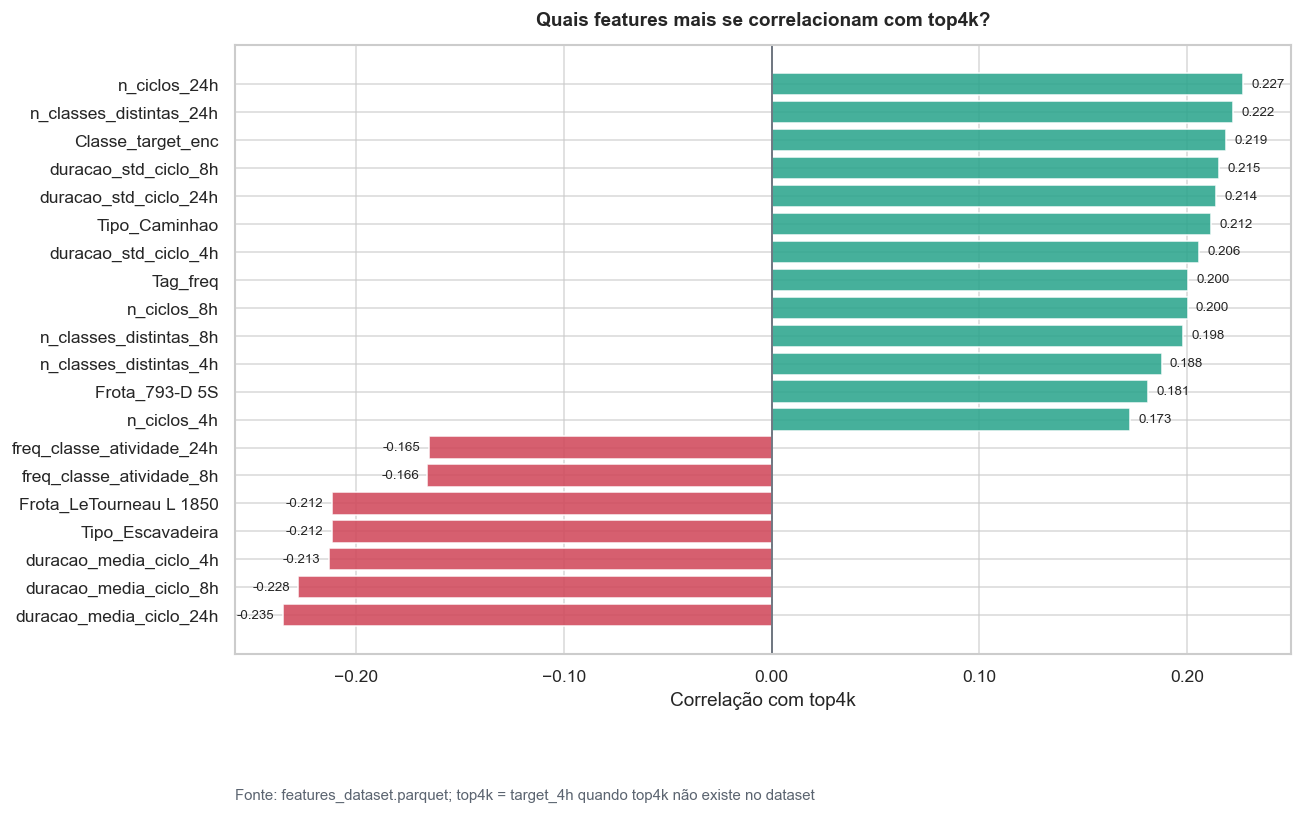

feature,correlacao,correlacao_abs
duracao_media_ciclo_24h,-0.2351,0.2351
duracao_media_ciclo_8h,-0.2277,0.2277
n_ciclos_24h,0.2268,0.2268
n_classes_distintas_24h,0.2220,0.2220
Classe_target_enc,0.2187,0.2187
duracao_std_ciclo_8h,0.2154,0.2154
duracao_std_ciclo_24h,0.2138,0.2138
duracao_media_ciclo_4h,-0.2129,0.2129
Tipo_Caminhao,0.2117,0.2117
Frota_LeTourneau L 1850,-0.2117,0.2117


**Leitura:** como `top4k` é binária, a correlação indica associação linear/ponto-bisserial; ela ajuda a priorizar investigação, mas não substitui importância do modelo nem valida causalidade.

In [14]:
# Correlação entre top4k e as features modeláveis.
top4k_col = "top4k" if "top4k" in features_df.columns else "target_4h"
if top4k_col == "target_4h":
    features_df["top4k"] = features_df["target_4h"].astype(float)
    top4k_col = "top4k"

corr_feature_cols = [
    col
    for col in feature_columns
    if col in features_df.columns
    and col != top4k_col
    and pd.api.types.is_numeric_dtype(features_df[col])
]

corr_input = features_df[[top4k_col] + corr_feature_cols].copy()
corr_input[top4k_col] = pd.to_numeric(corr_input[top4k_col], errors="coerce")

corr_series = (
    corr_input.corr(numeric_only=True)[top4k_col]
    .drop(labels=[top4k_col], errors="ignore")
    .dropna()
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

top_corr = corr_series.head(20).sort_values()
top_corr_df = (
    corr_series.head(20).rename("correlacao").reset_index().rename(columns={"index": "feature"})
)
top_corr_df["correlacao_abs"] = top_corr_df["correlacao"].abs()

fig, ax = plt.subplots(figsize=(11, 7))
bar_colors = [PALETTE["teal"] if value >= 0 else PALETTE["red"] for value in top_corr]
ax.barh(top_corr.index, top_corr.values, color=bar_colors, alpha=0.88)
ax.axvline(0, color=PALETTE["slate"], linewidth=1)
ax.set_title("Quais features mais se correlacionam com top4k?")
ax.set_xlabel("Correlação com top4k")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.2f}"))
for i, value in enumerate(top_corr.values):
    offset = 0.004 if value >= 0 else -0.004
    ha = "left" if value >= 0 else "right"
    ax.text(value + offset, i, f"{value:.3f}", va="center", ha=ha, fontsize=8)
add_source_note(
    ax, "Fonte: features_dataset.parquet; top4k = target_4h quando top4k não existe no dataset"
)
plt.tight_layout()
plt.show()

display(
    top_corr_df.style.hide(axis="index")
    .format({"correlacao": "{:.4f}", "correlacao_abs": "{:.4f}"})
    .set_caption("Top correlações entre top4k e features modeláveis")
)

display(
    Markdown(
        "**Leitura:** como `top4k` é binária, a correlação indica "
        "associação linear/ponto-bisserial; "
        "ela ajuda a priorizar investigação, mas não substitui importância "
        "do modelo nem valida causalidade."
    )
)

## 7. Treinamento, Validação e Seleção Robusta

A seleção oficial compara quatro famílias supervisionadas com Optuna, mesma base, mesmo split temporal e mesma métrica operacional. O teste temporal fica reservado para reporte final, não para escolher modelo.

**Regra oficial:** maior `val_top15_recall_at_k`; desempates por `val_top15_precision_at_k`, `val_top15_lift_vs_random` e `val_auc_pr`.


### 7.1 Validação Temporal, Tuning e Métricas Técnicas

A validação usa ordem temporal: treino acontece antes da validação, que acontece antes do teste. Um `k-fold` aleatório misturaria passado e futuro, permitindo que padrões posteriores contaminassem o treinamento e inflassem a performance. A seleção compara famílias supervisionadas distintas com Optuna/Bayesian search e calibra threshold na validação.


model_name,role,estimator,fit_seconds,val_precision,val_recall,val_f1,val_auc_pr,val_auc_roc,val_top15_precision_at_k,val_top15_recall_at_k,val_top15_lift_vs_random,test_precision,test_recall,test_f1,test_auc_pr,test_auc_roc,test_top15_precision_at_k,test_top15_recall_at_k,test_top15_lift_vs_random
lightgbm_optuna,official_candidate,LGBMClassifier,5.91s,0.214362,0.803333,0.338420,0.274987,0.746172,0.669048,0.757412,2.146002,0.270576,0.816254,0.406428,0.273717,0.742781,0.675556,0.736077,2.077374
hist_gbdt_optuna,official_candidate,HistGradientBoostingClassifier,13.74s,0.211874,0.810494,0.335931,0.268726,0.744629,0.666667,0.754717,2.138365,0.270116,0.809776,0.405103,0.273327,0.744515,0.673333,0.733656,2.070541
xgboost_optuna,official_candidate,XGBClassifier,7.57s,0.211262,0.808153,0.334960,0.235225,0.735822,0.666667,0.754717,2.138365,0.262780,0.792580,0.394697,0.268058,0.745814,0.682222,0.743341,2.097875
logistic_regression_baseline,diagnostic_baseline,Pipeline,1.73s,0.197510,0.801818,0.316947,0.234440,0.717787,0.623810,0.706199,2.000898,0.263718,0.677032,0.379581,0.244471,0.733187,0.673333,0.733656,2.070541


model_name,estimator,best_params
lightgbm_optuna,LGBMClassifier,"{""colsample_bytree"": 0.9070741220707436, ""learning_rate"": 0.015171635161998705, ""min_child_samples"": 32, ""n_estimators"": 865, ""num_leaves"": 30, ""reg_alpha"": 2.87931223783626, ""reg_lambda"": 1.9390013942636448, ""scale_pos_weight"": 3.804467853250999, ""subsample"": 0.7818060631603253}"
hist_gbdt_optuna,HistGradientBoostingClassifier,"{""class_weight"": ""balanced"", ""l2_regularization"": 4.390414054624046, ""learning_rate"": 0.03455215381938519, ""max_iter"": 583, ""max_leaf_nodes"": 31, ""min_samples_leaf"": 165}"
xgboost_optuna,XGBClassifier,"{""colsample_bytree"": 0.9684482051282947, ""learning_rate"": 0.022030860823037703, ""max_depth"": 8, ""min_child_weight"": 9.52646105697226, ""n_estimators"": 605, ""reg_alpha"": 1.7936999364332555, ""reg_lambda"": 5.680801652040023, ""scale_pos_weight"": 3.804467853250999, ""subsample"": 0.9818496824692567}"
logistic_regression_baseline,Pipeline,{}


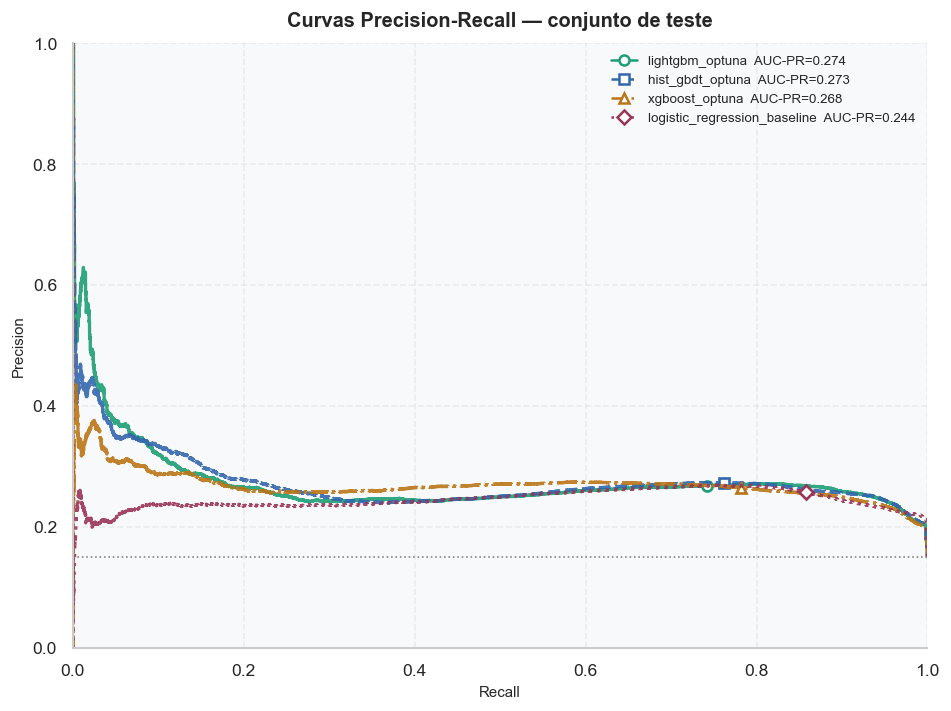

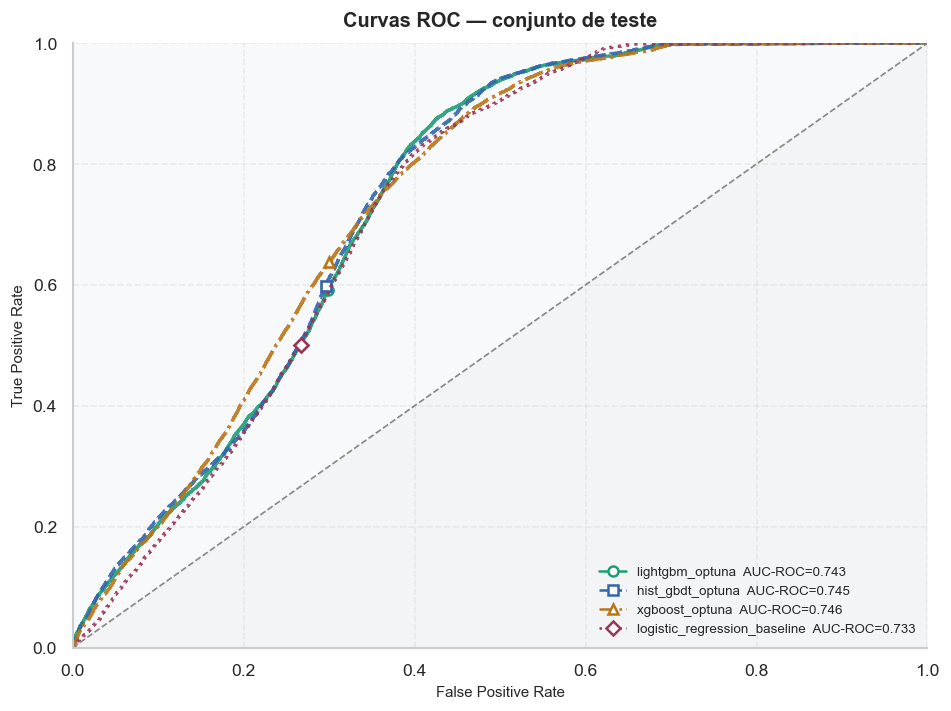

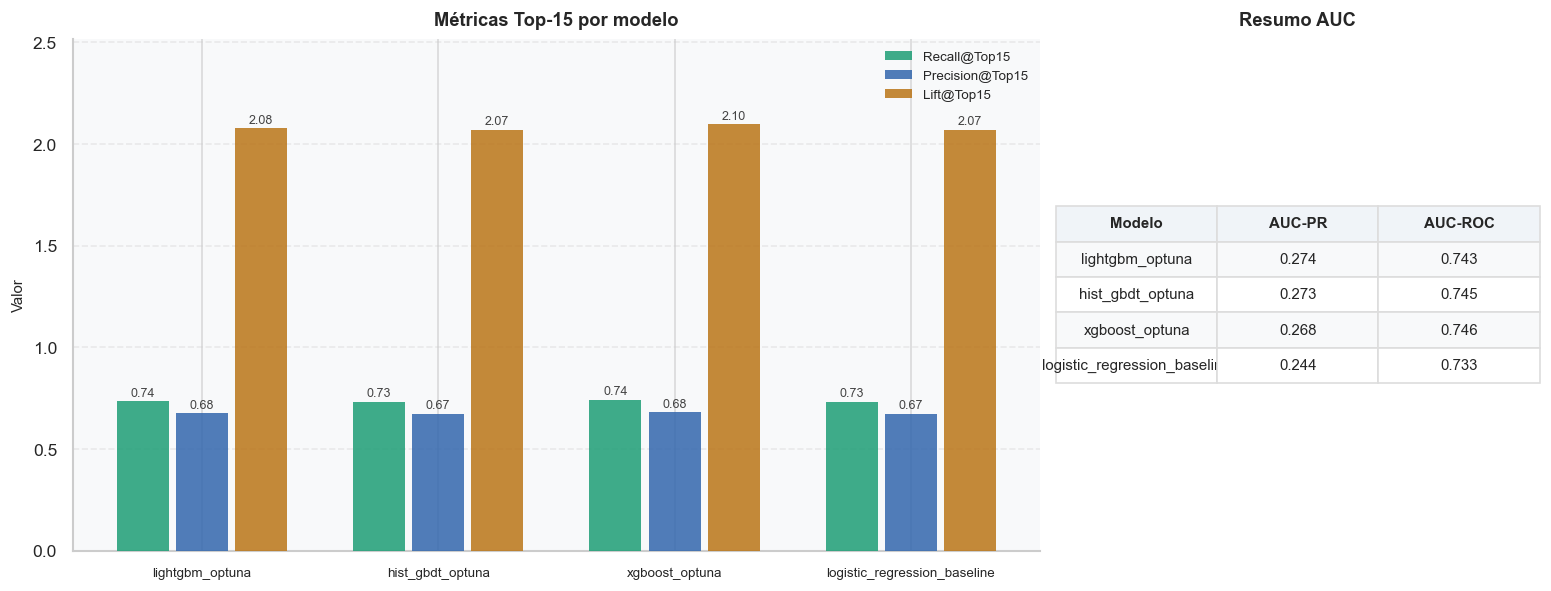

In [15]:
# ─── Paleta e estilos por modelo ─────────────────────────────────────
MODEL_STYLES = {
    # model_name → (cor, linestyle, marker)
    # populado dinamicamente abaixo; customize conforme seus nomes reais
}
COLOR_POOL = ["#1D9E75", "#3266ad", "#BA7517", "#993556", "#534AB7", "#0F6E56"]
LS_POOL = ["-", "--", "-.", ":", (0, (8, 2, 2, 2)), (0, (3, 1, 1, 1))]
MARKER_POOL = ["o", "s", "^", "D", "P", "X"]

PALETTE.update({"gray": "#888780", "bg": "#f8f9fa"})

plt.rcParams.update(
    {
        "font.size": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

# ─── Tabela comparativa ───────────────────────────────────────────────
metrics_cols = [
    "model_name",
    "role",
    "estimator",
    "fit_seconds",
    "val_precision",
    "val_recall",
    "val_f1",
    "val_auc_pr",
    "val_auc_roc",
    "val_top15_precision_at_k",
    "val_top15_recall_at_k",
    "val_top15_lift_vs_random",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_auc_pr",
    "test_auc_roc",
    "test_top15_precision_at_k",
    "test_top15_recall_at_k",
    "test_top15_lift_vs_random",
    "best_params",
]
metrics_table = selection_df[[c for c in metrics_cols if c in selection_df.columns]].copy()
num_cols = [c for c in metrics_table.select_dtypes(include="number").columns if c != "fit_seconds"]

display(
    metrics_table.drop(columns=["best_params"], errors="ignore")
    .style.hide(axis="index")
    .format({c: "{:.4f}" for c in num_cols})
    .format({"fit_seconds": "{:.2f}s"})
    .highlight_max(
        subset=[c for c in num_cols if "auc" in c or "recall" in c or "lift" in c], color="#E1F5EE"
    )
    .highlight_min(
        subset=[c for c in num_cols if "auc" in c or "recall" in c or "lift" in c], color="#FEF2F2"
    )
    .set_caption("Tabela comparativa completa — validação e teste temporal")
    .set_table_styles(table_style_rules)
)

# ─── Hiperparâmetros ──────────────────────────────────────────────────
params_table = metrics_table[["model_name", "estimator", "best_params"]].copy()
params_table["best_params"] = params_table["best_params"].fillna("baseline sem tuning Optuna")
display(
    params_table.style.hide(axis="index")
    .set_caption("Hiperparâmetros / tuning documentados por abordagem")
    .set_table_styles(table_style_rules)
)

# ─── Carrega scores e monta estilos ──────────────────────────────────
scores_for_curves = pd.read_parquet(REPORTS_MODEL_SELECTION / "model_selection_scores.parquet")
model_names = selection_df["model_name"].tolist()
curve_scores = scores_for_curves.query("split == 'test' and model_name in @model_names").copy()

for i, name in enumerate(model_names):
    MODEL_STYLES[name] = (
        COLOR_POOL[i % len(COLOR_POOL)],
        LS_POOL[i % len(LS_POOL)],
        MARKER_POOL[i % len(MARKER_POOL)],
    )

# ─── Figura 1: Precision-Recall ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
legend_handles = []

for model in model_names:
    ms = curve_scores.query("model_name == @model")
    if ms.empty:
        continue
    y_true = ms["target_4h"].astype(int)
    y_score = ms["score"].astype(float)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    area = auc(rec, prec)

    color, ls, marker = MODEL_STYLES[model]
    ax.plot(rec, prec, color=color, linestyle=ls, linewidth=2, alpha=0.9)

    # Marca ponto de operação atual (threshold padrão)
    idx = len(rec) // 2
    ax.plot(
        rec[idx],
        prec[idx],
        marker=marker,
        ms=6,
        color=color,
        markerfacecolor="#fff",
        markeredgewidth=1.6,
    )

    legend_handles.append(
        mlines.Line2D(
            [],
            [],
            color=color,
            linestyle=ls,
            marker=marker,
            markersize=6,
            markerfacecolor="#fff",
            markeredgewidth=1.5,
            label=f"{model}  AUC-PR={area:.3f}",
        )
    )

# Baseline proporcional
prevalence = curve_scores["target_4h"].mean()
ax.axhline(
    prevalence,
    color=PALETTE["gray"],
    linestyle=":",
    linewidth=1,
    label=f"baseline aleatório ({prevalence:.2%})",
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Recall", fontsize=9)
ax.set_ylabel("Precision", fontsize=9)
ax.set_title("Curvas Precision-Recall — conjunto de teste", fontsize=12, fontweight="bold", pad=10)
ax.set_facecolor(PALETTE["bg"])
ax.grid(linestyle="--", alpha=0.3)
ax.legend(handles=legend_handles, fontsize=8, loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()


# ─── Figura 2: ROC ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
legend_handles = []

for model in model_names:
    ms = curve_scores.query("model_name == @model")
    if ms.empty:
        continue
    y_true = ms["target_4h"].astype(int)
    y_score = ms["score"].astype(float)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    area = auc(fpr, tpr)

    color, ls, marker = MODEL_STYLES[model]
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2, alpha=0.9)
    ax.plot(
        fpr[len(fpr) // 2],
        tpr[len(tpr) // 2],
        marker=marker,
        ms=6,
        color=color,
        markerfacecolor="#fff",
        markeredgewidth=1.6,
    )

    legend_handles.append(
        mlines.Line2D(
            [],
            [],
            color=color,
            linestyle=ls,
            marker=marker,
            markersize=6,
            markerfacecolor="#fff",
            markeredgewidth=1.5,
            label=f"{model}  AUC-ROC={area:.3f}",
        )
    )

ax.plot(
    [0, 1],
    [0, 1],
    color=PALETTE["gray"],
    linestyle="--",
    linewidth=1,
    label="classificador aleatório",
)
ax.fill_between([0, 1], [0, 1], alpha=0.04, color=PALETTE["gray"])

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("False Positive Rate", fontsize=9)
ax.set_ylabel("True Positive Rate", fontsize=9)
ax.set_title("Curvas ROC — conjunto de teste", fontsize=12, fontweight="bold", pad=10)
ax.set_facecolor(PALETTE["bg"])
ax.grid(linestyle="--", alpha=0.3)
ax.legend(handles=legend_handles, fontsize=8, loc="lower right", framealpha=0.9)
plt.tight_layout()
plt.show()


# ─── Figura 3: Top-15 comparativo (barras agrupadas) ─────────────────
top15_metrics = [
    ("test_top15_recall_at_k", "Recall@Top15", COLOR_POOL[0]),
    ("test_top15_precision_at_k", "Precision@Top15", COLOR_POOL[1]),
    ("test_top15_lift_vs_random", "Lift@Top15", COLOR_POOL[2]),
]
n_models = len(model_names)
n_metrics = len(top15_metrics)
x = range(n_models)
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [2, 1]})

# Barras agrupadas
ax = axes[0]
for i, (col, label, color) in enumerate(top15_metrics):
    vals = metrics_table.set_index("model_name").loc[model_names, col].values
    offset = (i - 1) * width
    bars = ax.bar(
        [xi + offset for xi in x],
        vals,
        width=width - 0.03,
        color=color,
        alpha=0.85,
        label=label,
        edgecolor="none",
        zorder=3,
    )
    for bar, v in zip(bars, vals, strict=False):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{v:.2f}",
            ha="center",
            va="bottom",
            fontsize=7.5,
            color="#444",
        )

ax.set_xticks(list(x))
ax.set_xticklabels([m.replace(" ", "\n") for m in model_names], fontsize=8)
ax.set_ylim(
    0, max(metrics_table[top15_metrics[2][0]].max(), metrics_table[top15_metrics[0][0]].max()) * 1.2
)
ax.set_title("Métricas Top-15 por modelo", fontsize=11, fontweight="bold", pad=8)
ax.set_ylabel("Valor", fontsize=9)
ax.set_facecolor(PALETTE["bg"])
ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
ax.legend(fontsize=8, framealpha=0.9)

# Tabela resumo compacta (AUC-PR vs AUC-ROC)
ax2 = axes[1]
ax2.axis("off")
tbl_data = [
    [
        m,
        f"{metrics_table.set_index('model_name').loc[m, 'test_auc_pr']:.3f}",
        f"{metrics_table.set_index('model_name').loc[m, 'test_auc_roc']:.3f}",
    ]
    for m in model_names
]
tbl = ax2.table(
    cellText=tbl_data,
    colLabels=["Modelo", "AUC-PR", "AUC-ROC"],
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
for (r, _col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#ddd")
    if r == 0:
        cell.set_facecolor("#f0f4f8")
        cell.set_text_props(fontweight="bold")
    else:
        cell.set_facecolor("#fff" if r % 2 == 0 else "#f8f9fa")
ax2.set_title("Resumo AUC", fontsize=11, fontweight="bold", pad=8)

plt.tight_layout()
plt.show()

## 8. Diagnóstico Técnico Ciclo-a-Ciclo

O modelo gera um score de risco entre 0 e 1. O threshold oficial é calibrado na validação e usado para diagnóstico técnico ciclo-a-ciclo. A decisão operacional principal continua sendo o ranking **Top15 Tag-dia**.

A matriz de confusão desta seção deve ser lida com cuidado: os **falsos positivos** representam ciclos que passaram do threshold, mas não tiveram alerta crítico na janela de 4 horas. Isso mostra que o threshold é sensível e gera volume alto de alarmes se usado sozinho.

Por isso, o projeto não recomenda acionar manutenção para todos os ciclos acima do threshold. O uso principal é ordenar as `Tags` por score e selecionar apenas o **Top15 Tag-dia**, que controla o volume de inspeções e melhora a precisão operacional.


/var/folders/0q/hw9t6jv16lq6_3f63snxhlrm0000gn/T/ipykernel_21574/2905362169.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


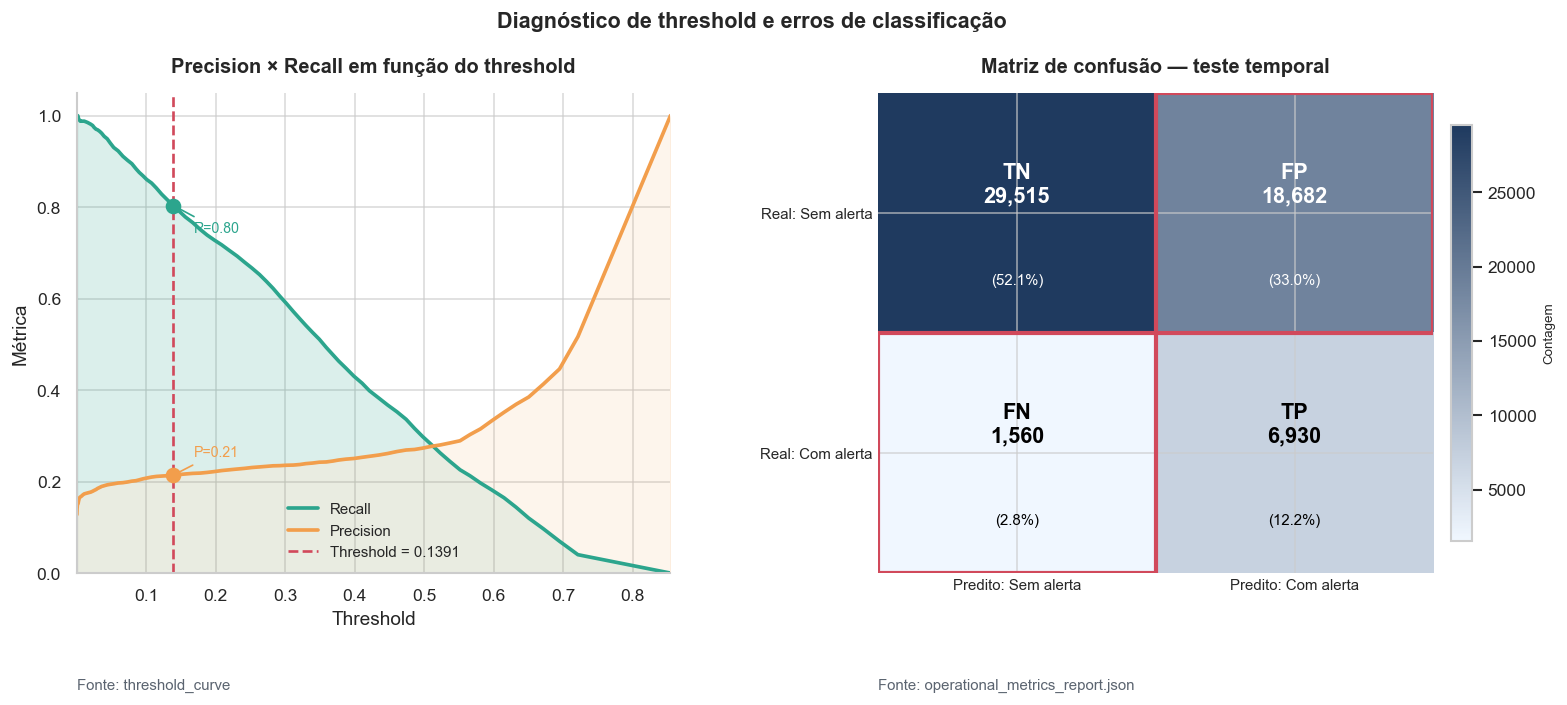

Split,Threshold,Precision,Recall,Preditos positivos,% predito positivo
Teste,0.139074,0.2706,0.8163,25.612,45.2%


**Insight operacional:** o threshold `0.139074` mantém recall técnico alto (`0.816`), mas o volume ciclo-a-ciclo é grande; por isso a rotina de campo deve usar Top15 Tag-dia.

In [16]:
curve = threshold_curve_df.copy()
closest_idx = (curve["threshold"] - threshold).abs().idxmin()
selected_threshold_row = curve.loc[closest_idx]

rows = int(threshold_test["rows"])
tp = int(threshold_test["true_positive"])
fp = int(threshold_test["false_positive"])
fn = int(threshold_test["false_negative"])
tn = rows - tp - fp - fn
cm = np.array([[tn, fp], [fn, tp]])

# ── Layout ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 5.2))
gs = fig.add_gridspec(1, 2, wspace=0.35)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])

# ── Painel 1 · Precision / Recall vs Threshold ───────────────────────────────
ax0.fill_between(curve["threshold"], curve["recall"], alpha=0.10, color=PALETTE["teal"])
ax0.fill_between(curve["threshold"], curve["precision"], alpha=0.10, color=PALETTE["orange"])
ax0.plot(curve["threshold"], curve["recall"], label="Recall", color=PALETTE["teal"], linewidth=2.2)
ax0.plot(
    curve["threshold"],
    curve["precision"],
    label="Precision",
    color=PALETTE["orange"],
    linewidth=2.2,
)

# Área entre as curvas destacando o trade-off
ax0.fill_between(
    curve["threshold"],
    curve["recall"],
    curve["precision"],
    where=curve["recall"] >= curve["precision"],
    alpha=0.07,
    color=PALETTE["teal"],
    label="_nolegend_",
)

# Linha e anotação do threshold oficial
ax0.axvline(
    threshold,
    color=PALETTE["red"],
    linestyle="--",
    linewidth=1.6,
    label=f"Threshold = {threshold:.4f}",
)
recall_at_thr = float(selected_threshold_row["recall"])
precision_at_thr = float(selected_threshold_row["precision"])

ax0.scatter([threshold], [recall_at_thr], color=PALETTE["teal"], s=70, zorder=5)
ax0.scatter([threshold], [precision_at_thr], color=PALETTE["orange"], s=70, zorder=5)

ax0.annotate(
    f"R={recall_at_thr:.2f}",
    xy=(threshold, recall_at_thr),
    xytext=(threshold + 0.03, recall_at_thr - 0.06),
    fontsize=8.5,
    color=PALETTE["teal"],
    arrowprops=dict(arrowstyle="-", color=PALETTE["teal"], lw=1),
)
ax0.annotate(
    f"P={precision_at_thr:.2f}",
    xy=(threshold, precision_at_thr),
    xytext=(threshold + 0.03, precision_at_thr + 0.04),
    fontsize=8.5,
    color=PALETTE["orange"],
    arrowprops=dict(arrowstyle="-", color=PALETTE["orange"], lw=1),
)

ax0.set_title("Precision × Recall em função do threshold", fontsize=12, fontweight="bold")
ax0.set_xlabel("Threshold")
ax0.set_ylabel("Métrica")
ax0.set_ylim(0, 1.05)
ax0.set_xlim(curve["threshold"].min(), curve["threshold"].max())
ax0.spines[["top", "right"]].set_visible(False)
ax0.legend(fontsize=9, framealpha=0.4)
add_source_note(ax0, "Fonte: threshold_curve")

# ── Painel 2 · Matriz de confusão com degradê e anotações enriquecidas ───────
labels = np.array([["TN", "FP"], ["FN", "TP"]])
total = cm.sum()
cm_share = cm / total

# Degradê azul com células FN/FP destacadas em outra cor
custom_cmap = mcolors.LinearSegmentedColormap.from_list("cm_grad", ["#f0f7ff", PALETTE["navy"]])
im = ax1.imshow(cm, cmap=custom_cmap, aspect="auto")

# Borda vermelha nas células de erro (FP e FN)
for (r, c), val in np.ndenumerate(cm):
    color_text = "white" if cm[r, c] > cm.max() / 2 else "black"
    is_error = (r == 0 and c == 1) or (r == 1 and c == 0)  # FP ou FN
    border_col = PALETTE["red"] if is_error else "none"

    ax1.add_patch(
        plt.Rectangle(
            (c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor=border_col, linewidth=2.5, zorder=3
        )
    )
    ax1.text(
        c,
        r - 0.12,
        f"{labels[r, c]}\n{val:,}",
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=color_text,
        zorder=4,
    )
    ax1.text(
        c,
        r + 0.28,
        f"({cm_share[r, c]:.1%})",
        ha="center",
        va="center",
        fontsize=9,
        color=color_text,
        zorder=4,
    )

ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(["Predito: Sem alerta", "Predito: Com alerta"], fontsize=9)
ax1.set_yticklabels(["Real: Sem alerta", "Real: Com alerta"], fontsize=9, rotation=0)
ax1.set_title("Matriz de confusão — teste temporal", fontsize=12, fontweight="bold")
ax1.tick_params(length=0)
for spine in ax1.spines.values():
    spine.set_visible(False)

fig.colorbar(im, ax=ax1, fraction=0.035, pad=0.03).set_label("Contagem", fontsize=8)
add_source_note(ax1, "Fonte: operational_metrics_report.json")

plt.suptitle(
    "Diagnóstico de threshold e erros de classificação", fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

# ── Tabela resumo ─────────────────────────────────────────────────────────────
threshold_table = pd.DataFrame(
    [
        {
            "Split": "Teste",
            "Threshold": threshold,
            "Precision": threshold_test["precision"],
            "Recall": threshold_test["recall"],
            "Preditos positivos": threshold_test["predicted_positive"],
            "% predito positivo": threshold_test["predicted_positive_rate"],
        }
    ]
)
display(
    threshold_table.style.hide(axis="index")
    .format(
        {
            "Threshold": "{:.6f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "Preditos positivos": lambda v: fmt_int(v),
            "% predito positivo": "{:.1%}",
        }
    )
    .set_caption("Diagnóstico técnico ciclo-a-ciclo")
)

display(
    Markdown(
        f"**Insight operacional:** o threshold `{threshold:.6f}` mantém recall técnico alto "
        f"(`{threshold_test['recall']:.3f}`), mas o volume ciclo-a-ciclo é grande; "
        f"por isso a rotina de campo deve usar Top15 Tag-dia."
    )
)

### 8.1 Análise de Erros e Degradação Temporal

A matriz de confusão mostra o comportamento ciclo-a-ciclo no threshold técnico. Para traduzir erro em operação, esta célula explicita falsos negativos por equipamento/segmento e usa backtesting temporal como evidência de estabilidade/degradação.


Tag,Frota,Tipo,Classe,falsos_negativos
CA65921,793-D 4S,Caminhao,Operando,285
CA65921,793-D 4S,Caminhao,Parado,138
CA65937,793-D 5S,Caminhao,Operando,135
CA65937,793-D 5S,Caminhao,Parado,81
CA65793,793-D 2S,Caminhao,Operando,77
CA5926,793-D 5S,Caminhao,Operando,76
CA65789,793-D 2S,Caminhao,Operando,74
CA65790,793-D 2S,Caminhao,Operando,68
CA65915,793-D 4S,Caminhao,Operando,67
CA65909,793-D 3S,Caminhao,Operando,57


Erro,Qtd,Impacto operacional
Falso negativo,1.560,Alerta crítico não antecipado — maior risco de parada não planejada
Falso positivo,18.682,Inspeção possivelmente desnecessária — consome capacidade de manutenção


fold,train_end,test_start,test_end,test_precision,test_recall,test_f1,test_auc_pr,test_auc_roc,test_top15_precision_at_k,test_top15_recall_at_k,test_top15_lift_vs_random
1,2025-03-31 19:00:00+00:00,2025-04-18 19:00:00+00:00,2025-05-06 06:00:00+00:00,0.2936,0.8547,0.4370,0.3235,0.7676,0.6877,0.7538,2.1769
2,2025-04-27 06:00:00+00:00,2025-05-15 14:50:08+00:00,2025-06-02 15:00:00+00:00,0.1939,0.7625,0.3092,0.2029,0.7231,0.6281,0.7306,2.0585
3,2025-05-24 08:00:00+00:00,2025-06-12 09:00:00+00:00,2025-07-01 03:00:00+00:00,0.2506,0.8191,0.3838,0.2588,0.7499,0.6600,0.7174,2.0326


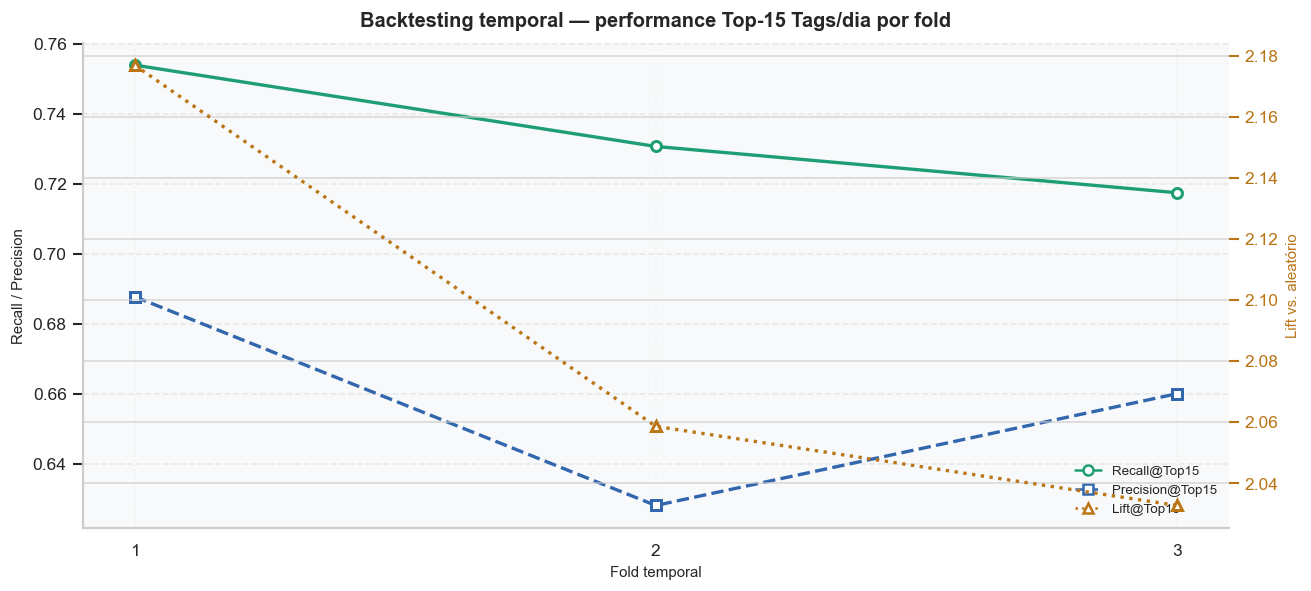

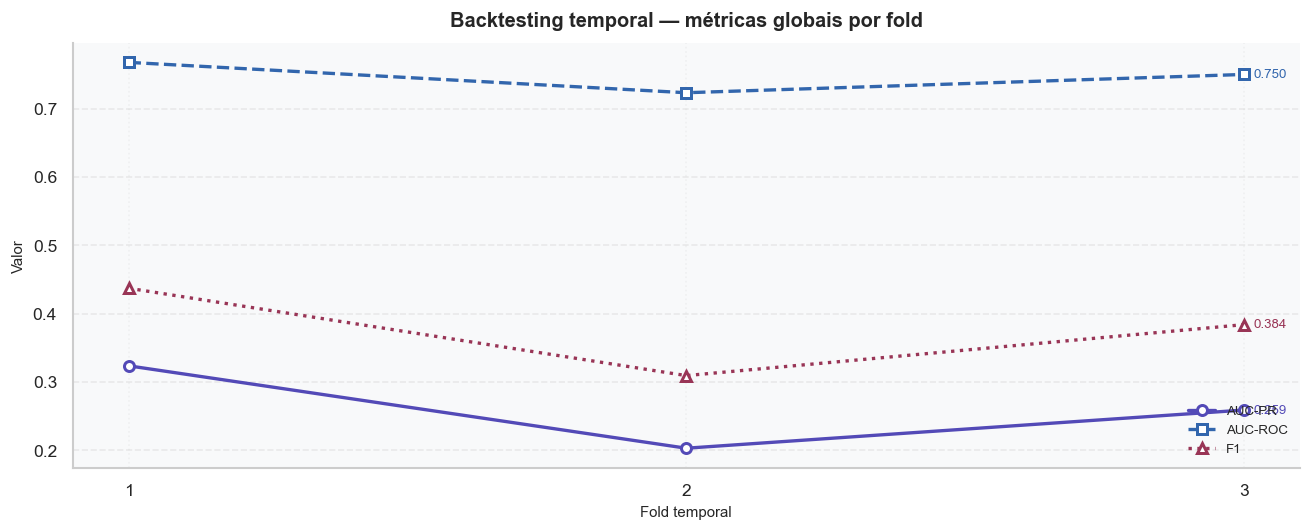

**Leitura:** falso negativo tem custo operacional maior que falso positivo; por isso o ponto de operação prioriza recall e controla volume via Top 15 Tag-dia. Quedas consistentes entre folds indicariam drift e acionariam retreino ou monitoramento dedicado.

In [17]:
# ─── Carrega e prepara scores ────────────────────────────────────────
selected_scores = (
    pd.read_parquet(REPORTS_MODEL_SELECTION / "model_selection_scores.parquet")
    .query("model_name == @model_name and split == 'test'")
    .copy()
)
selected_scores["Fim"] = pd.to_datetime(selected_scores["Fim"], errors="coerce", utc=True)

false_negatives = selected_scores.query("target_4h == 1 and prediction == 0").copy()
false_positives = selected_scores.query("target_4h == 0 and prediction == 1").copy()


# ─── Tabelas ─────────────────────────────────────────────────────────
fn_by_tag = (
    false_negatives.groupby(["Tag", "Frota", "Tipo", "Classe"], dropna=False)
    .size()
    .reset_index(name="falsos_negativos")
    .sort_values("falsos_negativos", ascending=False)
    .head(12)
)

display(
    fn_by_tag.style.hide(axis="index")
    .bar(subset=["falsos_negativos"], color="#E24B4A44", vmin=0)
    .set_caption("Falsos negativos mais críticos por Tag / Frota / Tipo / Classe")
    .set_table_styles(table_style_rules)
)

error_mix = pd.DataFrame(
    [
        {
            "Erro": "Falso negativo",
            "Qtd": len(false_negatives),
            "Impacto operacional": (
                "Alerta crítico não antecipado — maior risco de parada não planejada"
            ),
        },
        {
            "Erro": "Falso positivo",
            "Qtd": len(false_positives),
            "Impacto operacional": (
                "Inspeção possivelmente desnecessária — consome capacidade de manutenção"
            ),
        },
    ]
)
display(
    error_mix.style.hide(axis="index")
    .format({"Qtd": fmt_int})
    .set_caption("Custo assimétrico dos erros")
    .set_table_styles(table_style_rules)
)


# ─── Prepara backtest ─────────────────────────────────────────────────
backtest_cols_num = [c for c in backtest_df.select_dtypes(include="number").columns if c != "fold"]
backtest_view = backtest_df[
    [
        "fold",
        "train_end",
        "test_start",
        "test_end",
        "test_precision",
        "test_recall",
        "test_f1",
        "test_auc_pr",
        "test_auc_roc",
        "test_top15_precision_at_k",
        "test_top15_recall_at_k",
        "test_top15_lift_vs_random",
    ]
].copy()

display(
    backtest_view.style.hide(axis="index")
    .format({col: "{:.4f}" for col in backtest_cols_num})
    .bar(subset=["test_top15_recall_at_k"], color="#1D9E7544", vmin=0)
    .bar(subset=["test_top15_lift_vs_random"], color="#3266ad44", vmin=0)
    .set_caption("Backtesting temporal — estabilidade e possível drift")
    .set_table_styles(table_style_rules)
)


# ─── Paleta e estilo ──────────────────────────────────────────────────
PALETTE.update(
    {
        "teal": "#1D9E75",
        "blue": "#3266ad",
        "amber": "#BA7517",
        "purple": "#534AB7",
        "pink": "#993556",
        "gray": "#888780",
        "bg": "#f8f9fa",
    }
)
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False})

folds = backtest_view["fold"].values


# ─── Figura 1: Top-15 — recall, precision, lift ───────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

metrics_top15 = [
    ("test_top15_recall_at_k", "Recall@Top15", PALETTE["teal"], "-", "o"),
    ("test_top15_precision_at_k", "Precision@Top15", PALETTE["blue"], "--", "s"),
    ("test_top15_lift_vs_random", "Lift@Top15", PALETTE["amber"], ":", "^"),
]

ax2 = ax.twinx()  # eixo secundário para o Lift (escala diferente)

for col, label, color, ls, marker in metrics_top15:
    vals = backtest_view[col].values
    target_ax = ax2 if col == "test_top15_lift_vs_random" else ax
    target_ax.plot(
        folds,
        vals,
        color=color,
        linestyle=ls,
        marker=marker,
        markersize=6,
        linewidth=2,
        markerfacecolor="#fff",
        markeredgewidth=1.8,
        label=label,
    )

ax.set_xlabel("Fold temporal", fontsize=9)
ax.set_ylabel("Recall / Precision", fontsize=9)
ax2.set_ylabel("Lift vs. aleatório", fontsize=9, color=PALETTE["amber"])
ax2.tick_params(axis="y", colors=PALETTE["amber"])
ax.set_facecolor(PALETTE["bg"])
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", linestyle=":", alpha=0.2)
ax.set_title(
    "Backtesting temporal — performance Top-15 Tags/dia por fold",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
ax.set_xticks(folds)

# Legenda unificada
handles = [
    mlines.Line2D(
        [],
        [],
        color=c,
        linestyle=ls,
        marker=m,
        markersize=6,
        markerfacecolor="#fff",
        markeredgewidth=1.5,
        label=lbl,
    )
    for _, lbl, c, ls, m in metrics_top15
]
ax.legend(handles=handles, fontsize=8, loc="lower right", framealpha=0.9)

plt.tight_layout()
plt.show()


# ─── Figura 2: métricas globais — AUC-PR, AUC-ROC, F1 ───────────────
fig, ax = plt.subplots(figsize=(11, 4.5))

metrics_global = [
    ("test_auc_pr", "AUC-PR", PALETTE["purple"], "-", "o"),
    ("test_auc_roc", "AUC-ROC", PALETTE["blue"], "--", "s"),
    ("test_f1", "F1", PALETTE["pink"], ":", "^"),
]

for col, label, color, ls, marker in metrics_global:
    vals = backtest_view[col].values
    ax.plot(
        folds,
        vals,
        color=color,
        linestyle=ls,
        marker=marker,
        markersize=6,
        linewidth=2,
        markerfacecolor="#fff",
        markeredgewidth=1.8,
        label=label,
    )
    # Anota último ponto
    ax.annotate(
        f"{vals[-1]:.3f}",
        xy=(folds[-1], vals[-1]),
        xytext=(6, 0),
        textcoords="offset points",
        fontsize=8,
        color=color,
        va="center",
    )

ax.set_xlabel("Fold temporal", fontsize=9)
ax.set_ylabel("Valor", fontsize=9)
ax.set_title(
    "Backtesting temporal — métricas globais por fold", fontsize=12, fontweight="bold", pad=10
)
ax.set_facecolor(PALETTE["bg"])
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", linestyle=":", alpha=0.2)
ax.set_xticks(folds)
ax.legend(fontsize=8, loc="lower right", framealpha=0.9)

plt.tight_layout()
plt.show()


# ─── Nota de leitura ─────────────────────────────────────────────────
display(
    Markdown(
        "**Leitura:** falso negativo tem custo operacional maior que falso positivo; "
        "por isso o ponto de operação prioriza recall e controla volume via Top 15 Tag-dia. "
        "Quedas consistentes entre folds indicariam drift e acionariam "
        "retreino ou monitoramento dedicado."
    )
)

### 8.2 Interpretabilidade com Contribuições do LightGBM

Para o LightGBM selecionado, as contribuições no estilo SHAP podem ser obtidas diretamente via `pred_contrib=True`, sem depender do pacote externo `shap`. O primeiro gráfico resume a importância média absoluta das contribuições; o segundo mostra a direção das contribuições para uma amostra; o terceiro decompõe uma predição individual de alto risco.


feature,mean_abs_shap
dias_desde_ultimo_alerta,1.2614
Tag_freq,1.0625
Frota_LeTourneau L 1850,0.9546
freq_classe_atividade_24h,0.1929
duracao_media_ciclo_8h,0.1721
Classe_target_enc,0.1165
Frota_793-D 2S,0.1035
duracao_std_ciclo_24h,0.1021
Frota_793-D 5S,0.0950
n_ciclos_24h,0.0910


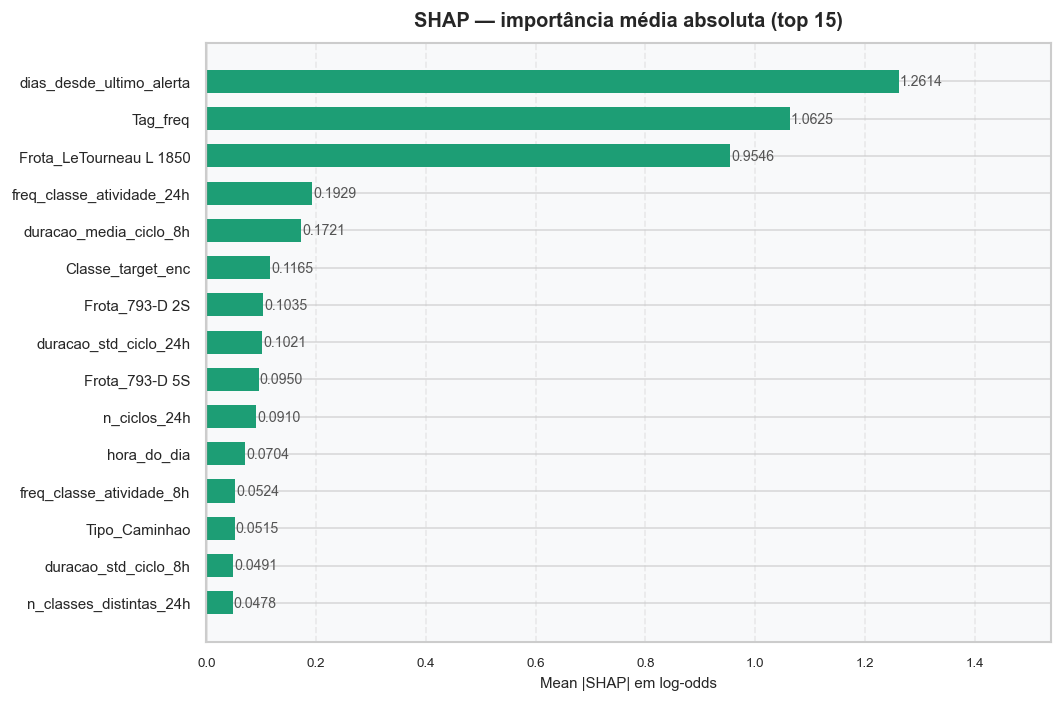

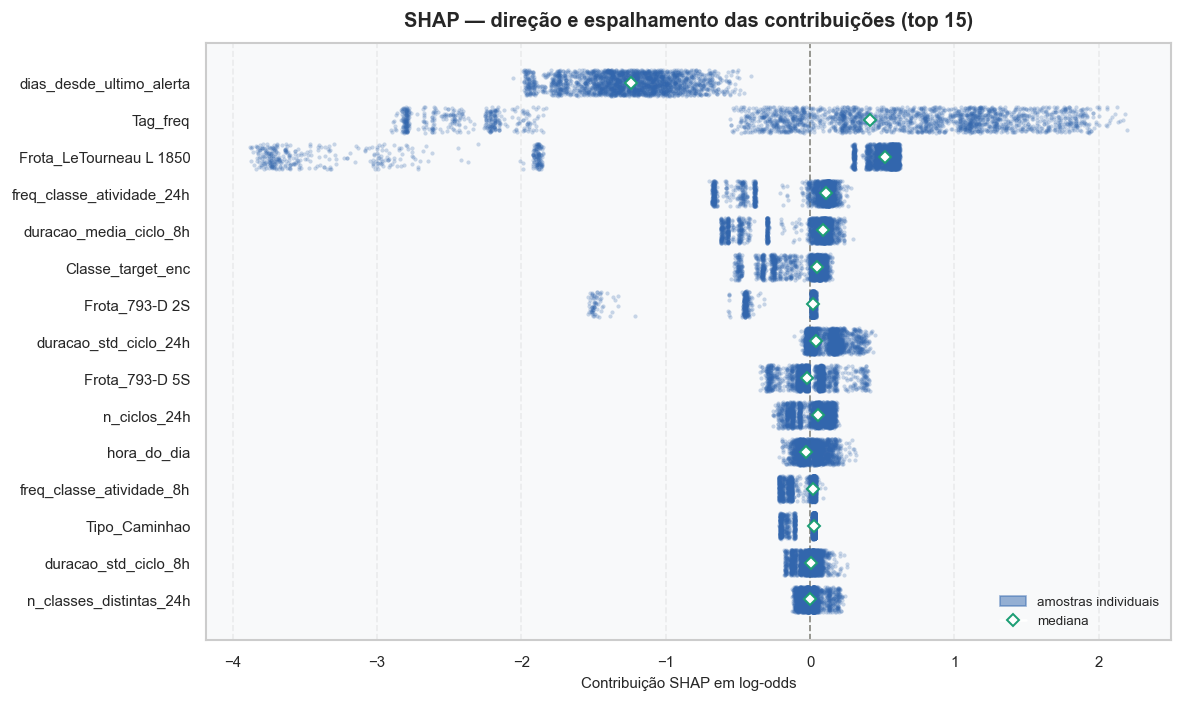

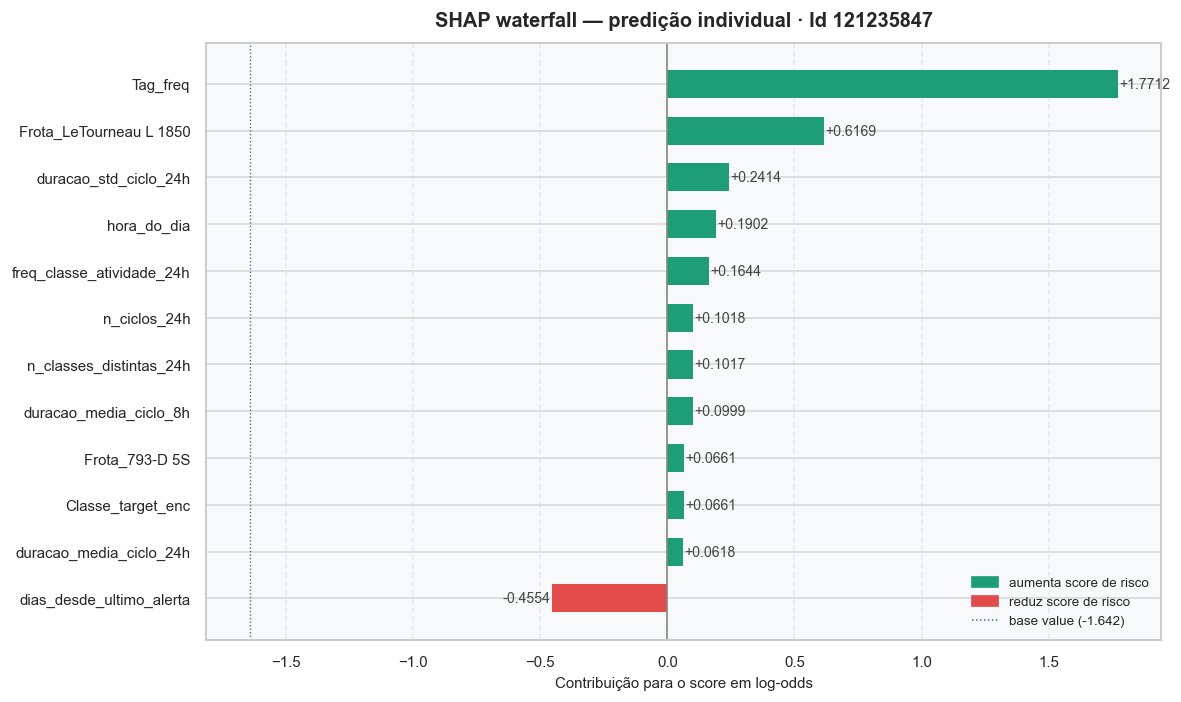

**Validação de sentido operacional:** as contribuições mais fortes devem ser revisadas com o time de campo. Sinais de recência, histórico de alertas em janelas curtas e padrões de turno/frota fazem sentido; qualquer feature sem explicação operacional clara deve ser investigada antes de automatizar qualquer decisão.

In [18]:
# ─── Paleta consistente ─────────────────────────────────────────────
PALETTE.update(
    {
        "teal": "#1D9E75",
        "blue": "#3266ad",
        "red": "#E24B4A",
        "gray": "#888780",
        "bg": "#f8f9fa",
    }
)

sns.set_theme(style="whitegrid", font_scale=0.95)

# ─── Carrega modelo e computa SHAP ──────────────────────────────────
bundle = joblib.load(MODELS / "model_selected.joblib")
explain_model = bundle["model"]
explain_features = bundle["feature_columns"]

X_explain = split_test_df[explain_features].sample(n=min(2500, len(split_test_df)), random_state=42)

shap_matrix = explain_model.predict(X_explain, pred_contrib=True)
shap_values = pd.DataFrame(shap_matrix[:, :-1], columns=explain_features, index=X_explain.index)
base_value = shap_matrix[:, -1].mean()

shap_importance = (
    shap_values.abs()
    .mean()
    .sort_values(ascending=False)
    .rename("mean_abs_shap")
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(
    shap_importance.head(20)
    .style.hide(axis="index")
    .format({"mean_abs_shap": "{:.4f}"})
    .bar(subset=["mean_abs_shap"], color="#1D9E7544", vmin=0)
    .set_caption("Ranking de importância SHAP — teste temporal")
    .set_table_styles(TABLE_STYLE_RULES)
)


# ─── Figura 1: Importância SHAP (barras horizontais) ────────────────
top_shap = shap_importance.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    top_shap["feature"][::-1],
    top_shap["mean_abs_shap"][::-1],
    color=PALETTE["teal"],
    height=0.62,
    edgecolor="none",
)

for bar, val in zip(bars, top_shap["mean_abs_shap"][::-1], strict=False):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        ha="left",
        fontsize=8.5,
        color="#555",
    )

ax.set_title("SHAP — importância média absoluta (top 15)", fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Mean |SHAP| em log-odds", fontsize=9)
ax.set_xlim(0, top_shap["mean_abs_shap"].max() * 1.22)
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=8)
ax.set_facecolor(PALETTE["bg"])
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.axvline(0, color=PALETTE["gray"], linewidth=0.8)
plt.tight_layout()
plt.show()


# ─── Figura 2: Distribuição das contribuições (strip / beeswarm) ────
top_cols = top_shap["feature"].tolist()
summary_long = shap_values[top_cols].melt(var_name="feature", value_name="shap_value")

fig, ax = plt.subplots(figsize=(10, 6))
sns.stripplot(
    data=summary_long,
    y="feature",
    x="shap_value",
    ax=ax,
    size=2.5,
    alpha=0.25,
    color=PALETTE["blue"],
    order=top_cols,  # mesma ordem do ranking
    jitter=0.35,
)
ax.axvline(0, color=PALETTE["gray"], linestyle="--", linewidth=1)

# Anota mediana de cada feature
for i, feat in enumerate(top_cols):
    med = shap_values[feat].median()
    ax.plot(
        med,
        i,
        "D",
        ms=5,
        color="#fff",
        markeredgecolor=PALETTE["teal"],
        markeredgewidth=1.2,
        zorder=5,
    )

ax.set_title(
    "SHAP — direção e espalhamento das contribuições (top 15)",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
ax.set_xlabel("Contribuição SHAP em log-odds", fontsize=9)
ax.set_ylabel("")
ax.tick_params(labelsize=9)
ax.set_facecolor(PALETTE["bg"])
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(
    handles=[
        mpatches.Patch(color=PALETTE["blue"], alpha=0.5, label="amostras individuais"),
        plt.Line2D(
            [0],
            [0],
            marker="D",
            color="w",
            markerfacecolor="w",
            markeredgecolor=PALETTE["teal"],
            markeredgewidth=1.2,
            markersize=5,
            label="mediana",
        ),
    ],
    fontsize=8,
    loc="lower right",
    framealpha=0.9,
)
plt.tight_layout()
plt.show()


# ─── Figura 3: Waterfall individual ─────────────────────────────────
scored_test = selected_scores.set_index("Id")
high_risk_id = selected_scores.sort_values("score", ascending=False).iloc[0]["Id"]

row_idx = split_test_df.index[split_test_df["Id"].eq(high_risk_id)]
row_idx = [row_idx[0]] if len(row_idx) > 0 else [X_explain.index[0]]

X_one = split_test_df.loc[row_idx, explain_features]
one_contrib = explain_model.predict(X_one, pred_contrib=True)[0]

waterfall = (
    pd.DataFrame({"feature": explain_features, "contribuicao": one_contrib[:-1]})
    .assign(abs_contrib=lambda df: df["contribuicao"].abs())
    .sort_values("abs_contrib", ascending=False)
    .head(12)
    .sort_values("contribuicao")  # crescente → negativas embaixo
)

colors = [PALETTE["red"] if v < 0 else PALETTE["teal"] for v in waterfall["contribuicao"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    waterfall["feature"],
    waterfall["contribuicao"],
    color=colors,
    height=0.6,
    edgecolor="none",
)

for bar, v in zip(bars, waterfall["contribuicao"], strict=False):
    xpos = bar.get_width() + (0.005 if v >= 0 else -0.005)
    ha = "left" if v >= 0 else "right"
    ax.text(
        xpos,
        bar.get_y() + bar.get_height() / 2,
        f"{v:+.4f}",
        va="center",
        ha=ha,
        fontsize=8.5,
        color="#444",
    )

ax.axvline(0, color=PALETTE["gray"], linewidth=1)

# Base value como referência
ax.axvline(
    base_value,
    color=PALETTE["blue"],
    linewidth=0.8,
    linestyle=":",
    label=f"base value ({base_value:.3f})",
)

ax.set_title(
    f"SHAP waterfall — predição individual · Id {int(high_risk_id)}",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
ax.set_xlabel("Contribuição para o score em log-odds", fontsize=9)
ax.set_ylabel("")
ax.tick_params(labelsize=9)
ax.set_facecolor(PALETTE["bg"])
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(
    handles=[
        mpatches.Patch(color=PALETTE["teal"], label="aumenta score de risco"),
        mpatches.Patch(color=PALETTE["red"], label="reduz score de risco"),
        plt.Line2D(
            [0],
            [0],
            color=PALETTE["blue"],
            linestyle=":",
            linewidth=0.9,
            label=f"base value ({base_value:.3f})",
        ),
    ],
    fontsize=8,
    loc="lower right",
    framealpha=0.9,
)
plt.tight_layout()
plt.show()


# ─── Nota de validação operacional ──────────────────────────────────
display(
    Markdown(
        "**Validação de sentido operacional:** as contribuições mais fortes devem ser "
        "revisadas com o time de campo. Sinais de recência, histórico de alertas em janelas "
        "curtas e padrões de turno/frota fazem sentido; qualquer feature sem explicação "
        "operacional clara deve ser investigada antes de automatizar qualquer decisão."
    )
)

## 9. Resultado Operacional: Top15 Tag-dia

Esta é a avaliação central do projeto. Para cada dia, o modelo ordena as `Tags` por risco e mede a qualidade dos primeiros equipamentos da lista.

Top15 traduz o modelo em capacidade operacional: uma lista curta, diária e auditável para inspeção preventiva.



────────────────────────────────────────────────────
  RESULTADO OPERACIONAL — TESTE TEMPORAL
────────────────────────────────────────────────────
  Precision@15 : 0.676
  Recall@15    : 0.736
  Lift@15      : 2.08×  vs aleatório
  Capturados   : 304 de 413 positivos
────────────────────────────────────────────────────



/var/folders/0q/hw9t6jv16lq6_3f63snxhlrm0000gn/T/ipykernel_21574/1804271149.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


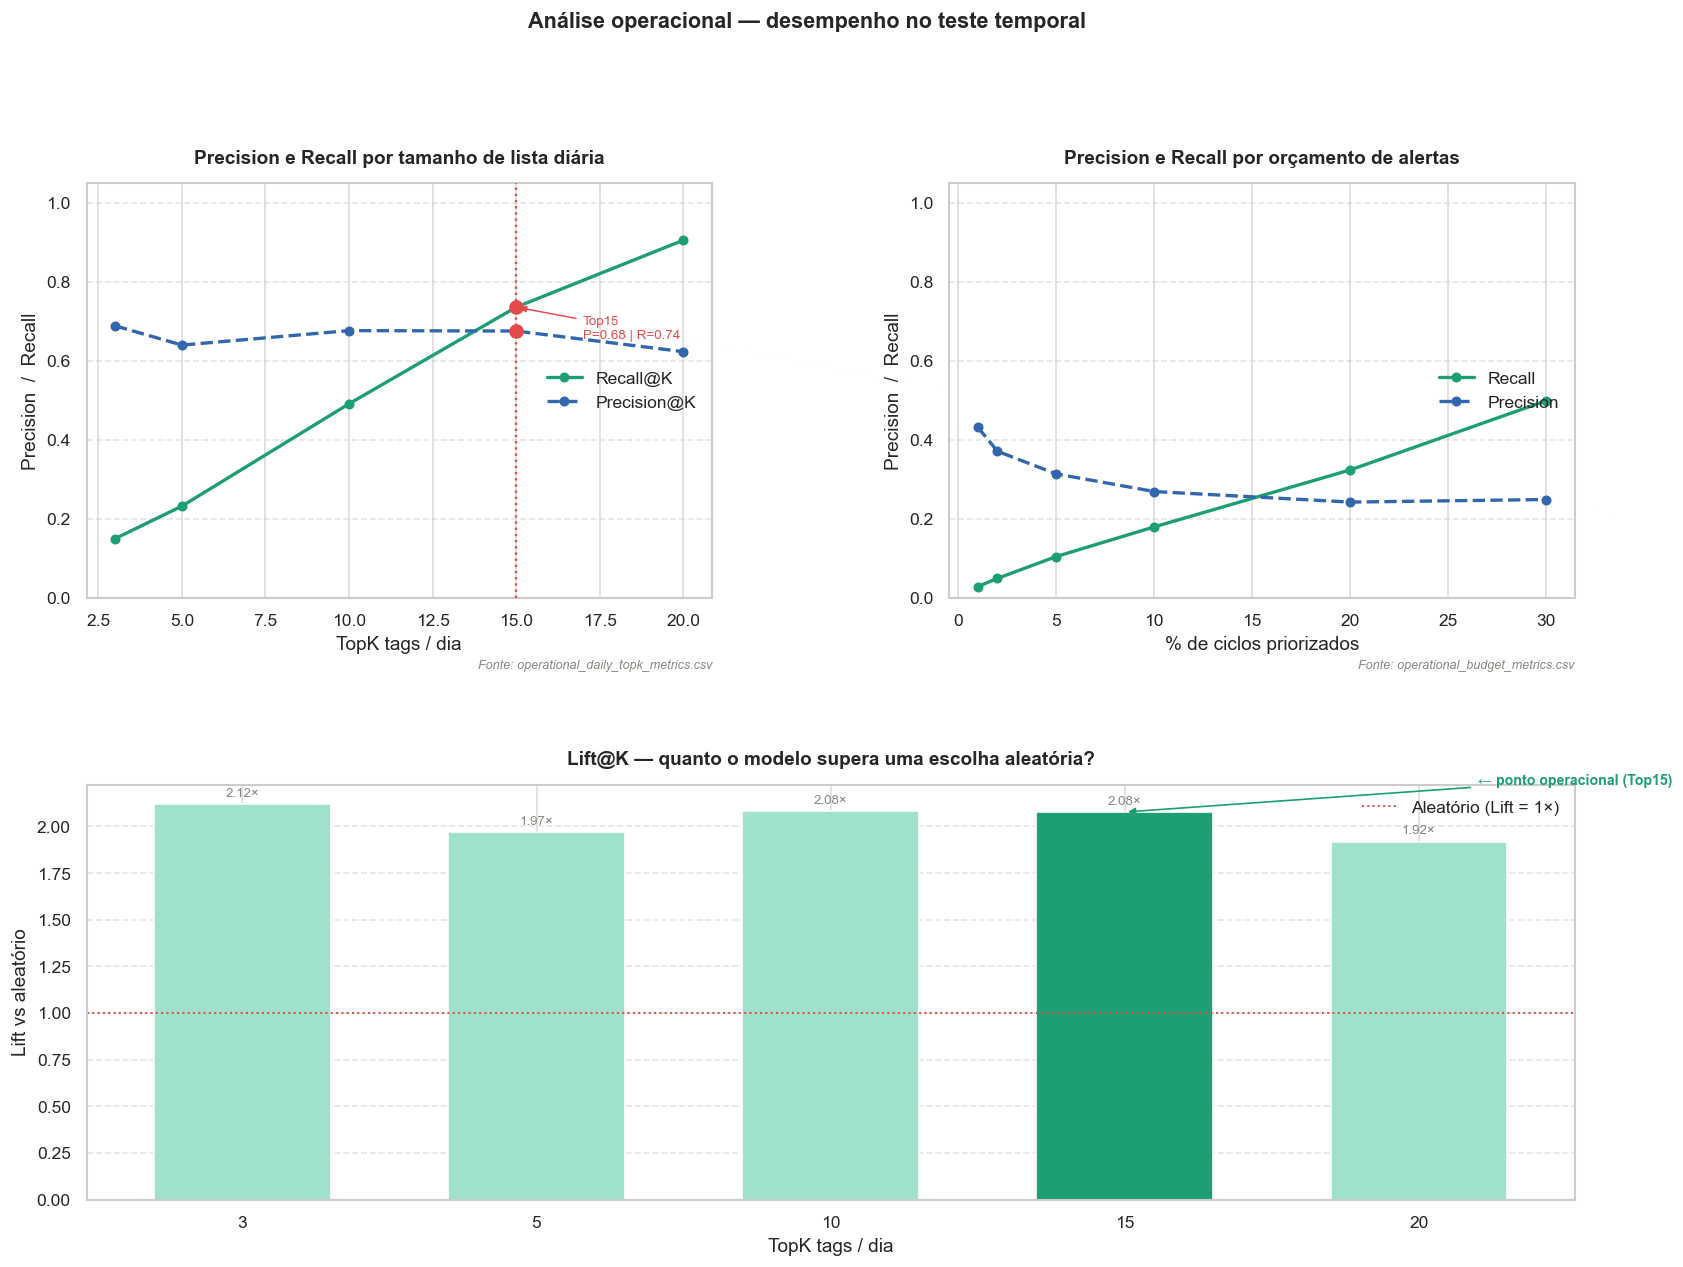

Lista diária,Dias avaliados,Equipamentos/dia,Positivos capturados,Precision@15,Recall@15,Lift@15
Top15 Tag-dia,30,15,304 de 413,0.6756,0.7361,2.0774×


TopK,Alertas/dia,Precision,Recall,Lift,Capturados,Total positivos
3,3.0,0.6889,0.1501,2.1184×,62,413
5,5.0,0.6400,0.2324,1.9680×,96,413
10,10.0,0.6767,0.4915,2.0808×,203,413
15,15.0,0.6756,0.7361,2.0774×,304,413
20,20.0,0.6233,0.9056,1.9168×,374,413


> **Insight operacional:** no teste temporal, Top15 captura `304` de `413` Tag-dias positivos, com Precision@15 `0.676` e Lift `2.08×` sobre escolha aleatória.

In [19]:
LINE_KW = dict(linewidth=2, marker="o", markersize=5)
LIFT_KW = dict(linewidth=1.5, marker="s", markersize=4, linestyle="--", color=PALETTE["amber"])

# ── Dados ──────────────────────────────────────────────────────────────
topk = oper_topk_df.query("split == 'test'").sort_values("top_k_tags_per_day").copy()
budget = oper_budget_df.query("split == 'test'").sort_values("budget_pct").copy()

# ── Cards executivos ───────────────────────────────────────────────────
print(
    f"\n{'─'*52}\n"
    f"  RESULTADO OPERACIONAL — TESTE TEMPORAL\n"
    f"{'─'*52}\n"
    f"  Precision@15 : {topk15['precision_at_k']:.3f}\n"
    f"  Recall@15    : {topk15['recall_at_k']:.3f}\n"
    f"  Lift@15      : {topk15['lift_vs_random']:.2f}×  vs aleatório\n"
    f"  Capturados   : {fmt_int(topk15['positives_captured'])} "
    f"de {fmt_int(topk15['total_positives'])} positivos\n"
    f"{'─'*52}\n"
)

# ── Layout: 3 painéis ──────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.38)

ax_topk = fig.add_subplot(gs[0, 0])  # Curva TopK  — Precision/Recall
ax_bgt = fig.add_subplot(gs[0, 1])  # Curva Budget — Precision/Recall
ax_lift = fig.add_subplot(gs[1, :])  # Lift@K em barras (painel largo)

# ── Painel 1 — Curva TopK: Precision & Recall ─────────────────────────
ax_topk.plot(
    topk["top_k_tags_per_day"],
    topk["recall_at_k"],
    **LINE_KW,
    color=PALETTE["teal"],
    label="Recall@K",
)
ax_topk.plot(
    topk["top_k_tags_per_day"],
    topk["precision_at_k"],
    **LINE_KW,
    color=PALETTE["blue"],
    linestyle="--",
    label="Precision@K",
)

ax_topk.axvline(15, color=PALETTE["red"], linestyle=":", linewidth=1.4, zorder=3)
ax_topk.scatter(
    [15, 15],
    [topk15["precision_at_k"], topk15["recall_at_k"]],
    color=PALETTE["red"],
    zorder=5,
    s=60,
)
ax_topk.annotate(
    f"Top15\nP={topk15['precision_at_k']:.2f} | R={topk15['recall_at_k']:.2f}",
    xy=(15, topk15["recall_at_k"]),
    xytext=(17, topk15["recall_at_k"] - 0.08),
    fontsize=8,
    color=PALETTE["red"],
    arrowprops=dict(arrowstyle="-|>", color=PALETTE["red"], lw=0.9),
)
ax_topk.set_title("Precision e Recall por tamanho de lista diária")
ax_topk.set_xlabel("TopK tags / dia")
ax_topk.set_ylabel("Precision  /  Recall")
ax_topk.set_ylim(0, 1.05)
ax_topk.yaxis.grid(True, linestyle="--", alpha=0.5)
ax_topk.set_axisbelow(True)
ax_topk.legend(loc="center right")
ax_topk.annotate(
    "Fonte: operational_daily_topk_metrics.csv",
    xy=(1, -0.17),
    xycoords="axes fraction",
    ha="right",
    fontsize=7.5,
    color=PALETTE["gray"],
    style="italic",
)

# ── Painel 2 — Curva Budget: Precision & Recall ───────────────────────
ax_bgt.plot(
    budget["budget_pct"] * 100,
    budget["recall_at_budget"],
    **LINE_KW,
    color=PALETTE["teal"],
    label="Recall",
)
ax_bgt.plot(
    budget["budget_pct"] * 100,
    budget["precision_at_budget"],
    **LINE_KW,
    color=PALETTE["blue"],
    linestyle="--",
    label="Precision",
)
ax_bgt.set_title("Precision e Recall por orçamento de alertas")
ax_bgt.set_xlabel("% de ciclos priorizados")
ax_bgt.set_ylabel("Precision  /  Recall")
ax_bgt.set_ylim(0, 1.05)
ax_bgt.yaxis.grid(True, linestyle="--", alpha=0.5)
ax_bgt.set_axisbelow(True)
ax_bgt.legend(loc="center right")
ax_bgt.annotate(
    "Fonte: operational_budget_metrics.csv",
    xy=(1, -0.17),
    xycoords="axes fraction",
    ha="right",
    fontsize=7.5,
    color=PALETTE["gray"],
    style="italic",
)

# ── Painel 3 — Lift@K em barras (fácil de ler para stakeholders) ──────
bar_colors = [
    PALETTE["teal"] if k == 15 else PALETTE["teal_light"] for k in topk["top_k_tags_per_day"]
]
bars = ax_lift.bar(
    topk["top_k_tags_per_day"].astype(str),
    topk["lift_vs_random"],
    color=bar_colors,
    width=0.6,
    zorder=2,
)
ax_lift.bar_label(bars, fmt="%.2f×", fontsize=8, padding=3, color=PALETTE["gray"])
ax_lift.axhline(
    1.0, color=PALETTE["red"], linestyle=":", linewidth=1.2, label="Aleatório (Lift = 1×)"
)

# Destaque Top15
idx15 = topk["top_k_tags_per_day"].tolist().index(15)
ax_lift.annotate(
    "← ponto operacional (Top15)",
    xy=(idx15, topk.iloc[idx15]["lift_vs_random"]),
    xytext=(idx15 + 1.2, topk.iloc[idx15]["lift_vs_random"] + 0.15),
    fontsize=8.5,
    fontweight="semibold",
    color=PALETTE["teal"],
    arrowprops=dict(arrowstyle="-|>", color=PALETTE["teal"], lw=1),
)
ax_lift.set_title("Lift@K — quanto o modelo supera uma escolha aleatória?")
ax_lift.set_xlabel("TopK tags / dia")
ax_lift.set_ylabel("Lift vs aleatório")
ax_lift.yaxis.grid(True, linestyle="--", alpha=0.5)
ax_lift.set_axisbelow(True)
ax_lift.legend(loc="upper right")

plt.suptitle(
    "Análise operacional — desempenho no teste temporal", fontsize=13, fontweight="semibold", y=1.01
)
plt.tight_layout()
plt.show()

# ── Tabela executiva resumida ──────────────────────────────────────────
executive_topk = pd.DataFrame(
    [
        {
            "Lista diária": "Top15 Tag-dia",
            "Dias avaliados": int(topk15["days"]),
            "Equipamentos/dia": int(topk15["alerts_per_day"]),
            "Positivos capturados": (
                f"{fmt_int(topk15['positives_captured'])} "
                f"de {fmt_int(topk15['total_positives'])}"
            ),
            "Precision@15": topk15["precision_at_k"],
            "Recall@15": topk15["recall_at_k"],
            "Lift@15": topk15["lift_vs_random"],
        }
    ]
)


display(
    executive_topk.style.hide(axis="index")
    .format({"Precision@15": "{:.4f}", "Recall@15": "{:.4f}", "Lift@15": "{:.4f}×"})
    .set_caption("Resultado operacional no teste temporal")
    .set_table_styles(table_style("teal"))
)

# ── Curva completa TopK ────────────────────────────────────────────────
topk_table = topk[
    [
        "top_k_tags_per_day",
        "alerts_per_day",
        "precision_at_k",
        "recall_at_k",
        "lift_vs_random",
        "positives_captured",
        "total_positives",
    ]
].copy()

display(
    topk_table.rename(
        columns={
            "top_k_tags_per_day": "TopK",
            "alerts_per_day": "Alertas/dia",
            "precision_at_k": "Precision",
            "recall_at_k": "Recall",
            "lift_vs_random": "Lift",
            "positives_captured": "Capturados",
            "total_positives": "Total positivos",
        }
    )
    .style.hide(axis="index")
    .format({"Alertas/dia": "{:.1f}", "Precision": "{:.4f}", "Recall": "{:.4f}", "Lift": "{:.4f}×"})
    .set_caption("Curva operacional TopK")
    .set_table_styles(table_style("teal"))
)

display(
    Markdown(
        f"> **Insight operacional:** no teste temporal, Top15 captura "
        f"`{topk15['positives_captured']:.0f}` de `{topk15['total_positives']:.0f}` "
        f"Tag-dias positivos, com Precision@15 `{topk15['precision_at_k']:.3f}` e "
        f"Lift `{topk15['lift_vs_random']:.2f}×` sobre escolha aleatória."
    )
)

### 9.1 Segmentos e Riscos Operacionais

O desempenho global precisa ser auditado por recortes operacionais. Segmentos inconclusivos por baixa prevalência não significam reprovação automática; eles indicam necessidade de monitoramento e coleta dedicada.


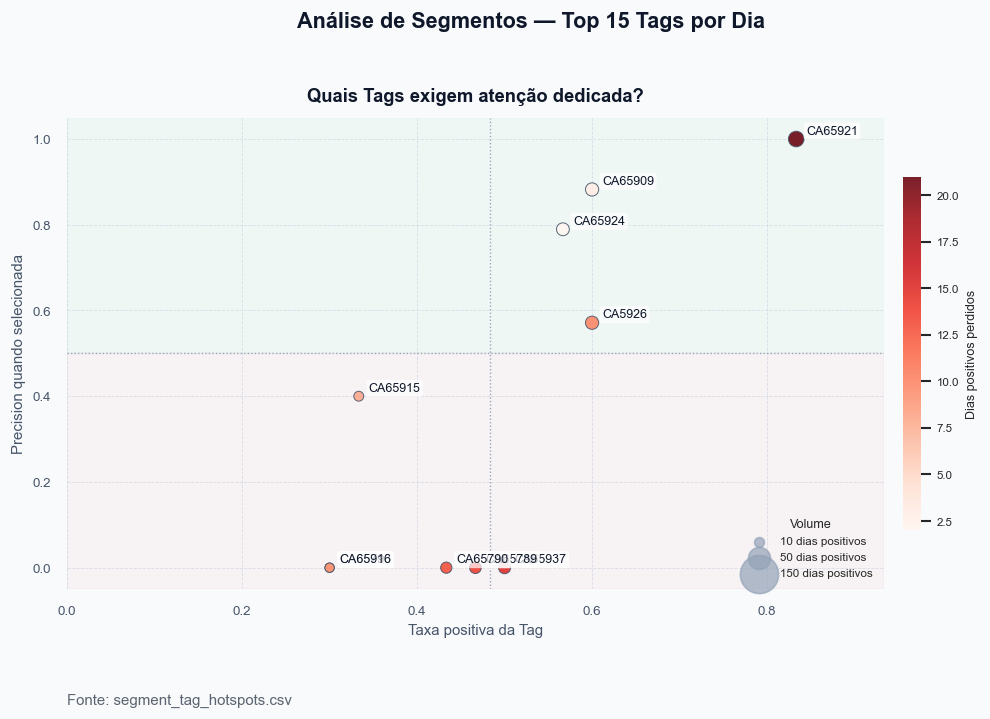

**Insight operacional:** a governança deve operar o piloto com trilha segmentada: usar o score global, monitorar frotas/tipos/Tags e tratar baixa prevalência como incerteza estatística.

In [20]:
# ── Dados ────────────────────────────────────────────────────────────────────
seg_top15 = segment_topk_df.query("top_k_tags_per_day == 15").copy()
seg_top15["segment_label"] = (
    seg_top15["segment_col"].astype(str) + ": " + seg_top15["segment_value"].astype(str)
)

hotspots = segment_hotspots_df.sort_values(
    ["missed_positive_days", "positive_days"], ascending=False
).head(10)

# ── Layout: figura única com scatter ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("#f8fafc")
ax.set_facecolor("#f8fafc")

# ══════════════════════════════════════════════════════════════════════════════
# PAINEL — Scatter hotspots
# ══════════════════════════════════════════════════════════════════════════════
ax.axhspan(-0.05, 0.5, alpha=0.04, color="#ef4444", zorder=0)
ax.axhspan(0.5, 1.05, alpha=0.04, color="#22c55e", zorder=0)
ax.axvline(
    hotspots["tag_positive_rate"].median(), color="#94a3b8", linewidth=0.8, linestyle=":", zorder=1
)
ax.axhline(0.5, color="#94a3b8", linewidth=0.8, linestyle=":", zorder=1)

sc = ax.scatter(
    hotspots["tag_positive_rate"],
    hotspots["selected_precision"],
    s=hotspots["positive_days"] * 3.5,
    c=hotspots["missed_positive_days"],
    cmap="Reds",
    edgecolors="#475569",
    linewidths=0.6,
    alpha=0.88,
    zorder=3,
)

cbar = fig.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label("Dias positivos perdidos", fontsize=7.5)
cbar.ax.tick_params(labelsize=7)
cbar.outline.set_visible(False)

for _, row in hotspots.iterrows():
    ax.annotate(
        row["Tag"],
        xy=(row["tag_positive_rate"], row["selected_precision"]),
        xytext=(6, 3),
        textcoords="offset points",
        fontsize=7.5,
        color="#0f172a",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
    )

ax.set_title(
    "Quais Tags exigem atenção dedicada?", fontsize=11, fontweight="bold", color="#0f172a", pad=10
)
ax.set_xlabel("Taxa positiva da Tag", fontsize=9, color="#475569")
ax.set_ylabel("Precision quando selecionada", fontsize=9, color="#475569")
ax.set_xlim(0, min(1.05, max(0.2, hotspots["tag_positive_rate"].max() + 0.1)))
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis="both", labelsize=8, colors="#475569")
ax.set_axisbelow(True)
ax.xaxis.grid(True, color="#cbd5e1", linewidth=0.5, linestyle="--")
ax.yaxis.grid(True, color="#cbd5e1", linewidth=0.5, linestyle="--")
for spine in ax.spines.values():
    spine.set_visible(False)

for days in [10, 50, 150]:
    ax.scatter([], [], s=days * 3.5, c="#94a3b8", alpha=0.7, label=f"{days} dias positivos")
ax.legend(title="Volume", fontsize=7, title_fontsize=7.5, frameon=False, loc="lower right")

add_source_note(ax, "Fonte: segment_tag_hotspots.csv")

plt.suptitle(
    "Análise de Segmentos — Top 15 Tags por Dia",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    y=1.02,
)

plt.tight_layout()
plt.savefig("/tmp/_seg_plot.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


display(
    Markdown(
        "**Insight operacional:** a governança deve operar o piloto com trilha segmentada: "
        "usar o score global, monitorar frotas/tipos/Tags e tratar baixa prevalência "
        "como incerteza estatística."
    )
)

## 10. Decisão Executiva e Próximos Passos

O projeto está metodologicamente apto para **piloto operacional assistido**, com acompanhamento humano e monitoramento contínuo. O artefato promovido é `models/model_selected.joblib`.


In [21]:
targets = pd.DataFrame(
    [
        {
            "Métrica": "Precision@Top15",
            "Resultado": topk15["precision_at_k"],
            "Meta": 0.65,
            "Status": "Aprovado" if topk15["precision_at_k"] >= 0.65 else "Atenção",
        },
        {
            "Métrica": "Recall@Top15",
            "Resultado": topk15["recall_at_k"],
            "Meta": 0.70,
            "Status": "Aprovado" if topk15["recall_at_k"] >= 0.70 else "Atenção",
        },
        {
            "Métrica": "Lift@Top15",
            "Resultado": topk15["lift_vs_random"],
            "Meta": 2.00,
            "Status": "Aprovado" if topk15["lift_vs_random"] >= 2.00 else "Atenção",
        },
    ]
)

display(
    targets.style.hide(axis="index")
    .format({"Resultado": "{:.4f}", "Meta": "{:.2f}"})
    .set_caption("Metas operacionais no teste temporal")
)

recommendations = pd.DataFrame(
    [
        {
            "Frente": "Piloto assistido",
            "Ação": "Rodar Top15 Tag-dia com validação da manutenção por 30 dias",
        },
        {
            "Frente": "Monitoramento",
            "Ação": "Acompanhar Precision@15, Recall@15, Lift@15 e volume de falsos alertas",
        },
        {
            "Frente": "Estabilidade",
            "Ação": "Executar `make gate-stability` a cada nova janela relevante",
        },
        {
            "Frente": "Segmentos",
            "Ação": "Criar trilha dedicada para Tags/frotas frágeis ou inconclusivas",
        },
        {
            "Frente": "Retreino",
            "Ação": (
                "Acionar revisão se Recall@15 cair abaixo do limite "
                "definido na política de promoção"
            ),
        },
    ]
)

display(
    recommendations.style.hide(axis="index").set_caption("Plano executivo de adoção controlada")
)

final_msg = (
    f"**Conclusão:** `{model_name}` atende às metas atuais no teste temporal: "
    f"Precision@15 `{topk15['precision_at_k']:.3f}`, "
    f"Recall@15 `{topk15['recall_at_k']:.3f}` e "
    f"Lift@15 `{topk15['lift_vs_random']:.2f}x`. "
    "O uso recomendado é piloto assistido, mantendo decisão humana, "
    "monitoramento de drift e análise segmentada."
)
display(Markdown(final_msg))

Métrica,Resultado,Meta,Status
Precision@Top15,0.6756,0.65,Aprovado
Recall@Top15,0.7361,0.70,Aprovado
Lift@Top15,2.0774,2.00,Aprovado


Frente,Ação
Piloto assistido,Rodar Top15 Tag-dia com validação da manutenção por 30 dias
Monitoramento,"Acompanhar Precision@15, Recall@15, Lift@15 e volume de falsos alertas"
Estabilidade,Executar `make gate-stability` a cada nova janela relevante
Segmentos,Criar trilha dedicada para Tags/frotas frágeis ou inconclusivas
Retreino,Acionar revisão se Recall@15 cair abaixo do limite definido na política de promoção


**Conclusão:** `lightgbm_optuna` atende às metas atuais no teste temporal: Precision@15 `0.676`, Recall@15 `0.736` e Lift@15 `2.08x`. O uso recomendado é piloto assistido, mantendo decisão humana, monitoramento de drift e análise segmentada.

### 10.1 Comparação com Baseline, Limitações e Trabalhos Futuros

Esta seção fecha explicitamente os itens finais do estudo guiado: comparação com baseline, tradução para impacto de negócio, resposta objetiva à pergunta analítica, limitações e extensões futuras.


In [22]:
baseline_report = read_json(REPORTS_BASELINE / "baseline_report.json")
baseline_test = baseline_report["metrics"]["test"]

# Usa o ID oficial do artefato operacional; evita depender de textos de apresentação.
selected_model_name = oper_json.get("model_name", selected_model.get("model_name", model_name))
selected_rows = selection_df.loc[selection_df["model_name"].eq(selected_model_name)]
if selected_rows.empty:
    available_models = ", ".join(selection_df["model_name"].astype(str).tolist())
    raise ValueError(
        f"Modelo selecionado '{selected_model_name}' não encontrado em selection_df. "
        f"Modelos disponíveis: {available_models}"
    )
selected_row = selected_rows.iloc[0]

baseline_comparison = pd.DataFrame(
    [
        {
            "Metrica": "AUC-PR ciclo-a-ciclo",
            "Baseline": baseline_test["auc_pr"],
            "Modelo selecionado": selected_row["test_auc_pr"],
            "Melhoria absoluta": selected_row["test_auc_pr"] - baseline_test["auc_pr"],
        },
        {
            "Metrica": "AUC-ROC ciclo-a-ciclo",
            "Baseline": baseline_test["auc_roc"],
            "Modelo selecionado": selected_row["test_auc_roc"],
            "Melhoria absoluta": selected_row["test_auc_roc"] - baseline_test["auc_roc"],
        },
        {
            "Metrica": "Recall ciclo-a-ciclo",
            "Baseline": baseline_test["recall"],
            "Modelo selecionado": selected_row["test_recall"],
            "Melhoria absoluta": selected_row["test_recall"] - baseline_test["recall"],
        },
        {
            "Metrica": "Precision ciclo-a-ciclo",
            "Baseline": baseline_test["precision"],
            "Modelo selecionado": selected_row["test_precision"],
            "Melhoria absoluta": selected_row["test_precision"] - baseline_test["precision"],
        },
        {
            "Metrica": "Recall@Top15 operacional",
            "Baseline": np.nan,
            "Modelo selecionado": topk15["recall_at_k"],
            "Melhoria absoluta": np.nan,
        },
        {
            "Metrica": "Precision@Top15 operacional",
            "Baseline": np.nan,
            "Modelo selecionado": topk15["precision_at_k"],
            "Melhoria absoluta": np.nan,
        },
        {
            "Metrica": "Lift@Top15 vs aleatorio",
            "Baseline": 1.0,
            "Modelo selecionado": topk15["lift_vs_random"],
            "Melhoria absoluta": topk15["lift_vs_random"] - 1.0,
        },
    ]
)
display(
    baseline_comparison.style.hide(axis="index")
    .format({"Baseline": "{:.4f}", "Modelo selecionado": "{:.4f}", "Melhoria absoluta": "{:.4f}"})
    .set_caption("Melhoria quantificada contra baseline")
)

impact_table = pd.DataFrame(
    [
        {"Indicador": "Alertas positivos no teste", "Valor": fmt_int(topk15["total_positives"])},
        {
            "Indicador": "Alertas capturados no Top15",
            "Valor": fmt_int(topk15["positives_captured"]),
        },
        {"Indicador": "% antecipado pelo Top15", "Valor": f"{topk15['recall_at_k']:.1%}"},
        {
            "Indicador": "Inspecoes recomendadas",
            "Valor": (
                f"{fmt_int(topk15['selected_alerts'])} "
                f"em {fmt_int(topk15['days'])} dias "
                f"({topk15['alerts_per_day']:.1f}/dia)"
            ),
        },
        {"Indicador": "Ganho sobre aleatorio", "Valor": f"{topk15['lift_vs_random']:.2f}x"},
    ]
)
display(
    impact_table.style.hide(axis="index").set_caption(
        "Traducao das metricas para impacto operacional"
    )
)

limitations = pd.DataFrame(
    [
        {
            "Limitacao": "Janela historica limitada",
            "Risco": "generalizacao pode mudar em outras regioes, meses ou sazonalidades",
            "Mitigacao": "backtesting continuo e retreino por janela movel",
        },
        {
            "Limitacao": "Dados de manutencao preventiva ausentes",
            "Risco": "modelo nao sabe se uma intervencao recente reduziu risco",
            "Mitigacao": "integrar ordens de servico e historico de manutencao",
        },
        {
            "Limitacao": "Custo real de parada nao esta no dataset",
            "Risco": "impacto financeiro e priorizacao economica ficam aproximados",
            "Mitigacao": "adicionar custo/hora por frota e severidade operacional",
        },
        {
            "Limitacao": "SHAP explica associacao, nao causalidade",
            "Risco": "interpretar sinal correlacional como causa de falha",
            "Mitigacao": "validacao com especialistas e experimentos controlados no piloto",
        },
    ]
)
display(limitations.style.hide(axis="index").set_caption("Limitacoes honestas da abordagem"))

future_work = pd.DataFrame(
    [
        {
            "Extensao": "Novos dados",
            "Proposta": (
                "integrar manutencao preventiva, falhas mecanicas, " "clima e contexto de mina"
            ),
            "Justificativa": "aumenta explicacao causal e reduz falsos positivos",
        },
        {
            "Extensao": "Novas features",
            "Proposta": (
                "features em tempo real de sensores e comportamento " "anonimizado do operador"
            ),
            "Justificativa": "captura degradacao mais proxima do evento",
        },
        {
            "Extensao": "Modelos online",
            "Proposta": "aprendizado incremental/monitoramento de drift com gatilho de retreino",
            "Justificativa": "mantem performance quando operacao muda",
        },
        {
            "Extensao": "Integracao operacional",
            "Proposta": "API ou job diario para publicar Top15 no sistema do dispatcher",
            "Justificativa": "fecha ciclo entre score, inspecao, feedback e governanca",
        },
    ]
)
display(future_work.style.hide(axis="index").set_caption("Trabalhos futuros concretos"))

answer = (
    "**Resposta a pergunta analitica:** sim, e possivel priorizar equipamentos "
    "com maior risco de alerta critico nas proximas 4 horas. "
    f"No teste temporal, o Top15 Tag-dia capturou `{topk15['positives_captured']:.0f}` "
    f"de `{topk15['total_positives']:.0f}` positivos (`{topk15['recall_at_k']:.1%}`), "
    f"com Precision@15 `{topk15['precision_at_k']:.1%}` e "
    f"lift `{topk15['lift_vs_random']:.2f}x` contra selecao aleatoria. "
    "A recomendacao e piloto assistido, nao automacao cega."
)
display(Markdown(answer))

Metrica,Baseline,Modelo selecionado,Melhoria absoluta
AUC-PR ciclo-a-ciclo,0.1498,0.2737,0.1239
AUC-ROC ciclo-a-ciclo,0.5000,0.7428,0.2428
Recall ciclo-a-ciclo,1.0000,0.8163,-0.1837
Precision ciclo-a-ciclo,0.1498,0.2706,0.1208
Recall@Top15 operacional,nan,0.7361,nan
Precision@Top15 operacional,nan,0.6756,nan
Lift@Top15 vs aleatorio,1.0000,2.0774,1.0774


Indicador,Valor
Alertas positivos no teste,413
Alertas capturados no Top15,304
% antecipado pelo Top15,73.6%
Inspecoes recomendadas,450 em 30 dias (15.0/dia)
Ganho sobre aleatorio,2.08x


Limitacao,Risco,Mitigacao
Janela historica limitada,"generalizacao pode mudar em outras regioes, meses ou sazonalidades",backtesting continuo e retreino por janela movel
Dados de manutencao preventiva ausentes,modelo nao sabe se uma intervencao recente reduziu risco,integrar ordens de servico e historico de manutencao
Custo real de parada nao esta no dataset,impacto financeiro e priorizacao economica ficam aproximados,adicionar custo/hora por frota e severidade operacional
"SHAP explica associacao, nao causalidade",interpretar sinal correlacional como causa de falha,validacao com especialistas e experimentos controlados no piloto


Extensao,Proposta,Justificativa
Novos dados,"integrar manutencao preventiva, falhas mecanicas, clima e contexto de mina",aumenta explicacao causal e reduz falsos positivos
Novas features,features em tempo real de sensores e comportamento anonimizado do operador,captura degradacao mais proxima do evento
Modelos online,aprendizado incremental/monitoramento de drift com gatilho de retreino,mantem performance quando operacao muda
Integracao operacional,API ou job diario para publicar Top15 no sistema do dispatcher,"fecha ciclo entre score, inspecao, feedback e governanca"


**Resposta a pergunta analitica:** sim, e possivel priorizar equipamentos com maior risco de alerta critico nas proximas 4 horas. No teste temporal, o Top15 Tag-dia capturou `304` de `413` positivos (`73.6%`), com Precision@15 `67.6%` e lift `2.08x` contra selecao aleatoria. A recomendacao e piloto assistido, nao automacao cega.

### 10.2 Checklist de Cobertura dos Conteúdos Mínimos

A tabela final mapeia as seções do notebook aos conteúdos mínimos do estudo guiado. Ela funciona como guia de leitura para avaliação.


In [23]:
coverage = pd.DataFrame(
    [
        {
            "CM": "1.1",
            "Conteúdo": "Contexto da operação e regras Don't Go",
            "Onde está": "1. Contexto de Negócio",
            "Status": "coberto",
        },
        {
            "CM": "1.2",
            "Conteúdo": "Problema analítico, métrica e uso",
            "Onde está": "1. Contexto + 10. Decisão Executiva",
            "Status": "coberto",
        },
        {
            "CM": "2.1",
            "Conteúdo": "Carga, shape, dtypes, nulos, duplicatas, estatísticas",
            "Onde está": "3.1 Inspeção Inicial",
            "Status": "coberto",
        },
        {
            "CM": "2.2",
            "Conteúdo": "Alvo, alertas por tipo/nível/tag e série temporal",
            "Onde está": "4. Rotulação + 5. EDA",
            "Status": "coberto",
        },
        {
            "CM": "2.3",
            "Conteúdo": "Correlações, categorias e padrões temporais",
            "Onde está": "5.3 Risco por Categorias + 6.3 Features e Alvo",
            "Status": "coberto",
        },
        {
            "CM": "3.1",
            "Conteúdo": "Limpeza, missing, inconsistências, outliers, antes/depois",
            "Onde está": "3.2 Limpeza e Tratamentos",
            "Status": "coberto",
        },
        {
            "CM": "3.2",
            "Conteúdo": "Feature engineering documentada",
            "Onde está": "6.1 Famílias + 6.2 Catálogo",
            "Status": "coberto",
        },
        {
            "CM": "3.3",
            "Conteúdo": "Definição do target e janela",
            "Onde está": "4. Rotulação e Variável Alvo",
            "Status": "coberto",
        },
        {
            "CM": "4.1",
            "Conteúdo": "Validação temporal e anti-leakage",
            "Onde está": "6. Feature Engineering + 7.2 Validação Temporal",
            "Status": "coberto",
        },
        {
            "CM": "4.2",
            "Conteúdo": "Baseline",
            "Onde está": "7. Treinamento + 10.1 Comparação com Baseline",
            "Status": "coberto",
        },
        {
            "CM": "4.3",
            "Conteúdo": "Duas abordagens/modelagem/tuning",
            "Onde está": "7.1 Comparação de Candidatos",
            "Status": "coberto",
        },
        {
            "CM": "5.1",
            "Conteúdo": "Métricas, custos e curvas ROC/PR",
            "Onde está": "7.2 Métricas Técnicas + 8. Diagnóstico",
            "Status": "coberto",
        },
        {
            "CM": "5.2",
            "Conteúdo": "Matriz de confusão, erros e drift",
            "Onde está": "8.1 Análise de Erros",
            "Status": "coberto",
        },
        {
            "CM": "5.3",
            "Conteúdo": "Interpretabilidade/SHAP",
            "Onde está": "8.2 Interpretabilidade",
            "Status": "coberto",
        },
        {
            "CM": "6.1",
            "Conteúdo": "Resultados e impacto",
            "Onde está": "9. Resultado Operacional + 10. Decisão",
            "Status": "coberto",
        },
        {
            "CM": "6.2",
            "Conteúdo": "Conclusão e limitações",
            "Onde está": "10.1 Limitações",
            "Status": "coberto",
        },
        {
            "CM": "6.3",
            "Conteúdo": "Trabalhos futuros",
            "Onde está": "10.1 Trabalhos Futuros",
            "Status": "coberto",
        },
    ]
)
display(
    coverage.style.hide(axis="index")
    .set_caption("Matriz de cobertura dos conteúdos mínimos")
    .set_table_styles(table_style("teal"))
)

CM,Conteúdo,Onde está,Status
1.1,Contexto da operação e regras Don't Go,1. Contexto de Negócio,coberto
1.2,"Problema analítico, métrica e uso",1. Contexto + 10. Decisão Executiva,coberto
2.1,"Carga, shape, dtypes, nulos, duplicatas, estatísticas",3.1 Inspeção Inicial,coberto
2.2,"Alvo, alertas por tipo/nível/tag e série temporal",4. Rotulação + 5. EDA,coberto
2.3,"Correlações, categorias e padrões temporais",5.3 Risco por Categorias + 6.3 Features e Alvo,coberto
3.1,"Limpeza, missing, inconsistências, outliers, antes/depois",3.2 Limpeza e Tratamentos,coberto
3.2,Feature engineering documentada,6.1 Famílias + 6.2 Catálogo,coberto
3.3,Definição do target e janela,4. Rotulação e Variável Alvo,coberto
4.1,Validação temporal e anti-leakage,6. Feature Engineering + 7.2 Validação Temporal,coberto
4.2,Baseline,7. Treinamento + 10.1 Comparação com Baseline,coberto
